# Anti-Money Laundering in Bitcoin Transactions

## Study objectives

This study uses the Elliptic Bitcoin transaction graph to:

1. Explore the temporal, class, and graph structure of the dataset.
2. Prepare transaction features and labels without introducing data leakage.
3. Build baseline models for distinguishing licit and illicit transactions.
4. Evaluate models with metrics appropriate for severe class imbalance.
5. Record assumptions, random seeds, dependency versions, and generated artifacts
   so the analysis can be reproduced.

## Dataset

The Elliptic dataset is downloaded separately and is not stored in this
repository. See `docs/dataset.md` for acquisition and placement instructions.

In [1]:
from pathlib import Path # library module for working with file system paths.
import os # library module for interacting with the operating system. 
import platform # library module for getting information about the operating system.
import random # library module for generating random numbers.

import numpy as np # library module for numerical computing with arrays and matrices.
import pandas as pd # library module for data manipulation and analysis.
import sklearn # library module for machine learning and data mining.

RANDOM_SEED = 42 # constant variable for setting the random seed for reproducibility.

os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED) # set the PYTHONHASHSEED environment variable to the random seed value.
random.seed(RANDOM_SEED) # set the random seed for the random module.
np.random.seed(RANDOM_SEED) # set the random seed for the numpy module.



In [2]:
# This function automatically locates your project's main folder so your code can safely load files using consistent relative paths, 
# regardless of where your Jupyter notebook was launched.
def find_project_root(start: Path | None = None) -> Path:
    """Find the project root regardless of where Jupyter was launched."""
    start = (start or Path.cwd()).resolve()

    for candidate in (start, *start.parents):
        if (candidate / "requirements.txt").is_file():
            return candidate

    raise FileNotFoundError(
        "Project root not found. Expected a parent directory containing "
        "'requirements.txt'. Start Jupyter inside this project."
    )

In [3]:
# This code block serves as an environment and dataset validation setup for your project pipeline.
# It ensures your workspace is properly configured and that all required data files exist before executing heavy computations.

# this line calls the find_project_root function to locate the project root 
# directory and assigns it to the PROJECT_ROOT variable.
PROJECT_ROOT = find_project_root() 
# this line constructs the path to the directory where the raw dataset 
# files are expected to be located, based on the project root.
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "elliptic_bitcoin_dataset" 
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"

REQUIRED_DATA_FILES = (
    "elliptic_txs_features.csv",
    "elliptic_txs_classes.csv",
    "elliptic_txs_edgelist.csv",
)

missing_files = [
    DATA_DIR / filename
    for filename in REQUIRED_DATA_FILES
    if not (DATA_DIR / filename).is_file()
]

print(f"Project root: {PROJECT_ROOT}")
print(f"Python:       {platform.python_version()}")
print(f"NumPy:        {np.__version__}")
print(f"pandas:       {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"Random seed:  {RANDOM_SEED}")

if missing_files:
    missing_list = "\n".join(f"  - {path}" for path in missing_files)
    raise FileNotFoundError(
        "Elliptic dataset is incomplete or has not been downloaded.\n"
        f"Expected directory: {DATA_DIR}\n"
        f"Missing files:\n{missing_list}\n"
        "Follow docs/dataset.md to obtain the dataset."
    )

print("Dataset check passed: all required files were found.")

Project root: E:\Machine Leraning\ML Project\AML Crypto Complience
Python:       3.13.5
NumPy:        2.5.2
pandas:       3.0.5
scikit-learn: 1.9.0
Random seed:  42
Dataset check passed: all required files were found.


## 2. Data loading and validation

Load the Elliptic transaction features, labels, and payment-flow edges.
Validate their schemas and relationships before performing analysis or modeling.

In [4]:
# foLLOWING ARE THE PATHS TO THE DATA FILES
FEATURES_PATH = DATA_DIR / "elliptic_txs_features.csv"
CLASSES_PATH = DATA_DIR / "elliptic_txs_classes.csv"
EDGES_PATH = DATA_DIR / "elliptic_txs_edgelist.csv"

# The 166 node features consist of:
# - time_step
# - 93 other local transaction features
# - 72 aggregated one-hop features
LOCAL_TRANSACTION_COLUMNS = [
    f"local_feature_{number:03d}"
    for number in range(1, 94)    
]

AGGREGATE_FEATURE_COLUMNS = [
    f"aggregate_feature_{number:03d}"
    for number in range(1,73)
]

NODE_FEATURE_COLUMNS = [
    "time_step",
    *LOCAL_TRANSACTION_COLUMNS,
    *AGGREGATE_FEATURE_COLUMNS,
]

FEATURE_COLUMNS = [
    "transaction_id",
    *NODE_FEATURE_COLUMNS,
]

print(f"Node features: {len(NODE_FEATURE_COLUMNS)}")
print(f"Raw feature columns including ID: {len(FEATURE_COLUMNS)}")

Node features: 166
Raw feature columns including ID: 167


In [5]:
# following dictionary defines the data types for specific features in the dataset.
feature_dtypes = {
    "transaction_id": "int64",
    "time_step": "int16",
}

# update the feature_dtypes dictionary to include all local transaction and aggregate feature columns with a data type of float32.
feature_dtypes.update({
    column: "float32"
    for column in LOCAL_TRANSACTION_COLUMNS + AGGREGATE_FEATURE_COLUMNS
})

features_df = pd.read_csv(
    FEATURES_PATH,
    header=None,
    names=FEATURE_COLUMNS,
    dtype=feature_dtypes,
)

classes_df = (
    pd.read_csv(
        CLASSES_PATH,
        dtype={
            "txId": "int64",
            "class": "string",
        },
    ).rename(columns={"txId": "transaction_id", "class": "raw_class"})
)

edges_df = (
    pd.read_csv(
        EDGES_PATH,
        dtype={
            "txId1": "int64",
            "txId2": "int64",
        },
    ).rename(columns={"txId1": "source_transaction_id", "txId2": "target_transaction_id"})
)

print(f"Features shape: {features_df.shape}")
print(f"Classes shape: {classes_df.shape}")
print(f"Edges shape: {edges_df.shape}")

Features shape: (203769, 167)
Classes shape: (203769, 2)
Edges shape: (234355, 2)


In [6]:
# This section is responsible for cleaning, validating, and standardizing the transaction labels
# before use them for your AML machine-learning model.

classes_df["raw_class"] = (classes_df["raw_class"].str.strip().str.lower())

LABEL_MAP = {
    "1": "illicit",
    "2": "licit",
    "unknown": "unknown"
}

# following line creates a sorted list of unique labels in the classes_df DataFrame 
# that are not present in the LABEL_MAP dictionary.
# (i.e., 1,2, and unknown are recognized labels, 3 or any other label would be unrecognized)
unrecognized_labels = sorted(
    set(classes_df["raw_class"].dropna()) - set(LABEL_MAP)
)
# print(f"Unrecognized labels: {unrecognized_labels}")

# Stop the program if an unexpected label exists
if unrecognized_labels:
    raise ValueError(
        f"Unrecognized labels found in classes_df: {unrecognized_labels}. "
        "Please update the LABEL_MAP dictionary to include these labels."
    )

# Convert raw labels into meaningful labels
classes_df["label"] = classes_df["raw_class"].map(LABEL_MAP)

# Convert label into a categorical variable
classes_df["label"] = pd.Categorical(
    classes_df["label"],
    categories=["licit", "illicit", "unknown"],
)

classes_df["label"].value_counts()

label
unknown    157205
licit       42019
illicit      4545
Name: count, dtype: int64

In [7]:
# explicit validation function
# This section is a data-validation gate.
# Its purpose is to make sure the three Elliptic dataset files you loaded earlier
#  are actually the expected/canonical dataset before you allow the ML pipeline to continue.

EXPECTED_TRANSACTION_COUNT = 203_769
EXPECTED_EDGE_COUNT = 234_355
EXPECTED_TIME_STEPS = set(range(1, 50))

EXPECTED_LABEL_COUNTS = {
    "licit": 42_019,
    "illicit": 4_545,
    "unknown": 157_205,
}


def require(condition: bool, message: str) -> None:
    """Raise an understandable error when a dataset condition is not met."""
    if not condition:
        raise ValueError(f"Elliptic dataset validation failed: {message}")


def validate_elliptic_data(
    features: pd.DataFrame,
    classes: pd.DataFrame,
    edges: pd.DataFrame,
) -> None:
    """Validate the canonical Elliptic transaction dataset."""

    require(
        features.shape == (EXPECTED_TRANSACTION_COUNT, 167),
        f"feature table has shape {features.shape}; "
        f"expected ({EXPECTED_TRANSACTION_COUNT}, 167)",
    )

    require(
        len(classes) == EXPECTED_TRANSACTION_COUNT,
        f"class table has {len(classes):,} rows; "
        f"expected {EXPECTED_TRANSACTION_COUNT:,}",
    )

    require(
        edges.shape == (EXPECTED_EDGE_COUNT, 2),
        f"edge table has shape {edges.shape}; "
        f"expected ({EXPECTED_EDGE_COUNT}, 2)",
    )

    require(
        list(features.columns) == FEATURE_COLUMNS,
        "feature columns do not match the expected schema",
    )

    require(
        list(edges.columns)
        == ["source_transaction_id", "target_transaction_id"],
        "edge columns do not match the expected schema",
    )

    feature_duplicates = int(
        features["transaction_id"].duplicated().sum()
    )
    class_duplicates = int(
        classes["transaction_id"].duplicated().sum()
    )
    edge_duplicates = int(edges.duplicated().sum())

    require(
        feature_duplicates == 0,
        f"found {feature_duplicates:,} duplicated feature transaction IDs",
    )
    require(
        class_duplicates == 0,
        f"found {class_duplicates:,} duplicated class transaction IDs",
    )
    require(
        edge_duplicates == 0,
        f"found {edge_duplicates:,} duplicated edges",
    )

    require(
        not features.isna().any().any(),
        "the feature table contains missing values",
    )
    require(
        not classes.isna().any().any(),
        "the class table contains missing values",
    )
    require(
        not edges.isna().any().any(),
        "the edge table contains missing values",
    )

    require(
        np.isfinite(
            features[NODE_FEATURE_COLUMNS].to_numpy(copy=False)
        ).all(),
        "the feature table contains infinite values",
    )

    observed_time_steps = set(
        features["time_step"].astype(int).unique()
    )
    require(
        observed_time_steps == EXPECTED_TIME_STEPS,
        f"time steps are {sorted(observed_time_steps)}; expected 1 through 49",
    )

    feature_ids = pd.Index(features["transaction_id"])
    class_ids = pd.Index(classes["transaction_id"])

    missing_class_ids = feature_ids.difference(class_ids)
    orphan_class_ids = class_ids.difference(feature_ids)

    require(
        missing_class_ids.empty,
        f"{len(missing_class_ids):,} transactions have no class record",
    )
    require(
        orphan_class_ids.empty,
        f"{len(orphan_class_ids):,} class records have no feature row",
    )

    valid_source = edges["source_transaction_id"].isin(feature_ids)
    valid_target = edges["target_transaction_id"].isin(feature_ids)

    require(
        valid_source.all(),
        f"{int((~valid_source).sum()):,} edges have an unknown source",
    )
    require(
        valid_target.all(),
        f"{int((~valid_target).sum()):,} edges have an unknown target",
    )

    observed_counts = {
        str(label): int(count)
        for label, count in classes["label"].value_counts().items()
    }

    require(
        observed_counts == EXPECTED_LABEL_COUNTS,
        f"label counts are {observed_counts}; "
        f"expected {EXPECTED_LABEL_COUNTS}",
    )

    print("Elliptic dataset validation passed.")

validate_elliptic_data(features_df, classes_df, edges_df)

Elliptic dataset validation passed.


In [8]:
# Create the clean transaction table

transaction_df = features_df.merge(
    classes_df[["transaction_id", "label"]],
    on="transaction_id",
    how="left",
    validate="one_to_one"
)

print(f"Transaction table shape: {transaction_df.shape}")
print(f"Edges: {edges_df.shape}")
print()
print(transaction_df['label'].value_counts())



# test the validation function with a modified classes_df to simulate a failure case
# try:
#     validate_elliptic_data(
#         features_df,
#         classes_df.iloc[:-1],
#         edges_df,
#     )
# except ValueError as error:
#     print(error)

Transaction table shape: (203769, 168)
Edges: (234355, 2)

label
unknown    157205
licit       42019
illicit      4545
Name: count, dtype: int64


## 3. Exploratory data analysis

This section examines label coverage, temporal behavior, anonymized feature
distributions, and the transaction graph. All analyses are descriptive.

Unknown labels are not assumed to be licit. Any future feature selection must
be performed using training data only.

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")


LABEL_COLORS = {
    "licit": "#2E8B57",  # SeaGreen
    "illicit": "#C0392B", # Red
    "unknown": "#7F8C8D"  # Dark Gray
}

# 
LABEL_ORDER = ["licit", "illicit", "unknown"]

In [10]:
# Count each label (i.e. Illecit, licit, unknown)
label_counts = (
    transaction_df["label"]
    .value_counts()
    .reindex(LABEL_ORDER)
    .astype(int)
    )

# label_summary -- table with two columns (i.e. count, percentage_of_all_labels)
label_summary = pd.DataFrame({
    "count": label_counts,
    "percentage_of_all_labels": (
        label_counts / len(transaction_df) * 100
    ).round(3),
})

# print(f"Label Summary: {label_summary}")

# isin() indicate boolean value (licit, illicite = TRUE, unknown = FALSE)
labeled_mask = transaction_df["label"].isin(["licit", "illicit"])
# print(labeled_mask.value_counts())

# Create a subset of the transaction_df DataFrame that only includes rows where the label is either "licit" or "illicit".
labeled_df = transaction_df.loc[labeled_mask].copy()

# Calculate the percentage of illicit transactions among the labeled transactions
illicit_rate_labeled = (labeled_df.eq("illicit").mean() * 100).round(3)

display(label_summary)
print("---------------------------------")
print(f"Total transactions:   {len(transaction_df):,}")
print(f"Labeled transactions: {len(labeled_df):,}")
print(f"Label coverage:        {labeled_mask.mean() * 100:.3f}%")
print(f"Unknown coverage:      {(~labeled_mask).mean() * 100:.3f}%")
# print(
#     "Illicit share among labeled transactions: "
#     f"{illicit_rate_labeled:.3f}%"
# )

,count,percentage_of_all_labels
label,,
licit,42019,20.621
illicit,4545,2.230
unknown,157205,77.149


---------------------------------
Total transactions:   203,769
Labeled transactions: 46,564
Label coverage:        22.851%
Unknown coverage:      77.149%


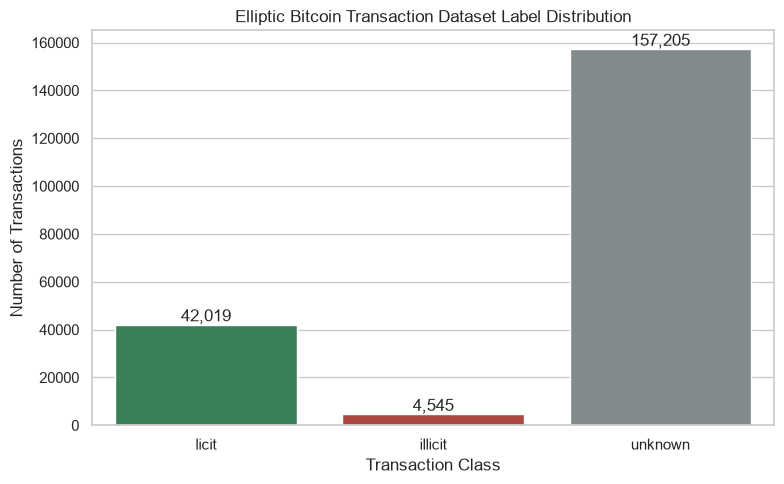

In [11]:
# A bar chart showing the NUMBER of transactions in each class (licit, illicit, unknown) in Elliptic AML dataset.

plot_summary = (
    label_summary
    .reset_index()
    .rename(columns={"label": "class"})
)

fig, ax = plt.subplots(figsize=(8,5))

sns.barplot(
    plot_summary,
    x="class",
    y="count",
    hue="class",
    palette=LABEL_COLORS,
    legend=False,
    ax=ax
)

# Add value count labels to the bars
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}")

ax.set(
    title="Elliptic Bitcoin Transaction Dataset Label Distribution",
    xlabel="Transaction Class",
    ylabel="Number of Transactions"
)

plt.tight_layout()
plt.show()

In [12]:
# Analyze labels over time
time_label_count = (
    transaction_df
    .groupby(["time_step", "label"], observed=True)
    .size() # count the number of transactions for each time_step
    .unstack(fill_value=0) # convert rows to columns to create a DataFrame with time_step 
    .reindex(columns=LABEL_ORDER, fill_value=0) # ensure the columns are in the order of LABEL_ORDER
)

# Separate DataFrame containing the same information.
time_summary = time_label_count.copy()

# Column # 1
time_summary["total"] = time_label_count.sum(axis=1)

# Column # 2
time_summary["labeled"] = (
    time_label_count["licit"] + time_label_count["illicit"]
)

# Column # 3
time_summary["label_coverage_pct"] = (
    time_summary["labeled"] / time_summary["total"] * 100
)

# Column # 4
time_summary["illicit_rate_labeled_pct"] = (
    time_summary["illicit"] / time_summary["total"] * 100
)

display(time_summary)

label,licit,illicit,unknown,total,labeled,label_coverage_pct,illicit_rate_labeled_pct
time_step,,,,,,,
1,2130,17,5733,7880,2147,27.246193,0.215736
2,1099,18,3427,4544,1117,24.581866,0.396127
3,1268,11,5342,6621,1279,19.317324,0.166138
4,1410,30,4253,5693,1440,25.294221,0.526963
5,1874,8,4921,6803,1882,27.664266,0.117595
6,480,5,3843,4328,485,11.206100,0.115527
7,1101,102,4845,6048,1203,19.890873,1.686508
8,1098,67,3292,4457,1165,26.138658,1.503253
9,530,248,4218,4996,778,15.572458,4.963971


C:\Users\Pc Planet\AppData\Local\Temp\ipykernel_13176\4119542624.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()
C:\Users\Pc Planet\AppData\Local\Temp\ipykernel_13176\4119542624.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend()


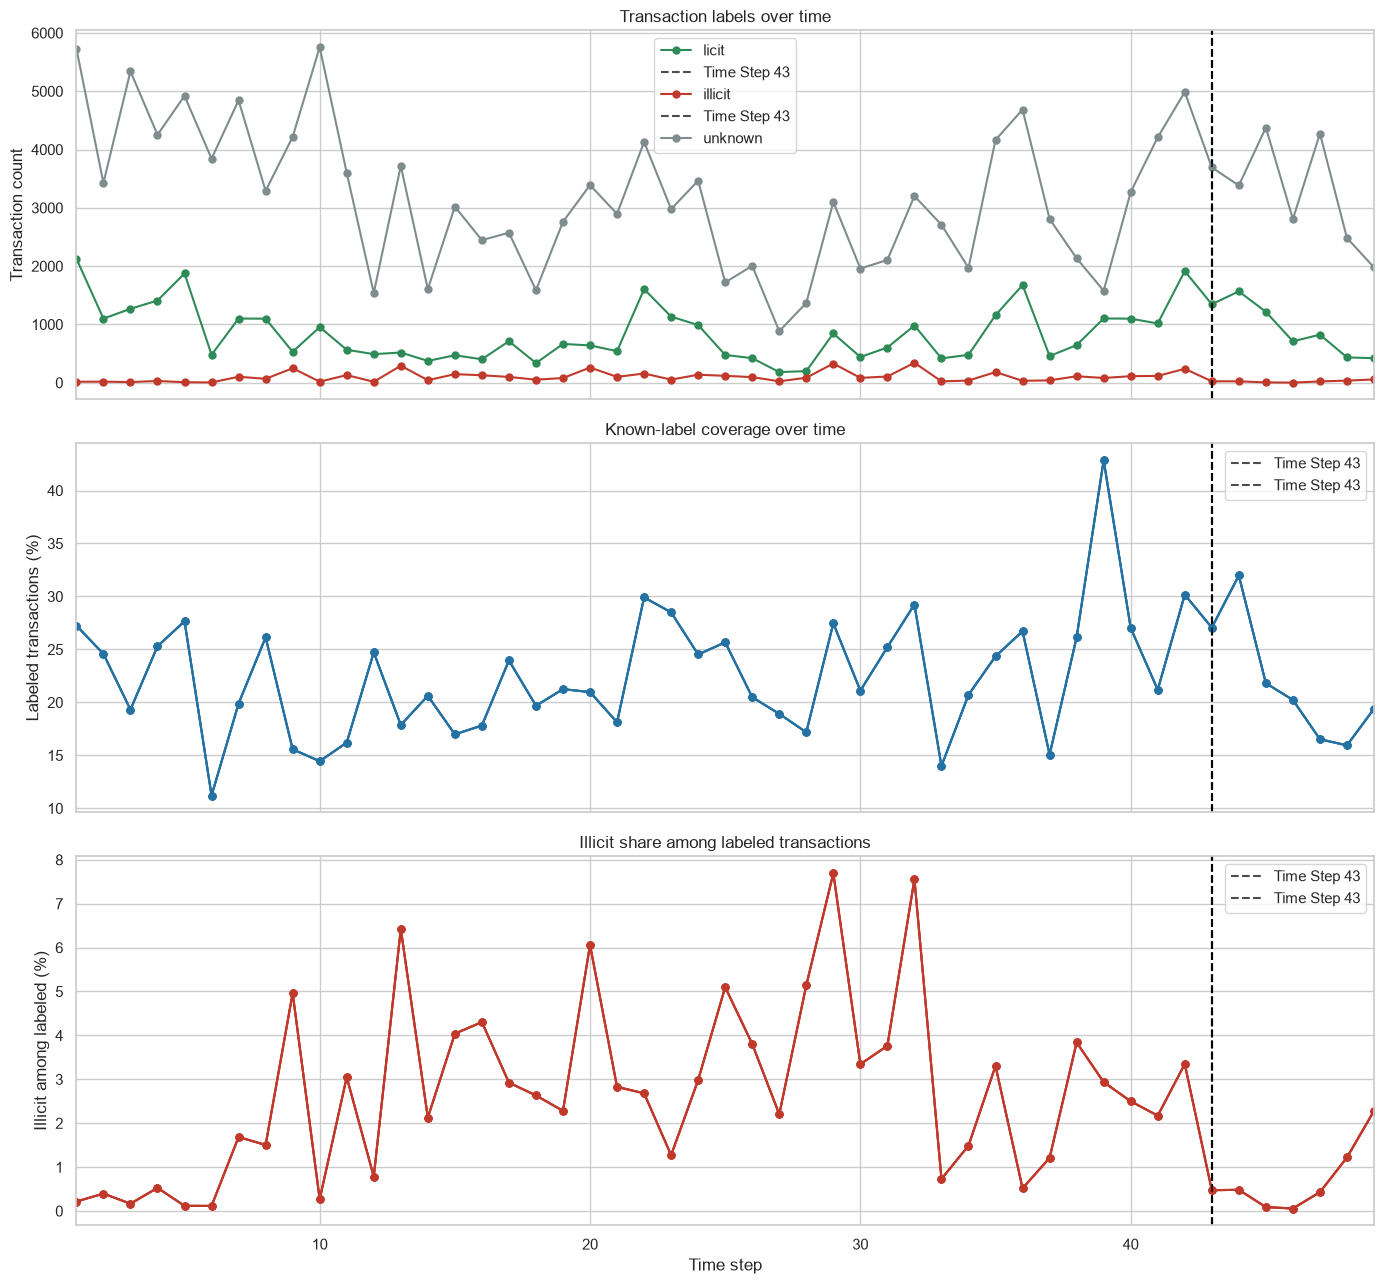

In [13]:
# Create three temporal plots

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(14,13),
    sharex=True
)

for label in LABEL_ORDER:
    # Plot: 1
    axes[0].plot(
        time_label_count.index,
        time_label_count[label],
        marker="o",
        markersize=5,
        label=label,
        color=LABEL_COLORS[label]
    )
    axes[0].set(
        title="Transaction labels over time",
        ylabel="Transaction count",
    )
    axes[0].legend()

    # Plot: 2
    axes[1].plot(
        time_summary.index,
        time_summary["label_coverage_pct"],
        color="#2471A3",
        marker="o",
        markersize=5
    )
    axes[1].set(
        title="Known-label coverage over time",
        ylabel="Labeled transactions (%)"
    )
    axes[1].legend()

    # Plot: 3
    axes[2].plot(
        time_summary.index,
        time_summary["illicit_rate_labeled_pct"],
        color=LABEL_COLORS["illicit"],
        marker="o",
        markersize=5
    )

    axes[2].set(
        title="Illicit share among labeled transactions",
        xlabel="Time step",
        ylabel="Illicit among labeled (%)",
    )
    axes[2].legend()

    for ax in axes:
        ax.axvline(
            43,
            color="black",
            linestyle="--",
            alpha=0.7,
            label="Time Step 43"
        )
    ax.set_xlim(1, 49)
plt.tight_layout()
plt.show()


In [14]:
# Examine feature summaries and correlations
# In this Crypto AML Transaction Monitoring System, its purpose is to understand the numerical features 
# before using them for machine learning—especially their scale, distribution, and missing values.

CONTINUOUS_FEATURE_COLUMNS = (
    LOCAL_TRANSACTION_COLUMNS + AGGREGATE_FEATURE_COLUMNS
)

feature_summary = (
    transaction_df[CONTINUOUS_FEATURE_COLUMNS]
    .describe()
    .transpose()
)

feature_summary["missing"] = (
    transaction_df[CONTINUOUS_FEATURE_COLUMNS]
    .isna()
    .sum()
)

# Display the 15 features with highest standard deviation
display(
    feature_summary
    .sort_values("std", ascending=False)
    .head(15)
)

,count,mean,std,min,25%,50%,75%,max,missing
local_feature_020,203769.0,-1.078312e-08,1.000003,-1.373657,-1.373657,0.887058,0.887058,0.887058,0
local_feature_071,203769.0,1.198124e-09,1.000003,-0.030026,-0.030026,-0.030026,-0.030026,137.851868,0
local_feature_073,203769.0,-1.198124e-09,1.000003,-0.015071,-0.015071,-0.015071,-0.015071,151.035172,0
local_feature_093,203769.0,-3.145077e-08,1.000003,-1.084845,-1.084845,0.025217,1.135279,1.135279,0
local_feature_063,203769.0,-1.677374e-08,1.000003,-1.315388,-1.315388,0.475331,0.923011,0.923011,0
aggregate_feature_022,203769.0,-1.916999e-08,1.000003,-1.772828,-1.230441,0.396719,0.939106,2.566266,0
aggregate_feature_032,203769.0,2.396249e-09,1.000003,-0.145126,-0.143707,-0.143707,-0.142288,18.455158,0
aggregate_feature_057,203769.0,-1.437749e-08,1.000003,-1.059868,-1.059868,-0.453330,0.759748,3.185904,0
aggregate_feature_059,203769.0,7.188747e-09,1.000003,-1.116918,-1.116918,0.185597,0.475920,1.488113,0
local_feature_010,203769.0,3.744139e-10,1.000002,-0.049707,-0.049707,-0.049707,-0.049707,189.186951,0


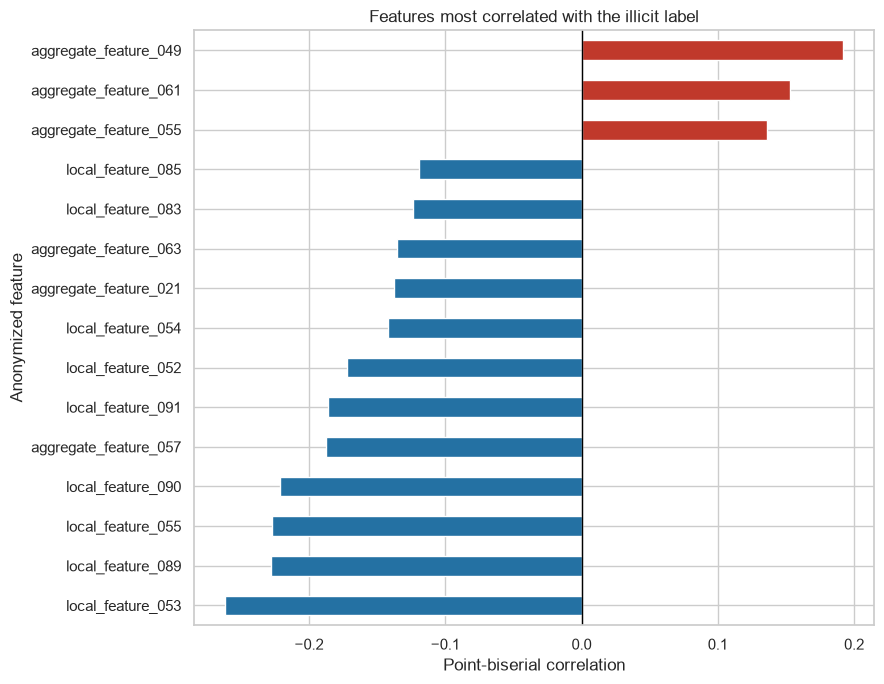

In [15]:
# Measure descriptive correlation with the "illicit" label

# Convert illicit into a binary target
illicit_target = (
    labeled_df["label"]
    .eq("illicit") # ass boolean (T,F)
    .astype("int8") # as binary (0,1)
)

# Calculate correlation between features and illicit target
feature_label_correlations = (
    labeled_df[CONTINUOUS_FEATURE_COLUMNS]
    .corrwith(illicit_target)
    .dropna() # removes features where the correlation result is NaN.
)

# Select the 15 strongest correlations
top_correlations = (
    feature_label_correlations
    .loc[
        feature_label_correlations
        .abs()
        .nlargest(15)
        .index
    ]
    .sort_values()
)
# display(top_correlations)

# Create the chart
fig, ax = plt.subplots(figsize=(9,7))

top_correlations.plot(
    kind="barh",
    color=[
        LABEL_COLORS["illicit"] if value > 0 else "#2471A3"
        for value in top_correlations
    ],
    ax=ax,
)

ax.set(
    title="Features most correlated with the illicit label",
    xlabel="Point-biserial correlation",
    ylabel="Anonymized feature",
)

ax.axvline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()

These correlations are descriptive only. 

We will not use this full-dataset ranking for model feature selection, because it includes future time periods.

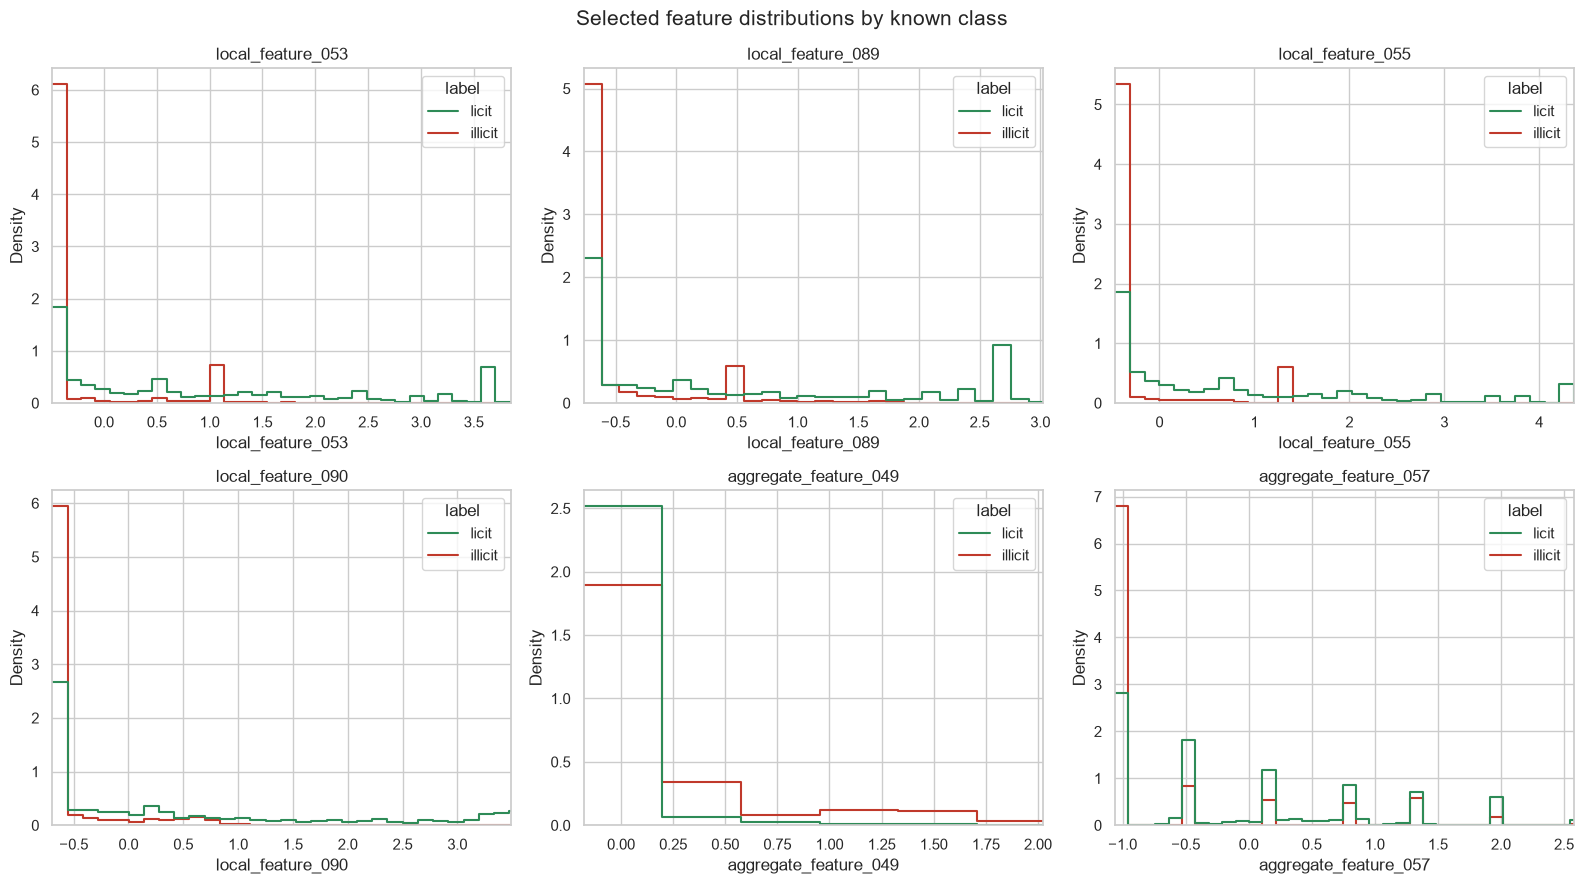

In [16]:
# Plot selected feature distributions

selected_features = (
    feature_label_correlations
    .abs()
    .nlargest(6)
    .index
    .tolist() # Return a list of the values.
)

plot_samples = []

# Select rows belonging to each class [i.e. "licit", "illicit"]
for label in ["licit", "illicit"]:
    class_rows = labeled_df.loc[labeled_df["label"] == label]

    # Randomly sample transactions
    plot_samples.append(
        class_rows.sample(
            n=min(5_000, len(class_rows)),
            random_state=RANDOM_SEED
        )
    )

feature_plot_df = pd.concat(
    plot_samples,
    ignore_index=True,
)

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(16, 9)
)

# Loop through features and plots
for feature, ax in zip(selected_features, axes.flat):
    lower, upper = labeled_df[feature].quantile([0.01, 0.99]) # used to control the visible X-axis range.

    sns.histplot(
        data=feature_plot_df,
        x=feature,
        hue="label",
        hue_order=["licit", "illicit"],
        palette=LABEL_COLORS,
        bins=40,
        stat="density",
        common_norm=False,
        element="step",
        fill=False,
        ax=ax
    )

    ax.set_xlim(lower, upper)
    ax.set_title(feature)

    fig.suptitle(
        "Selected feature distributions by known class",
        fontsize=15,
        )

plt.tight_layout()
plt.show()

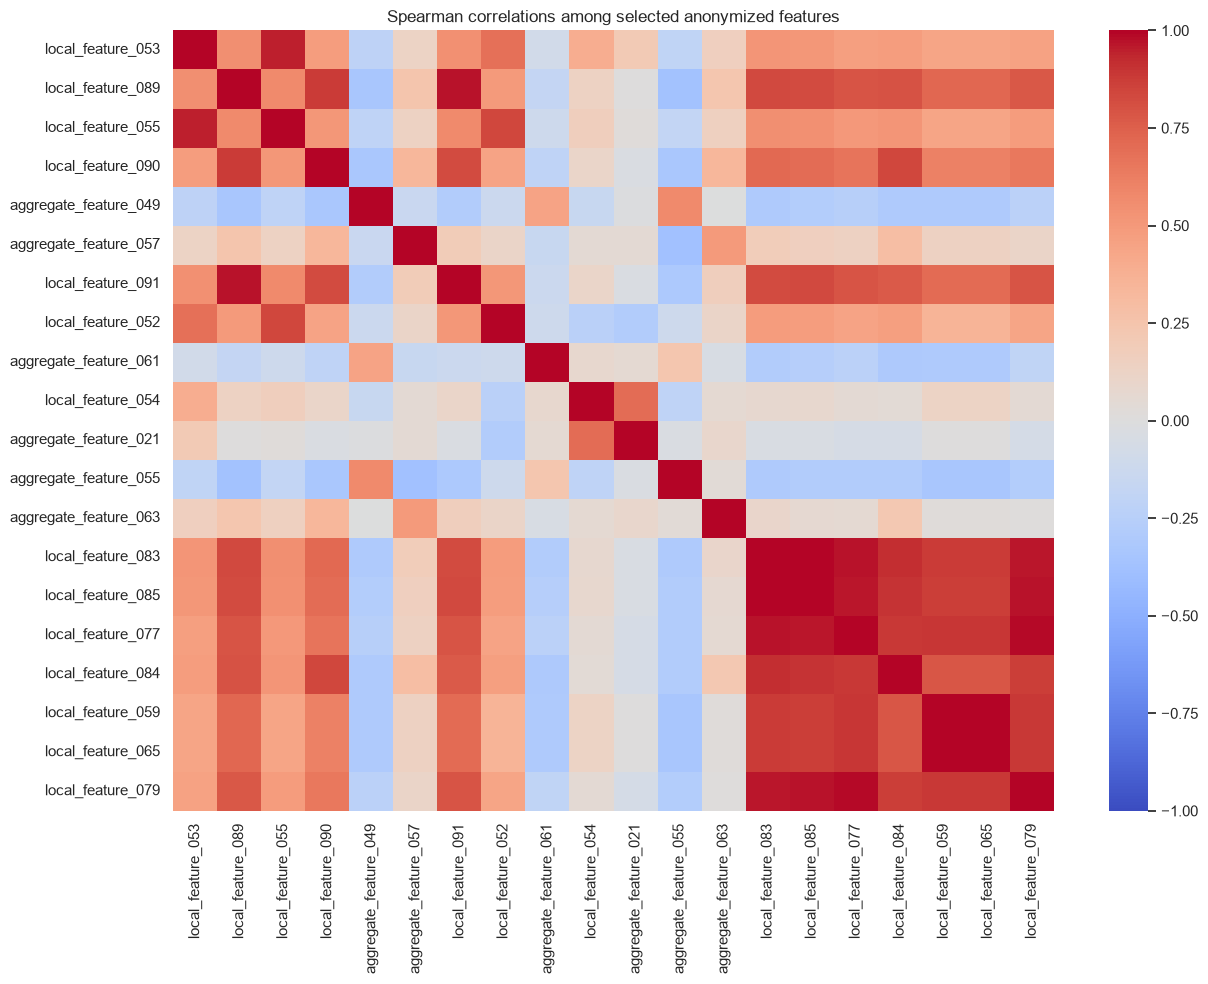

In [17]:
# For feature-to-feature relationships:
# This code performs feature-to-feature correlation analysis 
# on the 20 continuous features most strongly associated with the illicit label.

# Its purpose is different from your previous correlation code:

# Previous section: feature ↔ illicit target
# This code: feature ↔ feature

# This helps identify redundant features, highly related variables, 
# and possible multicollinearity before ML modeling.
correlation_features = (
    feature_label_correlations
    .abs()
    .nlargest(20)
    .index
)

# Why use Spearman here?
# This is useful for transaction data because financial/blockchain features can be:
# highly skewed
# affected by extreme values
# non-normally distributed
# Spearman can therefore be useful for detecting monotonic relationships that aren't necessarily linear.
feature_correlation_matrix = (
    labeled_df[correlation_features]
    # Spearman correlation measures whether two variables 
    # have a monotonic relationship.
    .corr(method="spearman")
)

# display(feature_correlation_matrix)
fig, ax = plt.subplots(figsize=(13, 10))

sns.heatmap(
    feature_correlation_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
)

ax.set_title(
    "Spearman correlations among selected anonymized features"
)

plt.tight_layout()
plt.show()

## Transaction Graph Analysis

### Calculate graph statistics
In this Crypto AML project, the transaction data is represented as a **directed graph**:

1. **Each transaction is represented as a node.**
2. **Each transaction-to-transaction relationship is represented as a directed edge.**

The graph analysis calculates several important network statistics.

### 1. In-Degree

**In-degree** measures the number of edges entering a node.

For example:

```text
A ───→ B
```

Transaction `B` has an **in-degree of 1** because one edge enters `B`.

If:

```text
A ───→ C
B ───→ C
D ───→ C
```

then:

```text
C has an in-degree of 3
```

---

### 2. Out-Degree

**Out-degree** measures the number of edges leaving a node.

For example:

```text
A ───→ B
A ───→ C
A ───→ D
```

Transaction `A` has an **out-degree of 3** because three edges leave `A`.

---

### 3. Graph Density

**Graph density** measures how many of the possible connections between transactions actually exist.

* Density close to `0` → sparse graph with relatively few connections.
* Density close to `1` → highly connected graph.

For a directed graph without self-loops:

```text
Density = Number of edges / [Number of nodes × (Number of nodes − 1)]
```

---

### 4. Isolated Nodes

An **isolated node** is a transaction that does not appear as either a source or a target in any edge.

Therefore, an isolated transaction has:

```text
in-degree  = 0
out-degree = 0
```

---

### 5. Self-Loops

A **self-loop** occurs when a transaction points to itself:

```text
A ───→ A
```

Here, the source and target transaction IDs are identical.

---

### 6. Duplicate Edges

**Duplicate edges** occur when the same edge appears more than once in the dataset.

For example:

```text
A ───→ B
A ───→ B
```

The second edge is a duplicate of the first.

These checks help validate the transaction graph and provide a better understanding of its structure before using graph-based features for AML analysis.


### Graph Density

**Density** measures **how connected your transaction graph is**.

Your code calculates:

```python
density = edge_count / (node_count * (node_count - 1))
```

For a **directed graph**, `node_count × (node_count - 1)` is the maximum possible number of directed edges between different nodes.

### Example

Suppose you have:

* **100 nodes**
* **500 directed edges**

Maximum possible edges:

```text
100 × 99 = 9,900
```

Density:

```text
500 / 9,900 = 0.0505
```

So the graph density is approximately **5.05%**.

### Interpretation

* **Density ≈ 0** → very sparse graph; few connections
* **Density ≈ 1** → extremely dense graph; almost every node connects to every other node

For an **Ethereum transaction graph**, density will usually be **very low**, because there are enormous numbers of possible node-to-node connections but only a relatively small number actually occur.

**In simple terms:**

> Density tells you **what proportion of all possible transaction-to-transaction connections actually exist**.


In [18]:
# Create the list of transaction nodes
node_ids = pd.Index(transaction_df["transaction_id"])

# Calculate in-degree
in_degree = (
    edges_df["target_transaction_id"]
    .value_counts()
    .reindex(node_ids, fill_value=0)
)

# Calculate out-degree
out_degree = (
    edges_df["source_transaction_id"]
    .value_counts()
    .reindex(node_ids, fill_value=0)
)

total_degree = in_degree + out_degree

# This finds every transaction ID that appears anywhere in the edges.
edge_endpoint_ids = pd.Index(
    pd.concat([
        edges_df["source_transaction_id"],
        edges_df["target_transaction_id"]
    ],
    ignore_index=True,
    ).unique()
)

node_count = len(node_ids)
edge_count = len(edges_df)

graph_summary = pd.Series({
    "nodes": node_count,
    "directed_edges": edge_count,
    "density": edge_count / (node_count * (node_count - 1)),
    "isolated_nodes": len(node_ids.difference(edge_endpoint_ids)),
    "zero_in_degree_nodes": int((in_degree == 0).sum()),
    "zero_out_degree_nodes": int((out_degree == 0).sum()),
    "mean_in_degree": in_degree.mean(),
    "mean_out_degree": out_degree.mean(),
    "maximum_in_degree": int(in_degree.max()),
    "maximum_out_degree": int(out_degree.max()),
    "self_loops": int(
        (
            edges_df["source_transaction_id"] ==
            edges_df["target_transaction_id"]
        ).sum()
    ),
    "duplicate_edges": int(edges_df.duplicated().sum()),
})

display(graph_summary.to_frame("value"))

,value
nodes,203769.000000
directed_edges,234355.000000
density,0.000006
isolated_nodes,0.000000
zero_in_degree_nodes,55322.000000
zero_out_degree_nodes,37424.000000
mean_in_degree,1.150101
mean_out_degree,1.150101
maximum_in_degree,284.000000
maximum_out_degree,472.000000


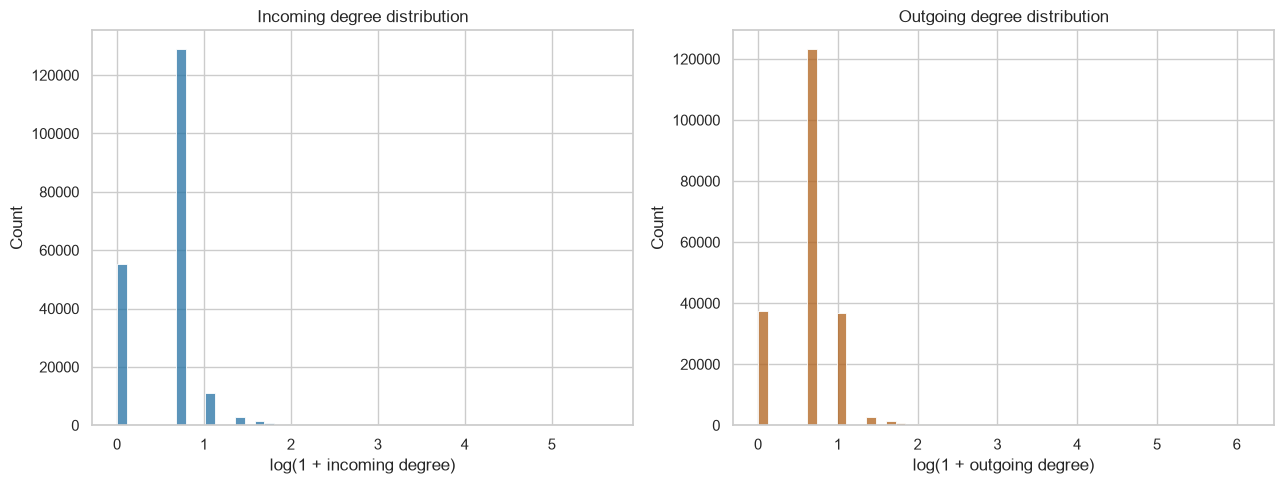

In [19]:
# Plot the heavy-tailed degree distributions:

fig, axes = plt.subplots(1,2, figsize=(13,5))

sns.histplot(
    np.log1p(in_degree),
    bins=50,
    ax=axes[0],
    color="#2471A3",
)

axes[0].set(
    title="Incoming degree distribution",
    xlabel="log(1 + incoming degree)"
)

sns.histplot(
    np.log1p(out_degree),
    bins=50,
    ax=axes[1],
    color="#AF601A"
)

axes[1].set(
    title="Outgoing degree distribution",
    xlabel="log(1 + outgoing degree)"
)

plt.tight_layout()
plt.show()

In [20]:
# Check the temporal consistency of edges

# Create a transaction → time-step mapping
time_by_transaction = (
    transaction_df
        .set_index("transaction_id") # set the "transaction Id" as index
        ["time_step"] # select omnly "Time_step" column
    )

# Find the time step of each source transaction
source_time = (
    edges_df["source_transaction_id"]
    .map(time_by_transaction)
)

# Find the time step of each target transaction
target_time = (
    edges_df["target_transaction_id"]
    .map(time_by_transaction)
)

# Count cross-time edges
cross_time_edges = int((source_time != target_time).sum())

print(f"Edges joining different time steps: {cross_time_edges:,}")
# The canonical data should report zero cross-time edges.
# Edges joining different time steps: 0


Edges joining different time steps: 0


### Investigate time step 43

Why investigate time step 43?

The important observation is:

 - Time 42 → ~11.10% illicit
 - Time 43 → ~1.75% illicit
 - Following steps → unusually low

This could indicate several things:

- A genuine change in transaction behavior
- A change in the underlying data
- A labeling/data-collection issue
- A change in how transactions were classified
- A temporal/data-boundary effect

In [21]:
display(
    time_summary.loc[
        41:45,
        ["licit",
         "illicit",
         "unknown",
         "labeled",
         "label_coverage_pct",
         "illicit_rate_labeled_pct",],
    ].round(3)
)
# print(time_summary.columns.tolist())

label,licit,illicit,unknown,labeled,label_coverage_pct,illicit_rate_labeled_pct
time_step,,,,,,
41,1016,116,4210,1132,21.191,2.171
42,1915,239,4986,2154,30.168,3.347
43,1346,24,3693,1370,27.059,0.474
44,1567,24,3384,1591,31.980,0.482
45,1216,5,4377,1221,21.811,0.089


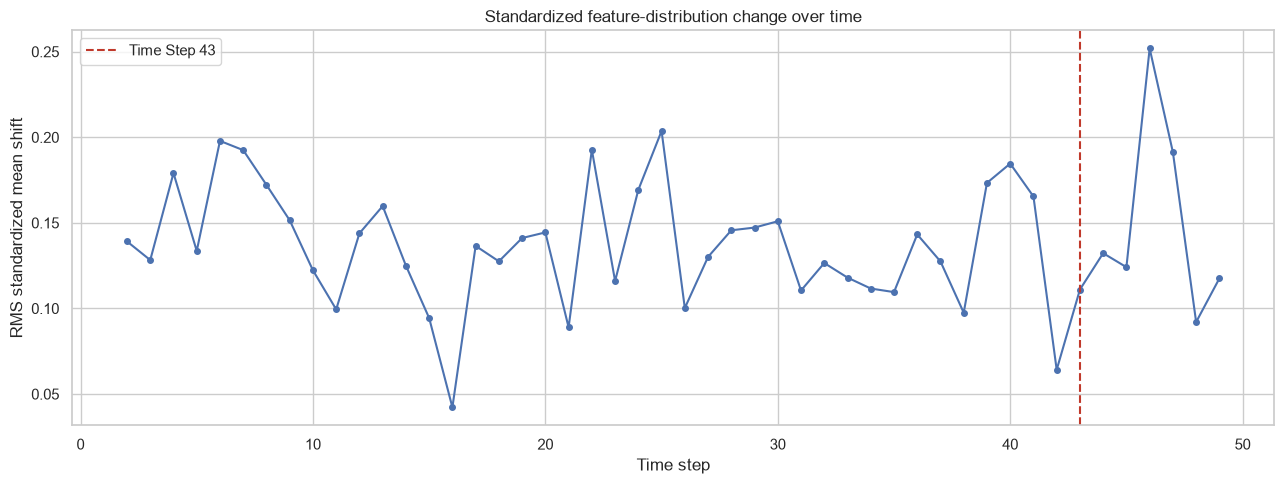

In [22]:
# This code measures how much the average transaction-feature profile changes from 
# one time step to the next, after standardizing each feature by its overall standard deviation.

# Calculates the overall standard deviation of every continuous feature.
global_feature_std = (
    transaction_df[CONTINUOUS_FEATURE_COLUMNS]
    .std()
    .replace(0, np.nan)
)

# calculates the mean of every feature for every time step.
time_feature_means = (
    transaction_df
    .groupby("time_step")[CONTINUOUS_FEATURE_COLUMNS]
    .mean()
)

# Calculates the changes between consecutive time steps.
standardized_centroid_shift = (
    time_feature_means
    .diff() # change from the previous time step
    .div(global_feature_std) # divides each feature's change by its global standard deviation.
    .pow(2) # Raises value to *2, remove +/-
    .mean(axis=1)
    .pow(0.5)
)
# display(standardized_centroid_shift)

fig, ax = plt.subplots(figsize=(13,5))

ax.plot(
    standardized_centroid_shift.index,
    standardized_centroid_shift,
    marker="o",
    markersize=4,
)

# Mark time step 43
ax.axvline(
    43,
    color=LABEL_COLORS["illicit"],
    linestyle="--",
    label="Time Step 43"
)

ax.set(
    title="Standardized feature-distribution change over time",
    xlabel="Time step",
    ylabel="RMS standardized mean shift",
)
ax.legend()

plt.tight_layout()
plt.show()

,absolute_standardized_mean_shift
local_feature_002,0.727619
aggregate_feature_050,0.404300
aggregate_feature_051,0.389778
aggregate_feature_052,0.335584
aggregate_feature_016,0.283492
aggregate_feature_015,0.277449
aggregate_feature_014,0.273896
local_feature_052,0.243474
aggregate_feature_013,0.219579
local_feature_055,0.208686


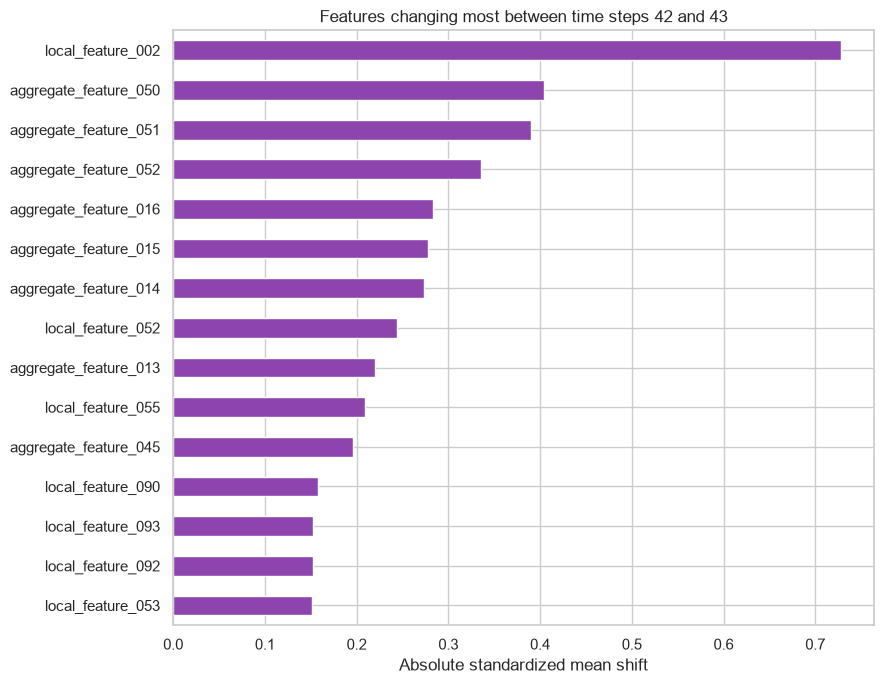

In [23]:
# This code performs a feature-level investigation of the change from time step 42 to 43.
# The previous code told us whether the overall feature distribution changed.
# This code tells:
# Which specific features changed the most between time steps 42 and 43?


# Calculate feature changes from 42 → 43
feature_shift_42_to_43 = (
    (
        time_feature_means.loc[43] -
        time_feature_means.loc[42]
    )
    .div(global_feature_std)
    .abs()
    .sort_values(ascending=False)
    .head(15)
)
display(
    feature_shift_42_to_43
    .rename("absolute_standardized_mean_shift")
    .to_frame()
    )

fig, ax = plt.subplots(figsize=(9, 7))

feature_shift_42_to_43.sort_values().plot(
    kind="barh",
    color="#8E44AD",
    ax=ax
)

ax.set(
    title="Features changing most between time steps 42 and 43",
    xlabel="Absolute standardized mean shift",
)

plt.tight_layout()
plt.show()

### EDA findings and limitations

- Only about 22.85% of transactions have known labels.
- Illicit transactions represent about 9.76% of labeled transactions and
  2.23% of the complete dataset.
- Unknown transactions cannot be treated as legitimate examples.
- Label prevalence and coverage change substantially across time.
- The illicit share drops sharply at time step 43, indicating temporal drift.
- The graph is sparse and directed, with a small average degree and a few
  comparatively high-degree transactions.
- All observed edges connect transactions within the same time step.
- Features are anonymized, so statistical importance cannot automatically be
  translated into compliance explanations.
- Correlations observed here do not establish causation.
- Full-dataset EDA must not be used for model selection; preprocessing and
  feature selection will be fitted only on the appropriate training periods.

## 4. Leakage-safe dataset preparation

Only transactions with known labels are used for supervised modeling.

Data is divided chronologically so that preprocessing, model training,
calibration, threshold selection, and final testing use separate time periods.
Unknown transactions remain in the original transaction table for later
exploratory scoring.

In [24]:
# Creating the supervised target

# Map licit transactions to 0 and illicit transactions to 1:
TARGET_MAP = {
    "licit": 0,
    "illicit": 1
}

# We only want transactions with labels that model understands.
# creates an independent copy
supervised_df = (
    transaction_df.loc[transaction_df["label"].isin(TARGET_MAP)].copy()
)

# Creating the target column
supervised_df["target"] = (
    supervised_df["label"]
    .astype("string")
    .map(TARGET_MAP)
    .astype("uint8")
)

print(f"All Transactions: {len(transaction_df)}")
print(f"Supervised Transactions: {len(supervised_df)}")
print(f"Excluded UNKNOWN rows: {len(transaction_df) - len(supervised_df)}")

display(supervised_df["target"].value_counts().rename(index={0: "licit", 1: "illicit"}).to_frame("count"))




All Transactions: 203769
Supervised Transactions: 46564
Excluded UNKNOWN rows: 157205


,count
target,
licit,42019
illicit,4545


In [25]:
# Define the two feature variants
# The local variant contains the time step and 93 local features. 
# The full variant adds 72 aggregate features.

LOCAL_MODEL_FEATURES = (
    "time_step",
    *LOCAL_TRANSACTION_COLUMNS
)

ALL_MODEL_FEATURES = (
    *LOCAL_MODEL_FEATURES,
    *AGGREGATE_FEATURE_COLUMNS,
)

FEATURE_SETS = {
    "local_94": LOCAL_MODEL_FEATURES,
    "all_166": ALL_MODEL_FEATURES
}

print(f"Local feature count: {len(LOCAL_MODEL_FEATURES)}")
print(f"All feature count:   {len(ALL_MODEL_FEATURES)}")

Local feature count: 94
All feature count:   166


In [26]:
# Validate the feature contracts
require(
    len(LOCAL_MODEL_FEATURES) == 94,
    "the local feature variant must contain 94 features",
)

require(
    len(ALL_MODEL_FEATURES) == 166,
    "the complete feature variant must contain 166 features",
)

require(
    tuple(ALL_MODEL_FEATURES) == tuple(NODE_FEATURE_COLUMNS),
    "the complete feature variant does not match the validated node schema",
)

for excluded_column in [
    "transaction_id",
    "label",
    "target",]:

    # EXCLUDED_COLUMNS must not be used in model training
    require(
        excluded_column not in ALL_MODEL_FEATURES,
        f"{excluded_column!r} must not be used as a model feature",
    )

    # Checking for duplicate columns
    require(
        len(set(ALL_MODEL_FEATURES)) == len(ALL_MODEL_FEATURES),
        "the feature list contains duplicate columns",
    )
    
# display(len(ALL_MODEL_FEATURES))
# display(len(NODE_FEATURE_COLUMNS))

### Create the chronological partitions
This code divides labelled transaction dataset into four time-based partitions:
1. Training
2. Calibration
3. Threshold validation
4. Test
-------------------------

| Partition | Time steps | Permitted use |
|---|---:|---|
| Training | 1–25 | Fit preprocessing and models; internal temporal tuning |
| Calibration | 26–30 | Fit probability calibration after fixing the base model |
| Threshold validation | 31–34 | Select the alert threshold and final candidate |
| Test | 35–49 | Final evaluation only |

In [27]:
# Instead of randomly splitting
# Create the chronological partitions
PARTITION_ORDER = [
    "training",
    "calibration",
    "threshold_validation",
    "test",
]

# Create the partition column
# partition column is divided coronological order
supervised_df["partition"] = pd.cut(
    supervised_df["time_step"], # cut time_step into 4
    # Define bin boundaries and corresponding labels
    bins=[0, 25, 30, 34, 49],
    labels=PARTITION_ORDER,
    include_lowest=True, # dont skip lowest value i.e.; 0
    right=True # include the right value of that particulat bin
)

# Validate that every row received a partition label
require(
    supervised_df["partition"].notna().all(),
    "one or more supervised rows were not assigned to a partition",
)
# creates a dictionary containing four separate DataFrames.
partition_frames = {
    partition: (
        supervised_df
        .loc[supervised_df["partition"] == partition]
        .copy()
    )
    for partition in PARTITION_ORDER
}

# print(partition_frames)


In [28]:
# Summarize the partitions
partition_summary = (
    supervised_df
    .groupby(["partition", "label"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(
        index=PARTITION_ORDER,
        columns=["licit", "illicit"],
        fill_value=0
    )
)

# createa "total" column
partition_summary["total"] = partition_summary.sum(axis=1)

# "illicite_percentage" column
partition_summary["illicit_pct"] = (
    partition_summary["illicit"] /
    partition_summary["total"] * 100
)
display(partition_summary.round(3))

# The changing illicit percentage is further evidence that 
# random splitting would be misleading.

label,licit,illicit,total,illicit_pct
partition,,,,
training,21863,2337,24200,9.657
calibration,2088,617,2705,22.810
threshold_validation,2481,508,2989,16.996
test,15587,1083,16670,6.497


In [29]:
# This dictionary defines the exact time steps that should belong to each partition.
EXPECTED_PARTITION_TIME_STEPS = {
    "training": set(range(1, 26)),
    "calibration": set(range(26, 31)),
    "threshold_validation": set(range(31, 35)),
    "test": set(range(35, 50)),
}

EXPECTED_PARTITION_COUNTS = {
    "training": {
        "licit": 21_863,
        "illicit": 2_337,
    },
    "calibration": {
        "licit": 2_088,
        "illicit": 617,
    },
    "threshold_validation": {
        "licit": 2_481,
        "illicit": 508,
    },
    "test": {
        "licit": 15_587,
        "illicit": 1_083,
    },
}

# display(EXPECTED_PARTITION_COUNTS)

In [30]:
# Validate each partition
# Go through each dataset partition and make sure
# its contents are exactly what we expect before using it for ML.

for partition, frame in partition_frames.items():
    observed_time_steps = set(
        frame["time_step"].astype(int).unique()
    )

    require(
        observed_time_steps ==
        EXPECTED_PARTITION_TIME_STEPS[partition],
        f"{partition} has incorrect time steps:"
        f"{sorted(observed_time_steps)}"
    )

    observed_counts = (
        frame["label"]
        .value_counts()
        .reindex(["licit", "illicit"], fill_value=0)
        .astype(int)
        .to_dict()
    )

    require(
        observed_counts == EXPECTED_PARTITION_COUNTS[partition],
        f"{partition} has unexpected label counts:"
        f"{observed_counts}"
    )

    require(
        not frame["label"].astype("string").eq("unknown").any(),
        f"{partition} contains unknown labels",
    )

    require(
        set(frame["target"].unique()) <= {0, 1},
        f"{partition} contains an invalid target value",
    )
# display(partition_frames)

In [31]:
# Check chronological ordering
# Take each pair of neighboring partitions. 
# Find the last time step in the earlier partition 
# and the first time step in the later partition.
# Make sure the earlier partition ends strictly 
# before the later partition begins.
# If not, report a chronological overlap

for earlier, later in zip(
    PARTITION_ORDER,
    PARTITION_ORDER[1:],
):
    earlier_max = (
        partition_frames[earlier]["time_step"].max()
    )
    later_min = (
        partition_frames[later]["time_step"].min()
    )

    require(
        earlier_max < later_min,
        f"{earlier} overlaps chronologically with {later}",
    )

In [32]:
# Check transaction-ID disjointness
for left_index, left_name in enumerate(PARTITION_ORDER):
    left_ids = set(
        partition_frames[left_name]["transaction_id"]
    )

    for right_name in PARTITION_ORDER[left_index + 1:]:
        right_ids = set(
            partition_frames[right_name]["transaction_id"]
        )

        overlap = left_ids.intersection(right_ids)

        require(
            not overlap,
            f"{left_name} and {right_name} share "
            f"{len(overlap):,} transaction IDs",
        )

In [33]:
# Check complete assignment
partition_row_total = sum(
    len(frame)
    for frame in partition_frames.values()
)

require(
    partition_row_total == len(supervised_df),
    "partition row counts do not equal the supervised dataset size",
)

require(
    supervised_df["transaction_id"].is_unique,
    "the supervised dataset contains duplicate transaction IDs",
)

print("Chronological partition validation passed.")

Chronological partition validation passed.


### Expected feature-matrix shapes:
| Partition | Local | All |
|---|---:|---:|
| Training | `(24200, 94)` | `(24200, 166)` |
| Calibration | `(2705, 94)` | `(2705, 166)` |
| Threshold validation | `(2989, 94)` | `(2989, 166)` |
| Test | `(16670, 94)` | `(16670, 166)` |

In [34]:
# IMPORTS

from sklearn.impute import SimpleImputer # Handles missing values with mean, medien, etc...
from sklearn.preprocessing import StandardScaler # Standardizes numerical features
from sklearn.pipeline import Pipeline # Chains preprocessing steps together
from sklearn.base import clone # Creates a fresh unfitted copy

In [35]:
# This code defines reusable preprocessing blueprints for linear and tree-based models, 
# then provides a safe way to create a fresh, unfitted copy of the appropriate blueprint
# so preprocessing can be fitted independently on training data without accidentally reusing learned state.

# Create one template for "linear models"
linear_preprocessor_template = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median"), # Handling Missing values using Median
    ),
    (
        "scaler",
        StandardScaler() # Standardizes numerical features
    )
])

# Create one template for "tree models"
# Tree-based models generally don't require features to be standardized.
tree_preprocessor_template = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median"),
    )
])

PREPROCESSOR_TEMPLATES = {
    "linear": linear_preprocessor_template,
    "tree": tree_preprocessor_template,
}

# defines a function that creates a preprocessing pipeline.
def make_preprocessor(
        model_family: str,
) -> Pipeline:
    """Return a FRESH, UN-FITTED preprocessing pipeline."""

    if model_family not in PREPROCESSOR_TEMPLATES:
        raise KeyError(
            f"Unknown model family {model_family!r}."
            f"Choose from {list(PREPROCESSOR_TEMPLATES)}."
        )
    
    # clone() gives you a fresh estimator with the same configuration,
    # but without the learned state.
    return clone(
        PREPROCESSOR_TEMPLATES[model_family]
    )


In [36]:
# Inspect
print("Linear Preprocessing:")
display(make_preprocessor("linear"))

print("Tree preprocessing:")
display(make_preprocessor("tree"))

Linear Preprocessing:


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account fo

Tree preprocessing:


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness des

Leakage rules to preserve
- Never fit an imputer or scaler on the complete dataset.
- Never use calibration data for model fitting or hyperparameter selection.
- Never use threshold-validation data to fit model coefficients.
- Never examine test predictions while changing the model.
- Never include transaction_id, label, target, or partition as features.
- Do not apply SMOTE before a chronological split.
- Keep unknown transactions outside supervised modeling.
- Do not select features using the full-dataset EDA correlations.
- Keep the final test partition untouched until final Step.

In [37]:
# Add the missing data-access helper
def get_xy(
    partition: str,
    feature_set: str,
) -> tuple[pd.DataFrame, pd.Series]:
    """
    Return an isolated feature matrix and target vector.

    Centralizing partition access reduces the risk of accidentally selecting
    rows from calibration, threshold-validation, or test data during training.
    """

    if partition not in partition_frames:
        raise KeyError(
            f"Unknown partition {partition!r}. "
            f"Choose from {list(partition_frames)}."
        )

    if feature_set not in FEATURE_SETS:
        raise KeyError(
            f"Unknown feature set {feature_set!r}. "
            f"Choose from {list(FEATURE_SETS)}."
        )

    frame = partition_frames[partition]
    feature_columns = list(FEATURE_SETS[feature_set])

    X = frame.loc[:, feature_columns].copy()
    y = frame.loc[:, "target"].copy()

    return X, y

In [38]:
# verify
for feature_set in FEATURE_SETS:
    X_check, y_check = get_xy(
        partition="training",
        feature_set=feature_set,
    )

    print(
        f"{feature_set}: X={X_check.shape}, y={y_check.shape}"
    )

local_94: X=(24200, 94), y=(24200,)
all_166: X=(24200, 166), y=(24200,)


## 5. Baselines and class-weighted logistic regression

Models are evaluated with expanding-window temporal validation conducted
entirely within training time steps 1–25.

Average precision is the primary tuning metric because the illicit class is
rare and the final system will rank transactions for analyst review. Metrics
calculated at a 0.50 threshold are provisional; the operational alert
threshold will be selected later using the dedicated threshold-validation
partition.

In [39]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

In [40]:
# This code creates three expanding training windows and future validation windows 
# so that ML model is tested on future time periods without using future information
# during training.

# Normally, cross-validation might randomly split data:
# Train → Random data → Validation
# But with time-series/blockchain transaction data, random splitting can cause data leakage because the model could effectively learn from future transactions.
# Instead, this code uses:
# Past → Train → Future → Validate


# Temporal Cross-Validation = Cross-validation that respects the order of time.
TEMPORAL_CV_FOLDS = [
    {
        "name": "fold_1",
        "train_steps": range(1, 11), # Time steps 1-25 for training
        "validation_steps": range(11, 16) # Time steps 11-16 for validation 
    },
    {
        "name": "fold_2",
        "train_steps": range(1, 16),
        "validation_steps": range(16, 21),
    },
    {
        "name": "fold_3",
        "train_steps": range(1, 21),
        "validation_steps": range(21, 26),
    }
]

In [41]:
training_frame = partition_frames["training"]

fold_summary_rows = []
all_validations_steps = set()

for fold in TEMPORAL_CV_FOLDS:
    train_steps = set(fold["train_steps"]) # sets are very useful for checking:
    validation_steps = set(fold["validation_steps"]) # overlap, membership, union

    # Training and validation periods must never contain the same time step.
    require(
        train_steps.isdisjoint(validation_steps),
        f"{fold['name']} has overlapping time steps."
    )

    # Every validation period must occur strictly after every training period.
    # This prevents the model from learning from the future.
    require(
        max(train_steps) < min(validation_steps),
        f"{fold['name']} is not chronologically ordered."
    )

    # This identifies which rows belong to the training time periods.
    # also called a Boolean mask.
    train_mask = training_frame["time_step"].isin(train_steps)
    validation_mask = training_frame["time_step"].isin(validation_steps)

    # Extract training target and validation target
    y_fold_train = training_frame.loc[train_mask, "target"]
    y_fold_validation = training_frame.loc[validation_mask, "target"]

    # Precision, recall, and ROC-AUC require both classes to be represented.
    # Check that training has both classes
    require(
        set(y_fold_train.unique()) == {0, 1},
        f"{fold["name"]} training data does not contain both classes"
    )
    require(
        set(y_fold_validation.unique()) == {0, 1},
        f"{fold["name"]} validation data does not contain both classes"
    )

    # Add all 3 validation periods to the set
    all_validations_steps.update(validation_steps)

    fold_summary_rows.append({
        "fold": fold["name"],
        "training_steps": (
            f"{min(train_steps)}-{max(train_steps)}"
        ),
        "validation_steps": (
            f"{min(validation_steps)}-{max(validation_steps)}"
        ),
        "training_rows": len(y_fold_train),
        "training_illicit": int((y_fold_train == 1).sum()),
        "validation_rows": len(y_fold_validation),
        "validation_illicit": int((y_fold_validation == 1).sum()),
        "validation_illicit_rate": (
            y_fold_validation.mean()
        ),
    })

require(
    all_validations_steps == set(range(11, 26)),
    "the temporal folds do not cover validation steps 11 through 25 exactly"
)

fold_summary_df = pd.DataFrame(fold_summary_rows)

display(fold_summary_df)


,fold,training_steps,validation_steps,training_rows,training_illicit,validation_rows,validation_illicit,validation_illicit_rate
0,fold_1,1-10,11-15,12468,524,3046,628,0.206172
1,fold_2,1-15,16-20,15514,1152,3375,619,0.183407
2,fold_3,1-20,21-25,18889,1771,5311,566,0.106571


In [42]:
training_frame = partition_frames["training"]

fold_summary_rows = []
all_validation_steps = set()

for fold in TEMPORAL_CV_FOLDS:
    train_steps = set(fold["train_steps"])
    validation_steps = set(fold["validation_steps"])

    # Training and validation periods must never contain the same time step.
    require(
        train_steps.isdisjoint(validation_steps),
        f"{fold['name']} has overlapping time steps",
    )

    # Every validation period must occur strictly after every training period.
    # This prevents the model from learning from the future.
    require(
        max(train_steps) < min(validation_steps),
        f"{fold['name']} is not chronologically ordered",
    )

    train_mask = training_frame["time_step"].isin(train_steps)
    validation_mask = training_frame["time_step"].isin(
        validation_steps
    )

    y_fold_train = training_frame.loc[train_mask, "target"]
    y_fold_validation = training_frame.loc[
        validation_mask,
        "target",
    ]

    # Precision, recall, and ROC-AUC require both classes to be represented.
    require(
        set(y_fold_train.unique()) == {0, 1},
        f"{fold['name']} training data does not contain both classes",
    )

    require(
        set(y_fold_validation.unique()) == {0, 1},
        f"{fold['name']} validation data does not contain both classes",
    )

    all_validation_steps.update(validation_steps)

    fold_summary_rows.append({
        "fold": fold["name"],
        "training_steps": (
            f"{min(train_steps)}-{max(train_steps)}"
        ),
        "validation_steps": (
            f"{min(validation_steps)}-{max(validation_steps)}"
        ),
        "training_rows": len(y_fold_train),
        "training_illicit": int(y_fold_train.sum()),
        "validation_rows": len(y_fold_validation),
        "validation_illicit": int(y_fold_validation.sum()),
        "validation_illicit_rate": (
            y_fold_validation.mean()
        ),
    })

require(
    all_validation_steps == set(range(11, 26)),
    "the temporal folds do not cover validation steps 11 through 25 exactly",
)

fold_summary_df = pd.DataFrame(fold_summary_rows)

display(fold_summary_df)

,fold,training_steps,validation_steps,training_rows,training_illicit,validation_rows,validation_illicit,validation_illicit_rate
0,fold_1,1-10,11-15,12468,524,3046,628,0.206172
1,fold_2,1-15,16-20,15514,1152,3375,619,0.183407
2,fold_3,1-20,21-25,18889,1771,5311,566,0.106571


In [43]:
from sklearn.metrics import (
    auc,
    precision_recall_curve,
)

# Take the real labels (y_true) and the model's scores (y_score),
# then calculate several performance metrics
# (i.e ROC-AUC, Average Precision, Precision, Recall, F0.5, Accuracy, and Balanced Accuracy).


# average_precision: primary ranking metric under class imbalance.
# precision: proportion of alerts that are genuinely illicit.
# recall: proportion of known illicit transactions detected.
# F0.5: weights precision more heavily than recall.
# balanced_accuracy: avoids letting the much larger licit class dominate.
# accuracy: included mainly to demonstrate why accuracy can be misleading.

def calculate_binary_metrics(
        y_true: pd.Series | np.ndarray, # actual answer.
        y_score: np.ndarray, # contains the model's scores/probabilities for class 1 (illicit).
        threshold: float = 0.50, # model's score is ≥ 0.50, classify the transaction as illicit  
) -> dict[str, float]:
    """
    Calculate illicit-class classification and ranking metrics.

    y_score must represent the estimated score or probability for class 1,
    which is the illicit class. Predictions at threshold 0.50 are diagnostic
    only during Step 5; they are not the final compliance-alert decisions.
    """

    y_true_array = np.asarray(y_true, dtype=np.uint8)
    y_score_array = np.asarray(y_score, dtype=float)

    require(
        y_true_array.shape[0] == y_score_array.shape[0],
        "target and score arrays have different lengths"
    )

    # Check for NaN and infinite values
    require(
        np.isfinite(y_score_array).all(),
        "model scores contain NaN or infinite values"
    )

    # Convert scores into predictions
    y_prediction = (
        y_score_array >= threshold
    ).astype(np.uint8)

    # precision_recall_curve returns points along every possible decision
    # threshold. This evaluates ranking quality without selecting the final
    # operational alert threshold.
    precision_curve, recall_curve, _ = precision_recall_curve(
        y_true_array,
        y_score_array,
    )

    pr_auc = auc(
        recall_curve,
        precision_curve,
    )

    # return discionary
    return {
        "average_precision": average_precision_score(y_true_array, y_score_array),
        "roc_auc": roc_auc_score(y_true_array, y_score_array),
        "pr_auc": pr_auc,
        "precision_at_0_5": precision_score(y_true_array, y_prediction, zero_division=0),
        "recall_at_0_5": recall_score(y_true_array, y_prediction, zero_division=0),
        "f0_5_at_0_5": fbeta_score(y_true_array, y_prediction, beta=0.5, zero_division=0),
        "accuracy_at_0_5": accuracy_score(y_true_array, y_prediction),
        "balanced_accuracy_at_0_5": balanced_accuracy_score(y_true_array, y_prediction)
    }
# Why some metrics use y_score and others use y_prediction:
# There are two types of evaluation here.

# 1. Ranking metrics
# These use the model's continuous score:
# They ask:
# How good is the model's ranking/separation?
# They don't need a fixed threshold of 0.50.

# 2. Classification metrics
# These use the model's binary predictions:
# They ask:
# How good is the model's classification at a specific threshold?

In [44]:
BASELINE_STRATEGIES = {
    "majority_licit": "most_frequent",
    "prevalence_random": "stratified",
}

baseline_rows = []

for fold_number, fold in enumerate(TEMPORAL_CV_FOLDS):
    train_mask = training_frame["time_step"].isin(
        fold["train_steps"]
    )
    validation_mask = training_frame["time_step"].isin(
        fold["validation_steps"]
    )

    # DummyClassifier requires an X matrix even though it ignores its values.
    # A single harmless column is sufficient for baseline estimation.
    X_fold_train = training_frame.loc[
        train_mask,
        ["time_step"],
    ]
    y_fold_train = training_frame.loc[
        train_mask,
        "target",
    ]

    X_fold_validation = training_frame.loc[
        validation_mask,
        ["time_step"],
    ]
    y_fold_validation = training_frame.loc[
        validation_mask,
        "target",
    ]

    for baseline_name, strategy in BASELINE_STRATEGIES.items():
        baseline_model = DummyClassifier(
            strategy=strategy,
            random_state=RANDOM_SEED + fold_number,
        )

        baseline_model.fit(
            X_fold_train,
            y_fold_train,
        )

        # Never assume that class 1 is in a particular probability column.
        # Looking up its position makes the code robust to class ordering.
        positive_class_index = int(
            np.flatnonzero(
                baseline_model.classes_ == 1
            )[0]
        )

        validation_scores = baseline_model.predict_proba(
            X_fold_validation
        )[:, positive_class_index]

        metrics = calculate_binary_metrics(
            y_true=y_fold_validation,
            y_score=validation_scores,
        )

        baseline_rows.append({
            "baseline": baseline_name,
            "fold": fold["name"],
            "training_illicit_rate": y_fold_train.mean(),
            "validation_illicit_rate": (
                y_fold_validation.mean()
            ),
            **metrics,
        })

baseline_results_df = pd.DataFrame(baseline_rows)

display(baseline_results_df)

,baseline,fold,training_illicit_rate,validation_illicit_rate,average_precision,roc_auc,pr_auc,precision_at_0_5,recall_at_0_5,f0_5_at_0_5,accuracy_at_0_5,balanced_accuracy_at_0_5
0,majority_licit,fold_1,0.042028,0.206172,0.206172,0.500000,0.603086,0.000000,0.000000,0.000000,0.793828,0.500000
1,prevalence_random,fold_1,0.042028,0.206172,0.207247,0.502969,0.236649,0.227941,0.049363,0.132253,0.769534,0.502969
2,majority_licit,fold_2,0.074256,0.183407,0.183407,0.500000,0.591704,0.000000,0.000000,0.000000,0.816593,0.500000
3,prevalence_random,fold_2,0.074256,0.183407,0.185693,0.506691,0.232545,0.209125,0.088853,0.164572,0.771259,0.506691
4,majority_licit,fold_3,0.093758,0.106571,0.106571,0.500000,0.553286,0.000000,0.000000,0.000000,0.893429,0.500000
5,prevalence_random,fold_3,0.093758,0.106571,0.104521,0.484740,0.120089,0.075203,0.065371,0.073007,0.814724,0.484740


In [45]:
# Summarize the baselines:
BASELINE_METRIC_COLUMNS = [
    "average_precision",
    "roc_auc",
    "precision_at_0_5",
    "recall_at_0_5",
    "f0_5_at_0_5",
    "accuracy_at_0_5",
    "balanced_accuracy_at_0_5",
    "pr_auc"
]

baseline_summary_df = (
    baseline_results_df
    .groupby("baseline")[BASELINE_METRIC_COLUMNS]
    .agg(["mean", "std"])
)

display(baseline_summary_df.round(4))

average_precision         roc_auc         precision_at_0_5  \
                               mean     std    mean     std             mean   
baseline                                                                       
majority_licit               0.1654  0.0522  0.5000  0.0000           0.0000   
prevalence_random            0.1658  0.0542  0.4981  0.0117           0.1708   

                          recall_at_0_5         f0_5_at_0_5          \
                      std          mean     std        mean     std   
baseline                                                              
majority_licit     0.0000        0.0000  0.0000      0.0000  0.0000   
prevalence_random  0.0833        0.0679  0.0199      0.1233  0.0464   

                  accuracy_at_0_5         balanced_accuracy_at_0_5          \
                             mean     std                     mean     std   
baseline                                                                     
majority_licit             0.8346  0.0522                   0.5000  0.0000   
prevalence_random          0.7852  0.0256                   0.4981  0.0117   

                   pr_auc          
                     mean     std  
baseline                           
majority_licit     0.5827  0.0261  
prevalence_random  0.1964  0.0661

In [46]:
# Define the logistic-regression candidates
LOGISTIC_C_VALUES = [
    0.01,
    0.1,
    1.0,
    10.0,
]

LOGISTIC_MAX_ITERATIONS = 3_000

In [47]:
def build_logistic_pipeline(
    regularization_c: float,
) -> Pipeline:
    """
    Construct a new leakage-safe logistic-regression pipeline.

    The preprocessing pipeline is cloned and remains unfitted until the full
    pipeline's fit() method is called on a specific temporal training fold.
    """

    return Pipeline([
        (
            "preprocess",
            make_preprocessor("linear"),
        ),
        (
            "model",
            LogisticRegression(
                C=regularization_c,
                solver="lbfgs", # optimization algorithm used to find the best model coefficients. "lbfgs" is a good default choice for small to medium-sized datasets.
                class_weight="balanced", # Without class weighting, the model could become overly influenced by the majority class. automatically give more weight to the minority class.
                max_iter=LOGISTIC_MAX_ITERATIONS, # maximum number of iterations for the optimization algorithm to converge. If the model doesn't converge within this limit, it may not find the optimal coefficients.
                random_state=RANDOM_SEED, # 
            ),
        ),
    ])

In [48]:
# une both feature variants

logistic_cv_rows = []

for feature_set, feature_columns in FEATURE_SETS.items():
    feature_columns = list(feature_columns)

    for regularization_c in LOGISTIC_C_VALUES:
        for fold in TEMPORAL_CV_FOLDS:
            train_mask = training_frame["time_step"].isin(
                fold["train_steps"]
            )
            validation_mask = training_frame["time_step"].isin(
                fold["validation_steps"]
            )

            X_fold_train = training_frame.loc[
                train_mask,
                feature_columns,
            ]
            y_fold_train = training_frame.loc[
                train_mask,
                "target",
            ]

            X_fold_validation = training_frame.loc[
                validation_mask,
                feature_columns,
            ]
            y_fold_validation = training_frame.loc[
                validation_mask,
                "target",
            ]

            # A completely new pipeline is created for every fold.
            # Therefore, the median imputer and StandardScaler learn only
            # from that fold's historical training rows.
            candidate_pipeline = build_logistic_pipeline(
                regularization_c=regularization_c,
            )

            candidate_pipeline.fit(
                X_fold_train,
                y_fold_train,
            )

            logistic_model = (
                candidate_pipeline.named_steps["model"]
            )

            positive_class_index = int(
                np.flatnonzero(
                    logistic_model.classes_ == 1
                )[0]
            )

            validation_scores = (
                candidate_pipeline.predict_proba(
                    X_fold_validation
                )[:, positive_class_index]
            )

            metrics = calculate_binary_metrics(
                y_true=y_fold_validation,
                y_score=validation_scores,
            )

            iterations_used = int(
                np.max(logistic_model.n_iter_)
            )

            logistic_cv_rows.append({
                "feature_set": feature_set,
                "C": regularization_c,
                "fold": fold["name"],
                "training_rows": len(X_fold_train),
                "validation_rows": len(X_fold_validation),
                "iterations_used": iterations_used,
                "converged": (
                    iterations_used <
                    LOGISTIC_MAX_ITERATIONS
                ),
                **metrics,
            })

logistic_cv_results_df = pd.DataFrame(
    logistic_cv_rows
)

display(logistic_cv_results_df.head())

,feature_set,C,fold,training_rows,validation_rows,iterations_used,converged,average_precision,roc_auc,pr_auc,precision_at_0_5,recall_at_0_5,f0_5_at_0_5,accuracy_at_0_5,balanced_accuracy_at_0_5
0,local_94,0.01,fold_1,12468,3046,30,True,0.759834,0.962528,0.758599,0.418449,0.996815,0.473382,0.713723,0.818507
1,local_94,0.01,fold_2,15514,3375,30,True,0.454229,0.878089,0.453431,0.403987,0.982229,0.457900,0.730963,0.828379
2,local_94,0.01,fold_3,18889,5311,31,True,0.339849,0.865457,0.338822,0.238118,0.885159,0.278891,0.685935,0.773665
3,local_94,0.10,fold_1,12468,3046,65,True,0.777510,0.965526,0.776212,0.439916,0.996815,0.495253,0.737689,0.833602
4,local_94,0.10,fold_2,15514,3375,47,True,0.496919,0.896737,0.496049,0.452577,0.978998,0.507113,0.778963,0.856517


In [49]:
# verify
non_converged_runs = logistic_cv_results_df.loc[
    ~logistic_cv_results_df["converged"]
]

require(
    non_converged_runs.empty,
    "one or more logistic-regression runs reached the iteration limit",
)

print(
    f"Completed {len(logistic_cv_results_df)} "
    "temporal logistic-regression evaluations."
)

Completed 24 temporal logistic-regression evaluations.


In [50]:
# Summarize and select the best C per feature set
logistic_summary_df = (
    logistic_cv_results_df
    .groupby(
        ["feature_set", "C"],
        as_index=False,
    )
    .agg(
        mean_average_precision=(
            "average_precision",
            "mean",
        ),
        std_average_precision=(
            "average_precision",
            "std",
        ),
        mean_pr_auc=(
            "pr_auc",
            "mean",
        ),
        mean_roc_auc=(
            "roc_auc",
            "mean",
        ),
        mean_precision_at_0_5=(
            "precision_at_0_5",
            "mean",
        ),
        mean_recall_at_0_5=(
            "recall_at_0_5",
            "mean",
        ),
        mean_f0_5_at_0_5=(
            "f0_5_at_0_5",
            "mean",
        ),
        mean_balanced_accuracy_at_0_5=(
            "balanced_accuracy_at_0_5",
            "mean",
        ),
    )
)

display(
    logistic_summary_df.sort_values(
        "mean_average_precision",
        ascending=False,
    ).round(4)
)

,feature_set,C,mean_average_precision,std_average_precision,mean_pr_auc,mean_roc_auc,mean_precision_at_0_5,mean_recall_at_0_5,mean_f0_5_at_0_5,mean_balanced_accuracy_at_0_5
3,all_166,10.00,0.7544,0.1791,0.7550,0.9486,0.4904,0.9281,0.5406,0.8715
2,all_166,1.00,0.7365,0.1995,0.7369,0.9442,0.4659,0.9287,0.5166,0.8619
1,all_166,0.10,0.7129,0.2132,0.7132,0.9396,0.4319,0.9277,0.4827,0.8458
0,all_166,0.01,0.6780,0.2223,0.6779,0.9306,0.3857,0.9241,0.4357,0.8187
7,local_94,10.00,0.6636,0.1453,0.6629,0.9320,0.4257,0.9324,0.4768,0.8443
6,local_94,1.00,0.5879,0.1876,0.5870,0.9152,0.4028,0.9312,0.4537,0.8315
5,local_94,0.10,0.5541,0.2010,0.5531,0.9100,0.3836,0.9301,0.4338,0.8193
4,local_94,0.01,0.5180,0.2171,0.5170,0.9020,0.3535,0.9547,0.4034,0.8069


In [51]:
# Select the best regularization value separately for local_94 and all_166:
best_logistic_rows = []

for feature_set in FEATURE_SETS:
    feature_candidates = logistic_summary_df.loc[
        logistic_summary_df["feature_set"] ==
        feature_set
    ]

    # Selection order:
    # 1. Highest mean average precision.
    # 2. Highest mean F0.5 if average precision ties.
    # 3. Smaller C if both metrics tie, favoring stronger regularization.
    best_row = (
        feature_candidates
        .sort_values(
            by=[
                "mean_average_precision",
                "mean_f0_5_at_0_5",
                "C",
            ],
            ascending=[
                False,
                False,
                True,
            ],
        )
        .iloc[0]
    )

    best_logistic_rows.append(
        best_row.to_dict()
    )

best_logistic_by_feature_df = pd.DataFrame(
    best_logistic_rows
)

display(
    best_logistic_by_feature_df.round(4)
)

,feature_set,C,mean_average_precision,std_average_precision,mean_pr_auc,mean_roc_auc,mean_precision_at_0_5,mean_recall_at_0_5,mean_f0_5_at_0_5,mean_balanced_accuracy_at_0_5
0,local_94,10.0,0.6636,0.1453,0.6629,0.9320,0.4257,0.9324,0.4768,0.8443
1,all_166,10.0,0.7544,0.1791,0.7550,0.9486,0.4904,0.9281,0.5406,0.8715


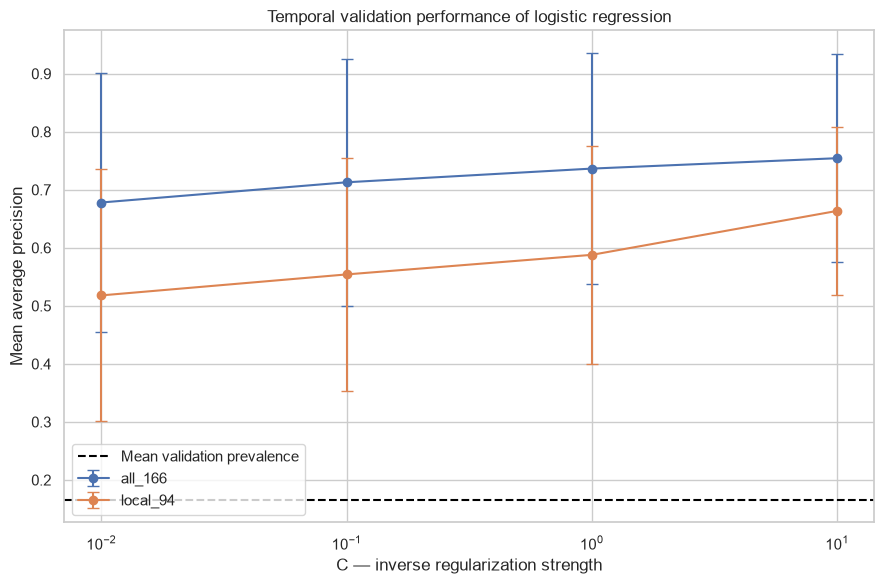

In [52]:
# Plot the tuning results
fig, ax = plt.subplots(figsize=(9, 6))

for feature_set, results in logistic_summary_df.groupby(
    "feature_set"
):
    results = results.sort_values("C")

    ax.errorbar(
        results["C"],
        results["mean_average_precision"],
        yerr=results["std_average_precision"],
        marker="o",
        capsize=4,
        label=feature_set,
    )

mean_no_skill_average_precision = (
    fold_summary_df["validation_illicit_rate"].mean()
)

ax.axhline(
    mean_no_skill_average_precision,
    color="black",
    linestyle="--",
    label="Mean validation prevalence",
)

ax.set_xscale("log")

ax.set(
    title="Temporal validation performance of logistic regression",
    xlabel="C — inverse regularization strength",
    ylabel="Mean average precision",
)

ax.legend()

plt.tight_layout()
plt.show()

In [53]:
# Refit the two selected logistic candidates
# Fit one selected model per feature variant using all training steps 1–25.

logistic_candidates = {}

for candidate_config in (
    best_logistic_by_feature_df
    .to_dict(orient="records")
):
    feature_set = candidate_config["feature_set"]
    best_c = float(candidate_config["C"])

    X_training, y_training = get_xy(
        partition="training",
        feature_set=feature_set,
    )

    final_candidate = build_logistic_pipeline(
        regularization_c=best_c,
    )

    # This is the only full-training fit. Calibration, threshold-validation,
    # and test rows remain completely unseen.
    final_candidate.fit(
        X_training,
        y_training,
    )

    logistic_candidates[feature_set] = {
        "estimator": final_candidate,
        "feature_set": feature_set,
        "C": best_c,
        "cv_average_precision": float(
            candidate_config["mean_average_precision"]
        ),
        "cv_average_precision_std": float(
            candidate_config["std_average_precision"]
        ),
    }

print("Fitted logistic candidates:")

for feature_set, candidate in logistic_candidates.items():
    print(
        f"- {feature_set}: "
        f"C={candidate['C']}, "
        f"CV AP={candidate['cv_average_precision']:.4f}"
    )

Fitted logistic candidates:
- local_94: C=10.0, CV AP=0.6636
- all_166: C=10.0, CV AP=0.7544


## 6. Class-weighted tree models

Random forest and histogram gradient boosting are evaluated with the same
expanding-window temporal folds used for logistic regression.

Average precision is the primary selection metric. PR-AUC, illicit precision,
recall, and F0.5 are also reported. Metrics at threshold 0.50 remain provisional
until probability calibration and threshold selection.

In [54]:
from time import perf_counter

from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)

In [55]:
# -1 allows random forest to use all available CPU cores.
# Change this to 1 or 2 if the computer becomes unresponsive.
TREE_N_JOBS = -1

In [56]:
# Define a bounded random-forest search
# Instead of trying hundreds of combinations,
# explicitly testing 4 carefully chosen Random Forest models.
RANDOM_FOREST_CONFIGS = [
    {
        "name": "rf_deep_leaf_1",
        "max_depth": None,
        "min_samples_leaf": 1,
        "max_features": "sqrt",
    },
    {
        "name": "rf_deep_leaf_5",
        "max_depth": None,
        "min_samples_leaf": 5,
        "max_features": "sqrt",
    },
    {
        "name": "rf_depth_20_leaf_2",
        "max_depth": 20,
        "min_samples_leaf": 2,
        "max_features": "sqrt",
    },
    {
        "name": "rf_depth_12_leaf_5",
        "max_depth": 12,
        "min_samples_leaf": 5,
        "max_features": "sqrt",
    },
]

In [57]:
# Create the estimator builder:
# The configurations test two main controls:
# - max_depth limits tree complexity.
# - min_samples_leaf prevents leaves from depending on very few transactions.

def build_random_forest(
    config: dict,
) -> RandomForestClassifier:
    """
    Build a fresh class-weighted random forest.

    balanced_subsample recalculates class weights for each bootstrap sample.
    This helps the minority illicit class without synthesizing transactions.
    """

    return RandomForestClassifier(
        n_estimators=300,
        max_depth=config["max_depth"],
        min_samples_leaf=config["min_samples_leaf"],
        max_features=config["max_features"],
        class_weight="balanced_subsample",
        bootstrap=True,
        n_jobs=TREE_N_JOBS,
        random_state=RANDOM_SEED,
    )

In [58]:
# Define the histogram-gradient-boosting search
HISTOGRAM_BOOSTING_CONFIGS = [
    {
        "name": "hgb_15_leaves",
        "learning_rate": 0.05,
        "max_iter": 250,
        "max_leaf_nodes": 15,
        "min_samples_leaf": 20,
        "l2_regularization": 1.0,
    },
    {
        "name": "hgb_31_leaves",
        "learning_rate": 0.05,
        "max_iter": 250,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 20,
        "l2_regularization": 1.0,
    },
    {
        "name": "hgb_regularized",
        "learning_rate": 0.05,
        "max_iter": 300,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 50,
        "l2_regularization": 5.0,
    },
    {
        "name": "hgb_faster_learning",
        "learning_rate": 0.10,
        "max_iter": 150,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 20,
        "l2_regularization": 1.0,
    },
]

In [59]:
# Create its builder:
def build_histogram_boosting(
    config: dict,
) -> HistGradientBoostingClassifier:
    """
    Build a fresh class-weighted histogram gradient-boosting model.

    Early stopping is disabled because scikit-learn would otherwise create an
    internal random validation sample. Model complexity is controlled explicitly
    through max_iter, tree size, leaf size, and L2 regularization.
    """

    return HistGradientBoostingClassifier(
        learning_rate=config["learning_rate"],
        max_iter=config["max_iter"],
        max_leaf_nodes=config["max_leaf_nodes"],
        min_samples_leaf=config["min_samples_leaf"],
        l2_regularization=config["l2_regularization"],
        class_weight="balanced",
        early_stopping=False,
        random_state=RANDOM_SEED,
    )

In [60]:
# safe positive-class score helper
def get_positive_class_scores(
    fitted_pipeline: Pipeline,
    X: pd.DataFrame,
) -> np.ndarray:
    """
    Return probabilities for target class 1, representing illicit activity.

    The class-column position is discovered from the fitted estimator instead
    of assuming that class 1 is always the second probability column.
    """

    fitted_model = fitted_pipeline.named_steps["model"]

    require(
        hasattr(fitted_model, "classes_"),
        "the model has not been fitted",
    )

    matching_columns = np.flatnonzero(
        fitted_model.classes_ == 1
    )

    require(
        len(matching_columns) == 1,
        "the fitted model does not contain exactly one illicit class",
    )

    return fitted_pipeline.predict_proba(X)[
        :,
        int(matching_columns[0]),
    ]

In [61]:
# Create one reusable temporal-search function
def evaluate_tree_family(
    model_family: str,
    configs: list[dict],
    estimator_builder,
) -> pd.DataFrame:
    """
    Evaluate one tree-model family across feature sets and temporal folds.

    Every loop creates a completely new preprocessing and model pipeline.
    Consequently, preprocessing statistics and model parameters are learned
    only from the historical training portion of the current fold.
    """

    result_rows = []

    for feature_set, feature_columns in FEATURE_SETS.items():
        feature_columns = list(feature_columns)

        for config in configs:
            for fold in TEMPORAL_CV_FOLDS:
                train_mask = training_frame["time_step"].isin(
                    fold["train_steps"]
                )

                validation_mask = training_frame["time_step"].isin(
                    fold["validation_steps"]
                )

                X_fold_train = training_frame.loc[
                    train_mask,
                    feature_columns,
                ]
                y_fold_train = training_frame.loc[
                    train_mask,
                    "target",
                ]

                X_fold_validation = training_frame.loc[
                    validation_mask,
                    feature_columns,
                ]
                y_fold_validation = training_frame.loc[
                    validation_mask,
                    "target",
                ]

                print(
                    f"{model_family:28s} | "
                    f"{feature_set:8s} | "
                    f"{config['name']:24s} | "
                    f"{fold['name']}"
                )

                # The imputer is kept inside the pipeline so it can learn
                # medians only from this fold's training transactions.
                candidate_pipeline = Pipeline([
                    (
                        "preprocess",
                        make_preprocessor("tree"),
                    ),
                    (
                        "model",
                        estimator_builder(config),
                    ),
                ])

                fit_start = perf_counter()

                candidate_pipeline.fit(
                    X_fold_train,
                    y_fold_train,
                )

                fit_seconds = perf_counter() - fit_start

                validation_scores = get_positive_class_scores(
                    candidate_pipeline,
                    X_fold_validation,
                )

                metrics = calculate_binary_metrics(
                    y_true=y_fold_validation,
                    y_score=validation_scores,
                )

                result_rows.append({
                    "model_family": model_family,
                    "feature_set": feature_set,
                    "config_name": config["name"],
                    "fold": fold["name"],
                    "training_rows": len(X_fold_train),
                    "validation_rows": len(X_fold_validation),
                    "fit_seconds": fit_seconds,
                    **metrics,
                })

    return pd.DataFrame(result_rows)

# This function only reads training_frame, which contains steps 1–25.

In [62]:
# Tune the random forest
random_forest_cv_results_df = evaluate_tree_family(
    model_family="random_forest",
    configs=RANDOM_FOREST_CONFIGS,
    estimator_builder=build_random_forest,
)

print(
    "Completed "
    f"{len(random_forest_cv_results_df)} "
    "random-forest evaluations."
)

display(random_forest_cv_results_df.head())

random_forest                | local_94 | rf_deep_leaf_1           | fold_1
random_forest                | local_94 | rf_deep_leaf_1           | fold_2
random_forest                | local_94 | rf_deep_leaf_1           | fold_3
random_forest                | local_94 | rf_deep_leaf_5           | fold_1
random_forest                | local_94 | rf_deep_leaf_5           | fold_2
random_forest                | local_94 | rf_deep_leaf_5           | fold_3
random_forest                | local_94 | rf_depth_20_leaf_2       | fold_1
random_forest                | local_94 | rf_depth_20_leaf_2       | fold_2
random_forest                | local_94 | rf_depth_20_leaf_2       | fold_3
random_forest                | local_94 | rf_depth_12_leaf_5       | fold_1
random_forest                | local_94 | rf_depth_12_leaf_5       | fold_2
random_forest                | local_94 | rf_depth_12_leaf_5       | fold_3
random_forest                | all_166  | rf_deep_leaf_1           | fold_1
random_fores

,model_family,feature_set,config_name,fold,training_rows,validation_rows,fit_seconds,average_precision,roc_auc,pr_auc,precision_at_0_5,recall_at_0_5,f0_5_at_0_5,accuracy_at_0_5,balanced_accuracy_at_0_5
0,random_forest,local_94,rf_deep_leaf_1,fold_1,12468,3046,1.788788,0.995224,0.998190,0.995355,0.998258,0.912420,0.979822,0.981615,0.956003
1,random_forest,local_94,rf_deep_leaf_1,fold_2,15514,3375,2.197138,0.972731,0.988394,0.973825,0.996825,0.507270,0.835551,0.909333,0.753453
2,random_forest,local_94,rf_deep_leaf_1,fold_3,18889,5311,2.643402,0.827481,0.884943,0.833364,0.979950,0.690813,0.904255,0.965543,0.844563
3,random_forest,local_94,rf_deep_leaf_5,fold_1,12468,3046,1.642249,0.994498,0.997575,0.994495,0.983766,0.964968,0.979948,0.989494,0.980416
4,random_forest,local_94,rf_deep_leaf_5,fold_2,15514,3375,2.138252,0.969100,0.989491,0.969078,0.974468,0.739903,0.916367,0.948741,0.867774


In [63]:
# Tune histogram gradient boosting
histogram_boosting_cv_results_df = evaluate_tree_family(
    model_family="histogram_gradient_boosting",
    configs=HISTOGRAM_BOOSTING_CONFIGS,
    estimator_builder=build_histogram_boosting,
)

print(
    "Completed "
    f"{len(histogram_boosting_cv_results_df)} "
    "histogram-boosting evaluations."
)

display(histogram_boosting_cv_results_df.head())

histogram_gradient_boosting  | local_94 | hgb_15_leaves            | fold_1
histogram_gradient_boosting  | local_94 | hgb_15_leaves            | fold_2
histogram_gradient_boosting  | local_94 | hgb_15_leaves            | fold_3
histogram_gradient_boosting  | local_94 | hgb_31_leaves            | fold_1
histogram_gradient_boosting  | local_94 | hgb_31_leaves            | fold_2
histogram_gradient_boosting  | local_94 | hgb_31_leaves            | fold_3
histogram_gradient_boosting  | local_94 | hgb_regularized          | fold_1
histogram_gradient_boosting  | local_94 | hgb_regularized          | fold_2
histogram_gradient_boosting  | local_94 | hgb_regularized          | fold_3
histogram_gradient_boosting  | local_94 | hgb_faster_learning      | fold_1
histogram_gradient_boosting  | local_94 | hgb_faster_learning      | fold_2
histogram_gradient_boosting  | local_94 | hgb_faster_learning      | fold_3
histogram_gradient_boosting  | all_166  | hgb_15_leaves            | fold_1
histogram_gr

,model_family,feature_set,config_name,fold,training_rows,validation_rows,fit_seconds,average_precision,roc_auc,pr_auc,precision_at_0_5,recall_at_0_5,f0_5_at_0_5,accuracy_at_0_5,balanced_accuracy_at_0_5
0,histogram_gradient_boosting,local_94,hgb_15_leaves,fold_1,12468,3046,23.765105,0.995893,0.997895,0.995891,0.980892,0.980892,0.980892,0.992121,0.987964
1,histogram_gradient_boosting,local_94,hgb_15_leaves,fold_2,15514,3375,22.243405,0.947042,0.985859,0.946998,0.939110,0.647819,0.861624,0.927704,0.819193
2,histogram_gradient_boosting,local_94,hgb_15_leaves,fold_3,18889,5311,23.314969,0.852207,0.923328,0.852158,0.829044,0.796820,0.822392,0.960836,0.888610
3,histogram_gradient_boosting,local_94,hgb_31_leaves,fold_1,12468,3046,19.727362,0.995211,0.997301,0.995209,0.977707,0.977707,0.977707,0.990808,0.985959
4,histogram_gradient_boosting,local_94,hgb_31_leaves,fold_2,15514,3375,14.738451,0.970428,0.990200,0.970408,0.986301,0.814216,0.946301,0.963852,0.905838


In [64]:
# Validate both searches:
require(
    len(random_forest_cv_results_df) == 24,
    "random-forest search did not produce 24 results",
)

require(
    len(histogram_boosting_cv_results_df) == 24,
    "histogram-boosting search did not produce 24 results",
)

In [65]:
# Summarize each configuration
tree_cv_results_df = pd.concat(
    [
        random_forest_cv_results_df,
        histogram_boosting_cv_results_df,
    ],
    ignore_index=True,
)

tree_summary_df = (
    tree_cv_results_df
    .groupby(
        [
            "model_family",
            "feature_set",
            "config_name",
        ],
        as_index=False,
    )
    .agg(
        mean_average_precision=(
            "average_precision",
            "mean",
        ),
        std_average_precision=(
            "average_precision",
            "std",
        ),
        mean_pr_auc=(
            "pr_auc",
            "mean",
        ),
        mean_roc_auc=(
            "roc_auc",
            "mean",
        ),
        mean_precision_at_0_5=(
            "precision_at_0_5",
            "mean",
        ),
        mean_recall_at_0_5=(
            "recall_at_0_5",
            "mean",
        ),
        mean_f0_5_at_0_5=(
            "f0_5_at_0_5",
            "mean",
        ),
        mean_balanced_accuracy_at_0_5=(
            "balanced_accuracy_at_0_5",
            "mean",
        ),
        mean_fit_seconds=(
            "fit_seconds",
            "mean",
        ),
    )
)

display(
    tree_summary_df
    .sort_values(
        "mean_average_precision",
        ascending=False,
    )
    .round(4)
)

,model_family,feature_set,config_name,mean_average_precision,std_average_precision,mean_pr_auc,mean_roc_auc,mean_precision_at_0_5,mean_recall_at_0_5,mean_f0_5_at_0_5,mean_balanced_accuracy_at_0_5,mean_fit_seconds
0,histogram_gradient_boosting,all_166,hgb_15_leaves,0.9463,0.0684,0.9463,0.9782,0.9340,0.8808,0.9225,0.9358,41.9608
1,histogram_gradient_boosting,all_166,hgb_31_leaves,0.9440,0.0741,0.9440,0.9723,0.9501,0.8747,0.9334,0.9339,39.1327
6,histogram_gradient_boosting,local_94,hgb_faster_learning,0.9422,0.0716,0.9422,0.9767,0.9511,0.8572,0.9297,0.9253,23.6050
2,histogram_gradient_boosting,all_166,hgb_faster_learning,0.9421,0.0764,0.9421,0.9639,0.9523,0.8769,0.9357,0.9351,38.1190
7,histogram_gradient_boosting,local_94,hgb_regularized,0.9421,0.0721,0.9420,0.9750,0.9371,0.8709,0.9224,0.9309,21.4896
3,histogram_gradient_boosting,all_166,hgb_regularized,0.9413,0.0752,0.9413,0.9697,0.9360,0.8539,0.9169,0.9227,40.0728
5,histogram_gradient_boosting,local_94,hgb_31_leaves,0.9398,0.0755,0.9398,0.9724,0.9458,0.8570,0.9256,0.9249,24.2965
8,random_forest,all_166,rf_deep_leaf_1,0.9365,0.0857,0.9374,0.9551,0.9950,0.6882,0.9019,0.8439,6.5785
11,random_forest,all_166,rf_depth_20_leaf_2,0.9359,0.0869,0.9358,0.9517,0.9920,0.7263,0.9154,0.8628,5.9294
9,random_forest,all_166,rf_deep_leaf_5,0.9357,0.0873,0.9356,0.9554,0.9722,0.8217,0.9360,0.9091,5.4072


In [66]:
# Select one configuration per tree family
# This selects the feature set as part of the configuration. The random forest and boosting model may choose different feature variants.

selected_tree_rows = []

for model_family in [
    "random_forest",
    "histogram_gradient_boosting",
]:
    family_results = tree_summary_df.loc[
        tree_summary_df["model_family"] ==
        model_family
    ]

    # Selection order:
    # 1. Average precision measures minority-class ranking quality.
    # 2. PR-AUC provides a second precision-recall summary.
    # 3. F0.5 favors precision at the provisional 0.50 threshold.
    # 4. Lower AP variability favors temporal stability.
    selected_row = (
        family_results
        .sort_values(
            by=[
                "mean_average_precision",
                "mean_pr_auc",
                "mean_f0_5_at_0_5",
                "std_average_precision",
                "config_name",
            ],
            ascending=[
                False,
                False,
                False,
                True,
                True,
            ],
        )
        .iloc[0]
    )

    selected_tree_rows.append(
        selected_row.to_dict()
    )

selected_tree_configurations_df = pd.DataFrame(
    selected_tree_rows
)

display(
    selected_tree_configurations_df.round(4)
)

,model_family,feature_set,config_name,mean_average_precision,std_average_precision,mean_pr_auc,mean_roc_auc,mean_precision_at_0_5,mean_recall_at_0_5,mean_f0_5_at_0_5,mean_balanced_accuracy_at_0_5,mean_fit_seconds
0,random_forest,all_166,rf_deep_leaf_1,0.9365,0.0857,0.9374,0.9551,0.995,0.6882,0.9019,0.8439,6.5785
1,histogram_gradient_boosting,all_166,hgb_15_leaves,0.9463,0.0684,0.9463,0.9782,0.934,0.8808,0.9225,0.9358,41.9608


In [67]:
# Refit the two selected candidates
# Create configuration lookups:
RANDOM_FOREST_CONFIG_BY_NAME = {
    config["name"]: config
    for config in RANDOM_FOREST_CONFIGS
}

HISTOGRAM_BOOSTING_CONFIG_BY_NAME = {
    config["name"]: config
    for config in HISTOGRAM_BOOSTING_CONFIGS
}

TREE_BUILDERS = {
    "random_forest": build_random_forest,
    "histogram_gradient_boosting": build_histogram_boosting,
}

TREE_CONFIG_LOOKUPS = {
    "random_forest": RANDOM_FOREST_CONFIG_BY_NAME,
    "histogram_gradient_boosting":
        HISTOGRAM_BOOSTING_CONFIG_BY_NAME,
}

In [68]:
# Fit on all training steps 1–25:
tree_candidates = {}

for selected_config in (
    selected_tree_configurations_df
    .to_dict(orient="records")
):
    model_family = selected_config["model_family"]
    feature_set = selected_config["feature_set"]
    config_name = selected_config["config_name"]

    config = TREE_CONFIG_LOOKUPS[
        model_family
    ][config_name]

    X_training, y_training = get_xy(
        partition="training",
        feature_set=feature_set,
    )

    final_pipeline = Pipeline([
        (
            "preprocess",
            make_preprocessor("tree"),
        ),
        (
            "model",
            TREE_BUILDERS[model_family](config),
        ),
    ])

    # Only the original training partition is used here.
    # Calibration and threshold-validation will be accessed in Step 7.
    final_pipeline.fit(
        X_training,
        y_training,
    )

    tree_candidates[model_family] = {
        "estimator": final_pipeline,
        "model_family": model_family,
        "feature_set": feature_set,
        "config_name": config_name,
        "parameters": config.copy(),
        "cv_average_precision": float(
            selected_config["mean_average_precision"]
        ),
        "cv_average_precision_std": float(
            selected_config["std_average_precision"]
        ),
        "cv_pr_auc": float(
            selected_config["mean_pr_auc"]
        ),
    }

print("Fitted tree candidates:")

for model_family, candidate in tree_candidates.items():
    print(
        f"- {model_family}: "
        f"{candidate['config_name']}, "
        f"features={candidate['feature_set']}, "
        f"CV AP={candidate['cv_average_precision']:.4f}"
    )

Fitted tree candidates:
- random_forest: rf_deep_leaf_1, features=all_166, CV AP=0.9365
- histogram_gradient_boosting: hgb_15_leaves, features=all_166, CV AP=0.9463


In [69]:
# Compare the three model families
# Choose the strongest logistic configuration for this comparison without deleting the other fitted logistic candidate.
best_logistic_overall = (
    best_logistic_by_feature_df
    .sort_values(
        by=[
            "mean_average_precision",
            "mean_pr_auc",
            "mean_f0_5_at_0_5",
        ],
        ascending=[
            False,
            False,
            False,
        ],
    )
    .iloc[0]
)

model_family_comparison_rows = [
    {
        "model_family": "logistic_regression",
        "feature_set": best_logistic_overall["feature_set"],
        "configuration": (
            f"C={best_logistic_overall['C']}"
        ),
        "mean_average_precision":
            best_logistic_overall["mean_average_precision"],
        "std_average_precision":
            best_logistic_overall["std_average_precision"],
        "mean_pr_auc":
            best_logistic_overall["mean_pr_auc"],
        "mean_precision_at_0_5":
            best_logistic_overall["mean_precision_at_0_5"],
        "mean_recall_at_0_5":
            best_logistic_overall["mean_recall_at_0_5"],
        "mean_f0_5_at_0_5":
            best_logistic_overall["mean_f0_5_at_0_5"],
    },
]

In [70]:
# Add the tree candidates:
for selected_config in (
    selected_tree_configurations_df
    .to_dict(orient="records")
):
    model_family_comparison_rows.append({
        "model_family":
            selected_config["model_family"],
        "feature_set":
            selected_config["feature_set"],
        "configuration":
            selected_config["config_name"],
        "mean_average_precision":
            selected_config["mean_average_precision"],
        "std_average_precision":
            selected_config["std_average_precision"],
        "mean_pr_auc":
            selected_config["mean_pr_auc"],
        "mean_precision_at_0_5":
            selected_config["mean_precision_at_0_5"],
        "mean_recall_at_0_5":
            selected_config["mean_recall_at_0_5"],
        "mean_f0_5_at_0_5":
            selected_config["mean_f0_5_at_0_5"],
    })

model_family_comparison_df = (
    pd.DataFrame(model_family_comparison_rows)
    .sort_values(
        "mean_average_precision",
        ascending=False,
    )
)

display(
    model_family_comparison_df.round(4)
)

,model_family,feature_set,configuration,mean_average_precision,std_average_precision,mean_pr_auc,mean_precision_at_0_5,mean_recall_at_0_5,mean_f0_5_at_0_5
2,histogram_gradient_boosting,all_166,hgb_15_leaves,0.9463,0.0684,0.9463,0.9340,0.8808,0.9225
1,random_forest,all_166,rf_deep_leaf_1,0.9365,0.0857,0.9374,0.9950,0.6882,0.9019
0,logistic_regression,all_166,C=10.0,0.7544,0.1791,0.7550,0.4904,0.9281,0.5406


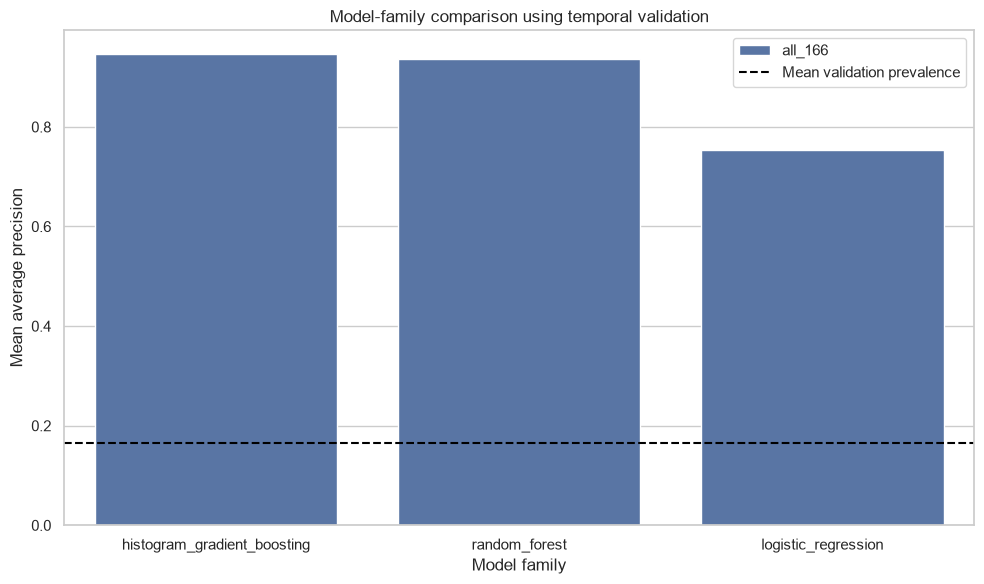

In [71]:
# Plot average precision:
fig, ax = plt.subplots(figsize=(10, 6))

comparison_plot = model_family_comparison_df.copy()

sns.barplot(
    data=comparison_plot,
    x="model_family",
    y="mean_average_precision",
    hue="feature_set",
    ax=ax,
)

ax.axhline(
    fold_summary_df["validation_illicit_rate"].mean(),
    color="black",
    linestyle="--",
    label="Mean validation prevalence",
)

ax.set(
    title="Model-family comparison using temporal validation",
    xlabel="Model family",
    ylabel="Mean average precision",
)

ax.legend()

plt.tight_layout()
plt.show()

## 7. Calibration and compliance-alert threshold

The three Step 6 model-family candidates remain fitted only on training steps 1–25. This section fits score calibrators on steps 26–30, chooses an operating threshold on steps 31–34, and leaves test steps 35–49 completely untouched. The target operating rule is at least 90% illicit precision, followed by maximum recall.

In [72]:
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss, log_loss

TARGET_ALERT_PRECISION = 0.90
CALIBRATION_METHODS = ("sigmoid", "isotonic")

# Select the strongest Step 5 logistic candidate without using calibration,
# threshold-validation, or test performance. The optional PR-AUC column is
# included only when it is present, which also makes this cell safe after a
# partial notebook rerun with an older in-memory summary table.
logistic_selection_columns = ["mean_average_precision"]
if "mean_pr_auc" in best_logistic_by_feature_df.columns:
    logistic_selection_columns.append("mean_pr_auc")
logistic_selection_columns.append("mean_f0_5_at_0_5")

step7_best_logistic = (
    best_logistic_by_feature_df
    .sort_values(
        by=logistic_selection_columns,
        ascending=[False] * len(logistic_selection_columns),
    )
    .iloc[0]
)

step7_logistic_feature_set = step7_best_logistic["feature_set"]

# Normalize the selected logistic and tree objects into one registry so the
# same calibration and threshold code is applied to every model family.
step7_candidate_registry = {
    "logistic_regression": {
        "estimator": logistic_candidates[step7_logistic_feature_set]["estimator"],
        "feature_set": step7_logistic_feature_set,
        "configuration": f"C={float(step7_best_logistic['C']):g}",
    },
}

for model_family, candidate in tree_candidates.items():
    step7_candidate_registry[model_family] = {
        "estimator": candidate["estimator"],
        "feature_set": candidate["feature_set"],
        "configuration": candidate["config_name"],
    }

require(
    set(step7_candidate_registry) == {
        "logistic_regression",
        "random_forest",
        "histogram_gradient_boosting",
    },
    "Step 7 requires exactly one fitted candidate from each model family",
)

display(pd.DataFrame([
    {
        "model_family": family,
        "feature_set": candidate["feature_set"],
        "configuration": candidate["configuration"],
    }
    for family, candidate in step7_candidate_registry.items()
]))

,model_family,feature_set,configuration
0,logistic_regression,all_166,C=10
1,random_forest,all_166,rf_deep_leaf_1
2,histogram_gradient_boosting,all_166,hgb_15_leaves


In [73]:
def fit_score_calibrator(
    method: str,
    raw_scores: np.ndarray,
    y_true: pd.Series | np.ndarray,
):
    """Fit a one-dimensional probability calibrator on steps 26–30."""

    score_array = np.asarray(raw_scores, dtype=float)
    target_array = np.asarray(y_true, dtype=np.uint8)

    require(score_array.ndim == 1, "calibration scores must be one-dimensional")
    require(len(score_array) == len(target_array), "calibration scores and labels differ in length")
    require(np.isfinite(score_array).all(), "calibration scores contain non-finite values")
    require(set(np.unique(target_array)) == {0, 1}, "calibration data must contain both classes")

    if method == "sigmoid":
        # Logistic regression learns a smooth Platt-style mapping from the
        # base model score to the observed illicit probability. No class
        # weighting is used because calibration must preserve prevalence.
        calibrator = LogisticRegression(
            solver="lbfgs",
            max_iter=1_000,
            random_state=RANDOM_SEED,
        )
        calibrator.fit(score_array.reshape(-1, 1), target_array)
        return calibrator

    if method == "isotonic":
        # Isotonic regression is more flexible but can overfit small samples.
        # out_of_bounds='clip' makes later scores outside the observed
        # calibration range map safely to the nearest fitted endpoint.
        calibrator = IsotonicRegression(
            y_min=0.0,
            y_max=1.0,
            increasing=True,
            out_of_bounds="clip",
        )
        calibrator.fit(score_array, target_array)
        return calibrator

    raise KeyError(f"Unknown calibration method: {method!r}")


def apply_score_calibrator(
    method: str,
    calibrator,
    raw_scores: np.ndarray,
) -> np.ndarray:
    """Apply a fitted calibrator and return valid illicit probabilities."""

    score_array = np.asarray(raw_scores, dtype=float)

    if method == "sigmoid":
        illicit_column = int(np.flatnonzero(calibrator.classes_ == 1)[0])
        calibrated_scores = calibrator.predict_proba(
            score_array.reshape(-1, 1)
        )[:, illicit_column]
    elif method == "isotonic":
        calibrated_scores = calibrator.predict(score_array)
    else:
        raise KeyError(f"Unknown calibration method: {method!r}")

    calibrated_scores = np.asarray(calibrated_scores, dtype=float)
    require(np.isfinite(calibrated_scores).all(), "calibrated scores contain non-finite values")
    require(
        ((calibrated_scores >= 0.0) & (calibrated_scores <= 1.0)).all(),
        "calibrated scores must lie between zero and one",
    )

    return calibrated_scores

In [74]:
def build_threshold_table(
    y_true: pd.Series | np.ndarray,
    calibrated_scores: np.ndarray,
) -> pd.DataFrame:
    """Calculate metrics at every attainable non-empty alert threshold."""

    target_array = np.asarray(y_true, dtype=np.uint8)
    score_array = np.asarray(calibrated_scores, dtype=float)

    require(len(target_array) == len(score_array), "threshold scores and labels differ in length")
    require(len(target_array) > 0, "threshold-validation data is empty")
    require(set(np.unique(target_array)) == {0, 1}, "threshold-validation data must contain both classes")

    # Sort scores from highest to lowest and calculate cumulative outcomes.
    # A valid threshold is emitted only at the end of an equal-score group;
    # this exactly matches the operational rule score >= threshold and avoids
    # pretending tied transactions can be separated from one another.
    descending_order = np.argsort(-score_array, kind="mergesort")
    sorted_scores = score_array[descending_order]
    sorted_targets = target_array[descending_order]

    group_end_indices = np.flatnonzero(
        np.r_[sorted_scores[1:] != sorted_scores[:-1], True]
    )
    cumulative_true_positives = np.cumsum(sorted_targets, dtype=np.int64)

    alert_count = group_end_indices + 1
    true_positives = cumulative_true_positives[group_end_indices]
    false_positives = alert_count - true_positives
    total_positives = int(target_array.sum())
    false_negatives = total_positives - true_positives

    precision = true_positives / alert_count
    recall = true_positives / total_positives

    beta_squared = 0.5 ** 2
    f_denominator = beta_squared * precision + recall
    f0_5 = np.divide(
        (1.0 + beta_squared) * precision * recall,
        f_denominator,
        out=np.zeros_like(precision, dtype=float),
        where=f_denominator > 0.0,
    )

    return pd.DataFrame({
        "threshold": sorted_scores[group_end_indices],
        "alert_count": alert_count.astype(int),
        "true_positives": true_positives.astype(int),
        "false_positives": false_positives.astype(int),
        "false_negatives": false_negatives.astype(int),
        "precision": precision,
        "recall": recall,
        "f0_5": f0_5,
    })


def select_operating_point(
    threshold_table: pd.DataFrame,
    precision_target: float = TARGET_ALERT_PRECISION,
) -> pd.Series:
    """Apply the compliance selection rule to one or many candidates."""

    feasible = threshold_table.loc[
        threshold_table["precision"] >= precision_target
    ]

    if not feasible.empty:
        # Once the precision constraint is met, maximize illicit recall.
        # Precision and F0.5 provide deterministic, compliance-oriented ties.
        selection_pool = feasible
        sort_columns = ["recall", "precision", "f0_5", "threshold"]
        ascending = [False, False, False, False]
        target_met = True
    else:
        # A useful fallback must catch at least one illicit transaction.
        # Select the highest attainable precision, then the largest recall,
        # and explicitly report how far precision falls below the target.
        useful = threshold_table.loc[threshold_table["true_positives"] > 0]
        require(not useful.empty, "no threshold detects an illicit transaction")
        selection_pool = useful
        sort_columns = ["precision", "recall", "f0_5", "threshold"]
        ascending = [False, False, False, False]
        target_met = False

    selected = (
        selection_pool
        .sort_values(sort_columns, ascending=ascending, kind="mergesort")
        .iloc[0]
        .copy()
    )
    selected["precision_target_met"] = target_met
    selected["precision_shortfall"] = max(
        0.0,
        precision_target - float(selected["precision"]),
    )

    return selected

In [75]:
# Fit both calibration methods using only chronological steps 26–30.
calibrated_candidate_registry = {}
calibration_quality_rows = []

for model_family, candidate in step7_candidate_registry.items():
    feature_set = candidate["feature_set"]
    X_calibration, y_calibration = get_xy(
        partition="calibration",
        feature_set=feature_set,
    )
    raw_calibration_scores = get_positive_class_scores(
        candidate["estimator"],
        X_calibration,
    )

    calibrated_candidate_registry[model_family] = {}

    for calibration_method in CALIBRATION_METHODS:
        calibrator = fit_score_calibrator(
            method=calibration_method,
            raw_scores=raw_calibration_scores,
            y_true=y_calibration,
        )
        calibrated_scores = apply_score_calibrator(
            method=calibration_method,
            calibrator=calibrator,
            raw_scores=raw_calibration_scores,
        )

        calibrated_candidate_registry[model_family][calibration_method] = {
            **candidate,
            "calibration_method": calibration_method,
            "calibrator": calibrator,
        }

        calibration_quality_rows.append({
            "model_family": model_family,
            "feature_set": feature_set,
            "configuration": candidate["configuration"],
            "calibration_method": calibration_method,
            "calibration_rows": len(y_calibration),
            "raw_brier_score": brier_score_loss(
                y_calibration, raw_calibration_scores
            ),
            "calibrated_brier_score": brier_score_loss(
                y_calibration, calibrated_scores
            ),
            "raw_log_loss": log_loss(
                y_calibration, raw_calibration_scores, labels=[0, 1]
            ),
            "calibrated_log_loss": log_loss(
                y_calibration, calibrated_scores, labels=[0, 1]
            ),
        })

calibration_quality_df = pd.DataFrame(calibration_quality_rows)
display(
    calibration_quality_df
    .sort_values(["calibrated_brier_score", "calibrated_log_loss"])
    .round(5)
)

,model_family,feature_set,configuration,calibration_method,calibration_rows,raw_brier_score,calibrated_brier_score,raw_log_loss,calibrated_log_loss
5,histogram_gradient_boosting,all_166,hgb_15_leaves,isotonic,2705,0.02255,0.01872,0.08054,0.06308
3,random_forest,all_166,rf_deep_leaf_1,isotonic,2705,0.02742,0.01962,0.11026,0.07219
4,histogram_gradient_boosting,all_166,hgb_15_leaves,sigmoid,2705,0.02255,0.02152,0.08054,0.08565
2,random_forest,all_166,rf_deep_leaf_1,sigmoid,2705,0.02742,0.02188,0.11026,0.09252
1,logistic_regression,all_166,C=10,isotonic,2705,0.14304,0.05490,0.55263,0.18401
0,logistic_regression,all_166,C=10,sigmoid,2705,0.14304,0.07480,0.55263,0.23541


In [76]:
# Evaluate every candidate/calibrator pair only on steps 31–34.
threshold_search_tables = []
threshold_validation_quality_rows = []

for model_family, methods in calibrated_candidate_registry.items():
    for calibration_method, candidate in methods.items():
        X_threshold, y_threshold = get_xy(
            partition="threshold_validation",
            feature_set=candidate["feature_set"],
        )
        raw_threshold_scores = get_positive_class_scores(
            candidate["estimator"],
            X_threshold,
        )
        calibrated_threshold_scores = apply_score_calibrator(
            method=calibration_method,
            calibrator=candidate["calibrator"],
            raw_scores=raw_threshold_scores,
        )

        candidate_thresholds = build_threshold_table(
            y_true=y_threshold,
            calibrated_scores=calibrated_threshold_scores,
        )
        candidate_thresholds.insert(0, "calibration_method", calibration_method)
        candidate_thresholds.insert(0, "configuration", candidate["configuration"])
        candidate_thresholds.insert(0, "feature_set", candidate["feature_set"])
        candidate_thresholds.insert(0, "model_family", model_family)
        candidate_thresholds["threshold_validation_rows"] = len(y_threshold)
        threshold_search_tables.append(candidate_thresholds)

        ranking_metrics = calculate_binary_metrics(
            y_true=y_threshold,
            y_score=calibrated_threshold_scores,
        )
        threshold_validation_quality_rows.append({
            "model_family": model_family,
            "feature_set": candidate["feature_set"],
            "configuration": candidate["configuration"],
            "calibration_method": calibration_method,
            "average_precision": ranking_metrics["average_precision"],
            "pr_auc": ranking_metrics["pr_auc"],
            "brier_score": brier_score_loss(
                y_threshold, calibrated_threshold_scores
            ),
        })

threshold_search_df = pd.concat(threshold_search_tables, ignore_index=True)
threshold_validation_quality_df = pd.DataFrame(
    threshold_validation_quality_rows
)

print(
    f"Evaluated {len(threshold_search_df):,} attainable operating points "
    "without accessing the test partition."
)
display(
    threshold_validation_quality_df
    .sort_values("average_precision", ascending=False)
    .round(5)
)

Evaluated 5,834 attainable operating points without accessing the test partition.


,model_family,feature_set,configuration,calibration_method,average_precision,pr_auc,brier_score
2,random_forest,all_166,rf_deep_leaf_1,sigmoid,0.99169,0.99185,0.01293
3,random_forest,all_166,rf_deep_leaf_1,isotonic,0.98745,0.99158,0.01115
4,histogram_gradient_boosting,all_166,hgb_15_leaves,sigmoid,0.97753,0.97749,0.01834
5,histogram_gradient_boosting,all_166,hgb_15_leaves,isotonic,0.97055,0.97753,0.01961
1,logistic_regression,all_166,C=10,isotonic,0.56474,0.71933,0.10747
0,logistic_regression,all_166,C=10,sigmoid,0.56004,0.56334,0.12017


In [77]:
# Summarize the best operating point for each model/calibration pair.
candidate_operating_points = []

for (model_family, calibration_method), candidate_table in (
    threshold_search_df.groupby(
        ["model_family", "calibration_method"],
        sort=True,
    )
):
    candidate_operating_points.append(
        select_operating_point(candidate_table).to_dict()
    )

candidate_operating_points_df = pd.DataFrame(candidate_operating_points)

# Apply the same rule globally. This directly selects the model, calibration
# method, and threshold that maximize recall while satisfying precision.
selected_operating_point = select_operating_point(threshold_search_df)
selected_family = selected_operating_point["model_family"]
selected_calibration_method = selected_operating_point["calibration_method"]
selected_candidate = calibrated_candidate_registry[
    selected_family
][selected_calibration_method]

# Treat this registry as frozen from this point forward. Step 8 may evaluate
# it once on test steps 35–49, but must not refit the estimator, recalibrate,
# or alter the selected threshold after viewing test results.
frozen_alert_model = {
    "estimator": selected_candidate["estimator"],
    "feature_set": selected_candidate["feature_set"],
    "model_family": selected_family,
    "configuration": selected_candidate["configuration"],
    "calibration_method": selected_calibration_method,
    "calibrator": selected_candidate["calibrator"],
    "alert_threshold": float(selected_operating_point["threshold"]),
    "precision_target": TARGET_ALERT_PRECISION,
    "precision_target_met": bool(
        selected_operating_point["precision_target_met"]
    ),
    "threshold_validation_precision": float(
        selected_operating_point["precision"]
    ),
    "threshold_validation_recall": float(
        selected_operating_point["recall"]
    ),
    "threshold_validation_f0_5": float(
        selected_operating_point["f0_5"]
    ),
    "precision_shortfall": float(
        selected_operating_point["precision_shortfall"]
    ),
}

display(
    candidate_operating_points_df.loc[:, [
        "model_family",
        "feature_set",
        "calibration_method",
        "threshold",
        "alert_count",
        "precision",
        "recall",
        "f0_5",
        "precision_target_met",
        "precision_shortfall",
    ]]
    .sort_values(["precision_target_met", "recall", "precision"], ascending=False)
    .round(5)
)

print("Frozen Step 7 alert policy:")
print(f"- model: {frozen_alert_model['model_family']}")
print(f"- features: {frozen_alert_model['feature_set']}")
print(f"- configuration: {frozen_alert_model['configuration']}")
print(f"- calibration: {frozen_alert_model['calibration_method']}")
print(f"- threshold: {frozen_alert_model['alert_threshold']:.8f}")
print(f"- validation precision: {frozen_alert_model['threshold_validation_precision']:.4f}")
print(f"- validation recall: {frozen_alert_model['threshold_validation_recall']:.4f}")
if not frozen_alert_model["precision_target_met"]:
    print(
        "- WARNING: 90% precision was infeasible; "
        f"shortfall={frozen_alert_model['precision_shortfall']:.4f}"
    )

,model_family,feature_set,calibration_method,threshold,alert_count,precision,recall,f0_5,precision_target_met,precision_shortfall
5,random_forest,all_166,sigmoid,0.09870,545,0.91376,0.98031,0.92634,True,0.00000
4,random_forest,all_166,isotonic,0.14286,530,0.93774,0.97835,0.94559,True,0.00000
1,histogram_gradient_boosting,all_166,sigmoid,0.39167,528,0.91098,0.94685,0.91794,True,0.00000
0,histogram_gradient_boosting,all_166,isotonic,0.40000,516,0.92442,0.93898,0.92729,True,0.00000
2,logistic_regression,all_166,isotonic,0.86695,625,0.59040,0.72638,0.61336,False,0.30960
3,logistic_regression,all_166,sigmoid,0.69671,296,0.67905,0.39567,0.59397,False,0.22095


Frozen Step 7 alert policy:
- model: random_forest
- features: all_166
- configuration: rf_deep_leaf_1
- calibration: sigmoid
- threshold: 0.09869865
- validation precision: 0.9138
- validation recall: 0.9803


In [78]:
# Final leakage and artifact checks. No test features or labels are read here.
require(
    partition_frames["training"]["time_step"].max()
    < partition_frames["calibration"]["time_step"].min(),
    "training and calibration partitions overlap",
)
require(
    partition_frames["calibration"]["time_step"].max()
    < partition_frames["threshold_validation"]["time_step"].min(),
    "calibration and threshold-validation partitions overlap",
)
require(
    partition_frames["threshold_validation"]["time_step"].max()
    < partition_frames["test"]["time_step"].min(),
    "threshold-validation and test partitions overlap",
)
require(
    0.0 <= frozen_alert_model["alert_threshold"] <= 1.0,
    "the frozen alert threshold is not a probability",
)
require(
    len(calibration_quality_df)
    == len(step7_candidate_registry) * len(CALIBRATION_METHODS),
    "not every candidate/calibration pair was evaluated",
)

def score_with_frozen_alert_model(frame: pd.DataFrame) -> pd.DataFrame:
    """Score a supplied frame without fitting or changing the alert policy."""

    feature_columns = list(FEATURE_SETS[frozen_alert_model["feature_set"]])
    require(
        set(feature_columns).issubset(frame.columns),
        "the supplied frame is missing frozen-model features",
    )
    raw_scores = get_positive_class_scores(
        frozen_alert_model["estimator"],
        frame.loc[:, feature_columns],
    )
    calibrated_scores = apply_score_calibrator(
        method=frozen_alert_model["calibration_method"],
        calibrator=frozen_alert_model["calibrator"],
        raw_scores=raw_scores,
    )

    result = pd.DataFrame(
        {
            "calibrated_illicit_probability": calibrated_scores,
            "alert": calibrated_scores >= frozen_alert_model["alert_threshold"],
        },
        index=frame.index,
    )
    if "transaction_id" in frame.columns:
        result.insert(0, "transaction_id", frame["transaction_id"].to_numpy())

    return result

print("Step 7 validation passed. The test partition remains untouched.")

Step 7 validation passed. The test partition remains untouched.


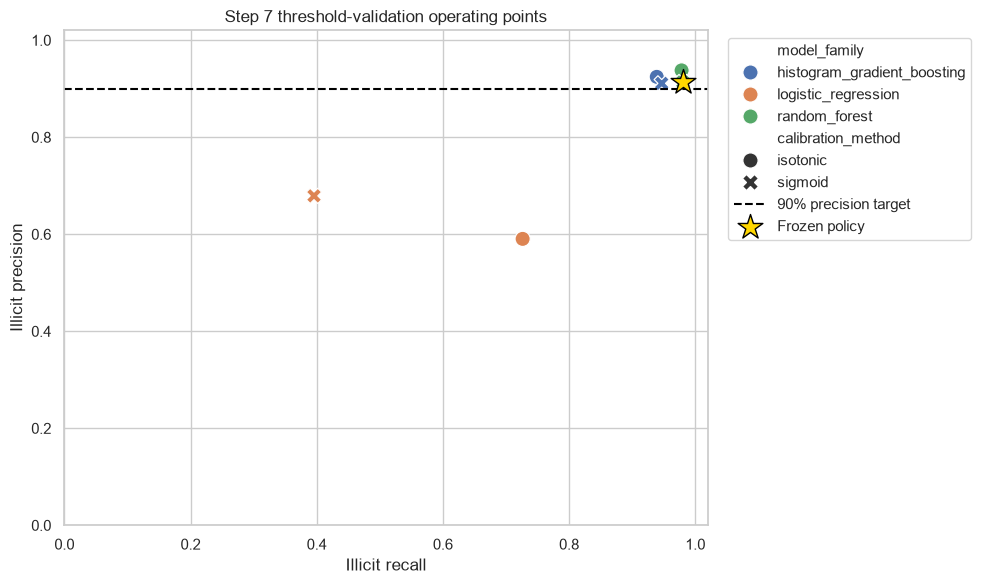

In [79]:
# Visualize the selected operating point for every candidate/calibrator pair.
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=candidate_operating_points_df,
    x="recall",
    y="precision",
    hue="model_family",
    style="calibration_method",
    s=120,
    ax=ax,
)
ax.axhline(
    TARGET_ALERT_PRECISION,
    color="black",
    linestyle="--",
    label="90% precision target",
)
ax.scatter(
    [selected_operating_point["recall"]],
    [selected_operating_point["precision"]],
    marker="*",
    s=350,
    color="gold",
    edgecolor="black",
    label="Frozen policy",
    zorder=5,
)
ax.set(
    title="Step 7 threshold-validation operating points",
    xlabel="Illicit recall",
    ylabel="Illicit precision",
    xlim=(0.0, 1.02),
    ylim=(0.0, 1.02),
)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 8. Final test evaluation

Run the frozen Step 7 system once on test steps 35–49. Every result below reuses the single saved prediction table; the model, calibration method, feature set, and threshold must not be changed after viewing test performance. Review-efficiency lift is alert precision divided by test prevalence, while workload reduction is `1 - alert_rate`.

,model_family,feature_set,configuration,calibration_method,alert_threshold,rows,licit_count,illicit_count,alert_count,true_negatives,...,precision,recall,f0_5,average_precision,pr_auc,roc_auc,alert_rate,workload_reduction,review_efficiency_lift,reviews_per_detected_illicit
0,random_forest,all_166,rf_deep_leaf_1,sigmoid,0.0987,16670,15587,1083,1412,14974,...,0.56586,0.73777,0.59352,0.77813,0.77941,0.90272,0.0847,0.9153,8.71002,1.76721


,predicted_no_alert,predicted_alert
actual_licit,14974,613
actual_illicit,284,799


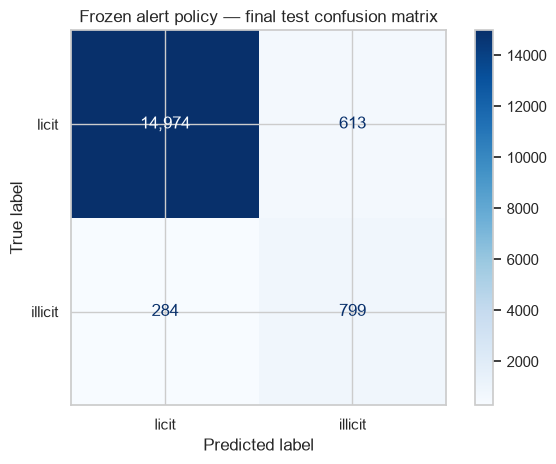

In [80]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

def calculate_final_test_metrics(scored_frame: pd.DataFrame) -> dict[str, float]:
    """Calculate frozen-policy ranking, alert, and review metrics."""

    y_true = scored_frame["target"].to_numpy(dtype=np.uint8)
    y_score = scored_frame["calibrated_illicit_probability"].to_numpy(dtype=float)
    y_alert = scored_frame["alert"].to_numpy(dtype=np.uint8)
    tn, fp, fn, tp = confusion_matrix(y_true, y_alert, labels=[0, 1]).ravel()
    precision = precision_score(y_true, y_alert, zero_division=0)
    recall = recall_score(y_true, y_alert, zero_division=0)
    f0_5 = fbeta_score(y_true, y_alert, beta=0.5, zero_division=0)
    prevalence = float(y_true.mean())
    alert_rate = float(y_alert.mean())

    if len(np.unique(y_true)) == 2:
        precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_score)
        pr_auc = auc(recall_curve, precision_curve)
        average_precision = average_precision_score(y_true, y_score)
        roc_auc = roc_auc_score(y_true, y_score)
    else:
        pr_auc = average_precision = roc_auc = np.nan

    return {
        "rows": int(len(y_true)),
        "licit_count": int((y_true == 0).sum()),
        "illicit_count": int((y_true == 1).sum()),
        "alert_count": int(y_alert.sum()),
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
        "prevalence": prevalence,
        "precision": precision,
        "recall": recall,
        "f0_5": f0_5,
        "average_precision": average_precision,
        "pr_auc": pr_auc,
        "roc_auc": roc_auc,
        "alert_rate": alert_rate,
        "workload_reduction": 1.0 - alert_rate,
        "review_efficiency_lift": precision / prevalence if prevalence else np.nan,
        "reviews_per_detected_illicit": (tp + fp) / tp if tp else np.inf,
    }

current_frozen_policy = {
    key: frozen_alert_model[key]
    for key in ["model_family", "feature_set", "configuration", "calibration_method", "alert_threshold"]
}
already_evaluated = globals().get("FINAL_TEST_EVALUATION_COMPLETED", False)
if already_evaluated:
    require(
        "final_test_predictions_df" in globals(),
        "completion flag is set but final_test_predictions_df is missing",
    )
    previous_policy_snapshot = globals().get(
        "FINAL_TEST_FROZEN_POLICY_SNAPSHOT",
        globals().get("frozen_policy_before_test"),
    )
    require(
        previous_policy_snapshot is not None,
        "completion flag is set but the frozen-policy snapshot is missing",
    )
    require(
        previous_policy_snapshot == current_frozen_policy,
        "the frozen policy changed after the original final-test evaluation",
    )
    frozen_policy_before_test = dict(previous_policy_snapshot)
    FINAL_TEST_FROZEN_POLICY_SNAPSHOT = frozen_policy_before_test.copy()
    print("Reusing the existing one-time final test predictions.")
else:
    frozen_policy_before_test = current_frozen_policy.copy()

final_test_frame = partition_frames["test"].copy()
require(len(final_test_frame) == 16_670, "unexpected final test row count")
require(
    set(final_test_frame["time_step"].astype(int).unique()) == set(range(35, 50)),
    "test data must contain exactly steps 35–49",
)

if not already_evaluated:
    # This is the only application of the frozen policy to final test features.
    frozen_test_scores = score_with_frozen_alert_model(final_test_frame)
    final_test_predictions_df = final_test_frame.loc[
        :, ["transaction_id", "time_step", "label", "target"]
    ].copy()
    final_test_predictions_df["calibrated_illicit_probability"] = (
        frozen_test_scores["calibrated_illicit_probability"].to_numpy()
    )
    final_test_predictions_df["alert"] = (
        frozen_test_scores["alert"].to_numpy(dtype=bool)
    )
    FINAL_TEST_FROZEN_POLICY_SNAPSHOT = frozen_policy_before_test.copy()
    FINAL_TEST_EVALUATION_COMPLETED = True

required_prediction_columns = {
    "transaction_id", "time_step", "label", "target",
    "calibrated_illicit_probability", "alert",
}
require(
    required_prediction_columns.issubset(final_test_predictions_df.columns),
    "saved final-test predictions are missing required columns",
)
require(len(final_test_predictions_df) == 16_670, "unexpected saved test row count")
require(
    set(final_test_predictions_df["time_step"].astype(int).unique()) == set(range(35, 50)),
    "saved test predictions must contain exactly steps 35-49",
)
require(final_test_predictions_df["transaction_id"].is_unique, "duplicate test IDs")

final_test_metrics = calculate_final_test_metrics(final_test_predictions_df)
final_test_summary_df = pd.DataFrame([{**frozen_policy_before_test, **final_test_metrics}])
display(final_test_summary_df.round(5))

final_confusion_matrix = np.array([
    [final_test_metrics["true_negatives"], final_test_metrics["false_positives"]],
    [final_test_metrics["false_negatives"], final_test_metrics["true_positives"]],
])
display(pd.DataFrame(
    final_confusion_matrix,
    index=["actual_licit", "actual_illicit"],
    columns=["predicted_no_alert", "predicted_alert"],
))
ConfusionMatrixDisplay(final_confusion_matrix, display_labels=["licit", "illicit"]).plot(
    cmap="Blues", values_format=",d"
)
plt.title("Frozen alert policy — final test confusion matrix")
plt.tight_layout()
plt.show()

,time_step,rows,licit_count,illicit_count,alert_count,true_negatives,false_positives,false_negatives,true_positives,prevalence,...,alert_rate,workload_reduction,review_efficiency_lift,reviews_per_detected_illicit,precision_ci_lower,precision_ci_upper,recall_ci_lower,recall_ci_upper,alert_rate_ci_lower,alert_rate_ci_upper
0,35,1341,1159,182,229,1108,51,4,178,0.1357,...,0.1708,0.8292,5.7272,1.2865,0.7191,0.8264,0.9449,0.9914,0.1516,0.1918
1,36,1708,1675,33,97,1611,64,0,33,0.0193,...,0.0568,0.9432,17.6082,2.9394,0.2536,0.4390,0.8957,1.0000,0.0468,0.0688
2,37,498,458,40,30,455,3,13,27,0.0803,...,0.0602,0.9398,11.2050,1.1111,0.7438,0.9654,0.5202,0.7992,0.0425,0.0847
3,38,756,645,111,122,624,21,10,101,0.1468,...,0.1614,0.8386,5.6385,1.2079,0.7512,0.8846,0.8421,0.9503,0.1369,0.1893
4,39,1183,1102,81,118,1060,42,5,76,0.0685,...,0.0997,0.9003,9.4066,1.5526,0.5544,0.7247,0.8635,0.9733,0.0839,0.1181
5,40,1211,1099,112,122,1054,45,35,77,0.0925,...,0.1007,0.8993,6.8243,1.5844,0.5427,0.7115,0.5966,0.7659,0.0850,0.1190
6,41,1132,1016,116,129,996,20,7,109,0.1025,...,0.1140,0.8860,8.2457,1.1835,0.7726,0.8973,0.8807,0.9705,0.0967,0.1338
7,42,2154,1915,239,254,1853,62,47,192,0.1110,...,0.1179,0.8821,6.8126,1.3229,0.6995,0.8047,0.7483,0.8488,0.1050,0.1322
8,43,1370,1346,24,28,1318,28,24,0,0.0175,...,0.0204,0.9796,0.0000,inf,0.0000,0.1206,0.0000,0.1380,0.0142,0.0294
9,44,1591,1567,24,121,1450,117,20,4,0.0151,...,0.0761,0.9239,2.1915,30.2500,0.0129,0.0819,0.0668,0.3585,0.0640,0.0901


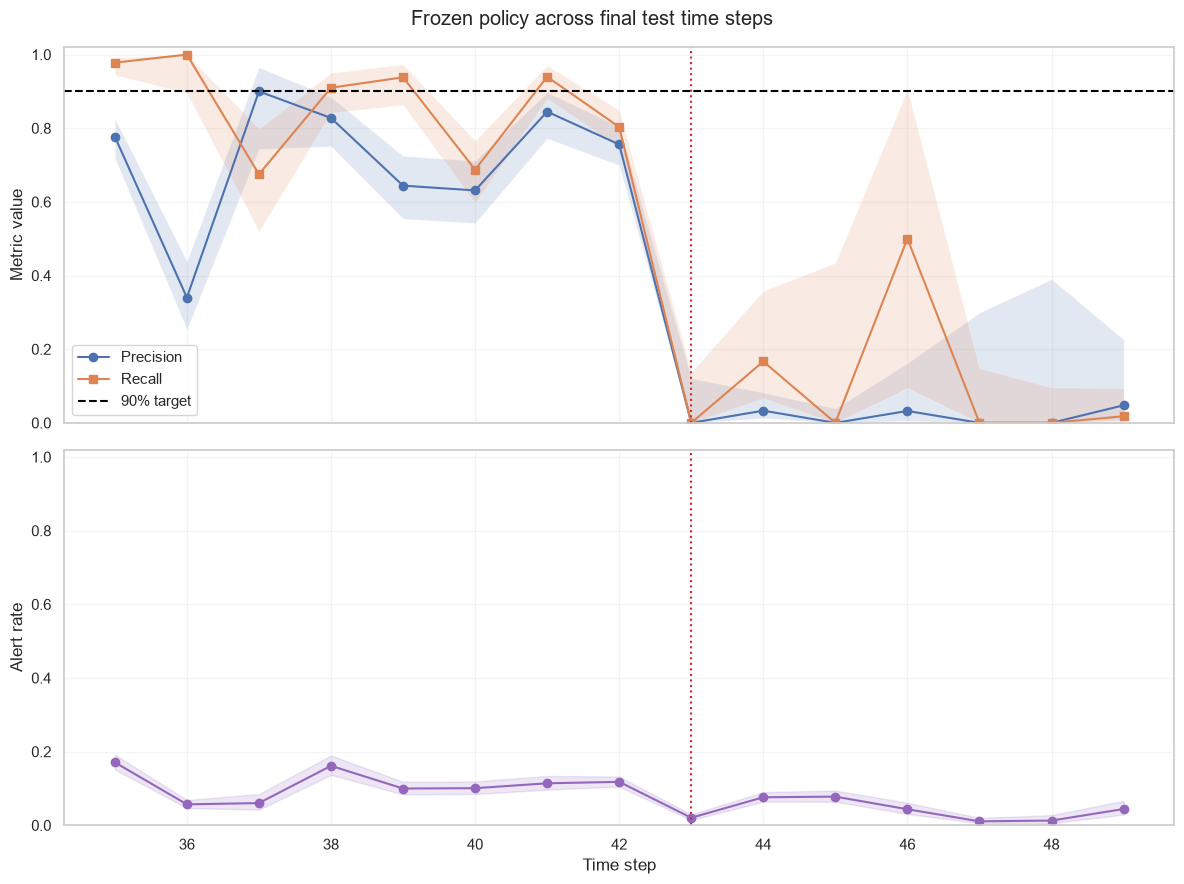

In [81]:
def wilson_interval(successes: int, trials: int) -> tuple[float, float]:
    """Return a 95% Wilson interval for a binomial proportion."""
    if trials == 0:
        return np.nan, np.nan
    z = 1.959963984540054
    proportion = successes / trials
    denominator = 1.0 + z ** 2 / trials
    center = (proportion + z ** 2 / (2.0 * trials)) / denominator
    half_width = z * np.sqrt(
        proportion * (1.0 - proportion) / trials + z ** 2 / (4.0 * trials ** 2)
    ) / denominator
    return center - half_width, center + half_width

time_step_rows = []
for time_step, step_frame in final_test_predictions_df.groupby("time_step", sort=True):
    metrics = calculate_final_test_metrics(step_frame)
    precision_ci = wilson_interval(metrics["true_positives"], metrics["alert_count"])
    recall_ci = wilson_interval(metrics["true_positives"], metrics["illicit_count"])
    alert_ci = wilson_interval(metrics["alert_count"], metrics["rows"])
    time_step_rows.append({
        "time_step": int(time_step), **metrics,
        "precision_ci_lower": precision_ci[0], "precision_ci_upper": precision_ci[1],
        "recall_ci_lower": recall_ci[0], "recall_ci_upper": recall_ci[1],
        "alert_rate_ci_lower": alert_ci[0], "alert_rate_ci_upper": alert_ci[1],
    })
final_test_by_time_step_df = pd.DataFrame(time_step_rows)
display(final_test_by_time_step_df.round(4))

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
for metric, marker in [("precision", "o"), ("recall", "s")]:
    axes[0].plot(final_test_by_time_step_df["time_step"], final_test_by_time_step_df[metric], marker=marker, label=metric.title())
    axes[0].fill_between(
        final_test_by_time_step_df["time_step"],
        final_test_by_time_step_df[f"{metric}_ci_lower"],
        final_test_by_time_step_df[f"{metric}_ci_upper"], alpha=0.16,
    )
axes[0].axhline(TARGET_ALERT_PRECISION, color="black", linestyle="--", label="90% target")
axes[0].set(ylabel="Metric value", ylim=(0, 1.02))
axes[0].legend()
axes[1].plot(final_test_by_time_step_df["time_step"], final_test_by_time_step_df["alert_rate"], marker="o", color="tab:purple")
axes[1].fill_between(
    final_test_by_time_step_df["time_step"],
    final_test_by_time_step_df["alert_rate_ci_lower"],
    final_test_by_time_step_df["alert_rate_ci_upper"], color="tab:purple", alpha=0.16,
)
axes[1].set(xlabel="Time step", ylabel="Alert rate", ylim=(0, 1.02))
for axis in axes:
    axis.axvline(43, color="tab:red", linestyle=":")
    axis.grid(alpha=0.2)
fig.suptitle("Frozen policy across final test time steps")
plt.tight_layout()
plt.show()

,period,rows,licit_count,illicit_count,alert_count,true_negatives,false_positives,false_negatives,true_positives,prevalence,precision,recall,f0_5,average_precision,pr_auc,roc_auc,alert_rate,workload_reduction,review_efficiency_lift,reviews_per_detected_illicit
0,before_43_steps_35_42,9983,9069,914,1101,8761,308,121,793,0.09156,0.72025,0.86761,0.74558,0.90538,0.90631,0.95709,0.11029,0.88971,7.86685,1.38840
1,step_43_and_after_steps_43_49,6687,6518,169,311,6213,305,163,6,0.02527,0.01929,0.03550,0.02123,0.03411,0.03280,0.60107,0.04651,0.95349,0.76337,51.83333


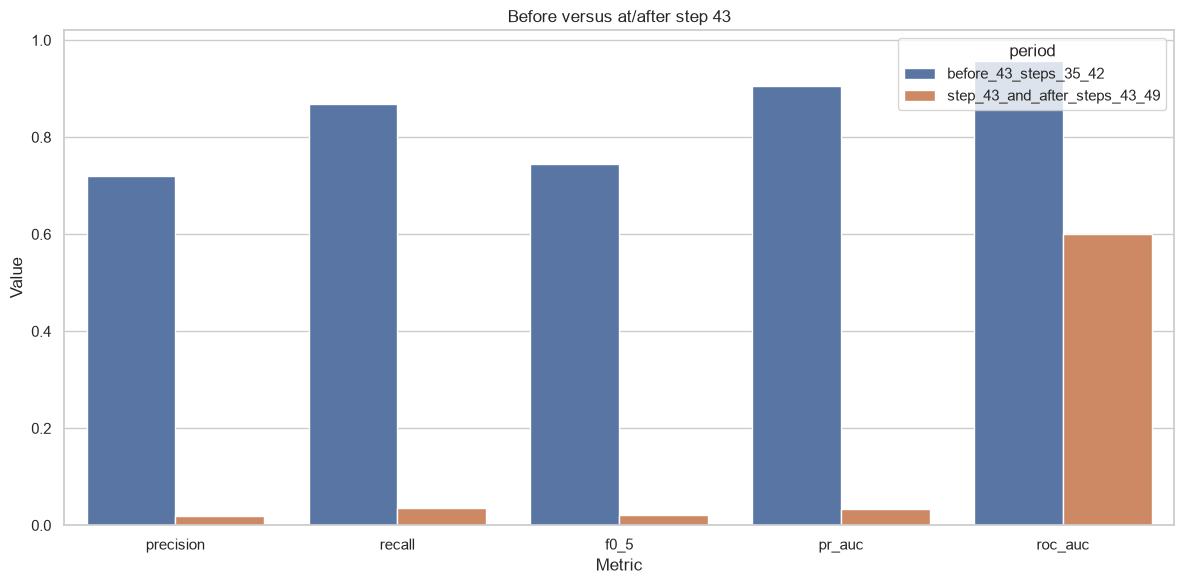

In [82]:
step43_analysis_df = final_test_predictions_df.copy()
step43_analysis_df["period"] = np.where(
    step43_analysis_df["time_step"] < 43,
    "before_43_steps_35_42",
    "step_43_and_after_steps_43_49",
)
step43_period_results_df = pd.DataFrame([
    {"period": period, **calculate_final_test_metrics(frame)}
    for period, frame in step43_analysis_df.groupby("period", sort=False)
])
display(step43_period_results_df.round(5))
step43_plot_df = step43_period_results_df.melt(
    id_vars="period",
    value_vars=["precision", "recall", "f0_5", "pr_auc", "roc_auc"],
    var_name="metric", value_name="value",
)
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=step43_plot_df, x="metric", y="value", hue="period", ax=ax)
ax.set(title="Before versus at/after step 43", xlabel="Metric", ylabel="Value", ylim=(0, 1.02))
plt.tight_layout()
plt.show()

In [83]:
# Resample whole time-step blocks to retain within-step dependence.
FINAL_TEST_BOOTSTRAP_REPLICATES = 1_000
BOOTSTRAP_METRICS = [
    "precision", "recall", "f0_5", "average_precision", "pr_auc",
    "roc_auc", "alert_rate", "workload_reduction", "review_efficiency_lift",
]
time_steps = np.sort(final_test_predictions_df["time_step"].unique())
step_positions = {
    step: np.flatnonzero(final_test_predictions_df["time_step"].to_numpy() == step)
    for step in time_steps
}
bootstrap_rng = np.random.default_rng(RANDOM_SEED + 8_000)
bootstrap_rows = []
for replicate in range(FINAL_TEST_BOOTSTRAP_REPLICATES):
    sampled_steps = bootstrap_rng.choice(time_steps, size=len(time_steps), replace=True)
    sampled_positions = np.concatenate([step_positions[step] for step in sampled_steps])
    sampled_metrics = calculate_final_test_metrics(final_test_predictions_df.iloc[sampled_positions])
    bootstrap_rows.append({
        "replicate": replicate,
        **{metric: sampled_metrics[metric] for metric in BOOTSTRAP_METRICS},
    })
final_test_bootstrap_df = pd.DataFrame(bootstrap_rows)
final_test_confidence_intervals_df = pd.DataFrame([
    {
        "metric": metric,
        "estimate": final_test_metrics[metric],
        "ci_95_lower": final_test_bootstrap_df[metric].quantile(0.025),
        "ci_95_upper": final_test_bootstrap_df[metric].quantile(0.975),
    }
    for metric in BOOTSTRAP_METRICS
])
display(final_test_confidence_intervals_df.round(5))
require(
    {key: frozen_alert_model[key] for key in frozen_policy_before_test}
    == frozen_policy_before_test,
    "the frozen policy changed during final test analysis",
)
print("Step 8 complete. Do not retune from final test results.")

,metric,estimate,ci_95_lower,ci_95_upper
0,precision,0.56586,0.35382,0.70643
1,recall,0.73777,0.52901,0.85574
2,f0_5,0.59352,0.38561,0.72706
3,average_precision,0.77813,0.56468,0.88691
4,pr_auc,0.77941,0.56560,0.88778
5,roc_auc,0.90272,0.81050,0.94941
6,alert_rate,0.08470,0.06128,0.11029
7,workload_reduction,0.91530,0.88971,0.93872
8,review_efficiency_lift,8.71002,7.11769,10.67023


Step 8 complete. Do not retune from final test results.


## 9. Explanations and analyst review queue

This section explains the frozen policy without changing it. Global permutation importance is measured on threshold-validation steps 31–34, not on the final test set. Local explanations report score sensitivity when one anonymized feature is replaced by its training-set median; they are model-agnostic perturbation impacts, not causal effects or additive SHAP values. Unknown-label scores prioritize investigation but cannot establish criminal activity.

,feature,mean_ap_decrease,std_ap_decrease,repeats
0,local_feature_053,0.005214,0.000777,3
1,local_feature_055,0.001875,0.000580,3
2,local_feature_090,0.001675,0.002525,3
3,local_feature_061,0.001585,0.000046,3
4,local_feature_077,0.001485,0.000668,3
5,local_feature_065,0.001244,0.000206,3
6,local_feature_052,0.001005,0.001530,3
7,local_feature_059,0.000764,0.000135,3
8,local_feature_081,0.000740,0.000299,3
9,local_feature_089,0.000724,0.000248,3


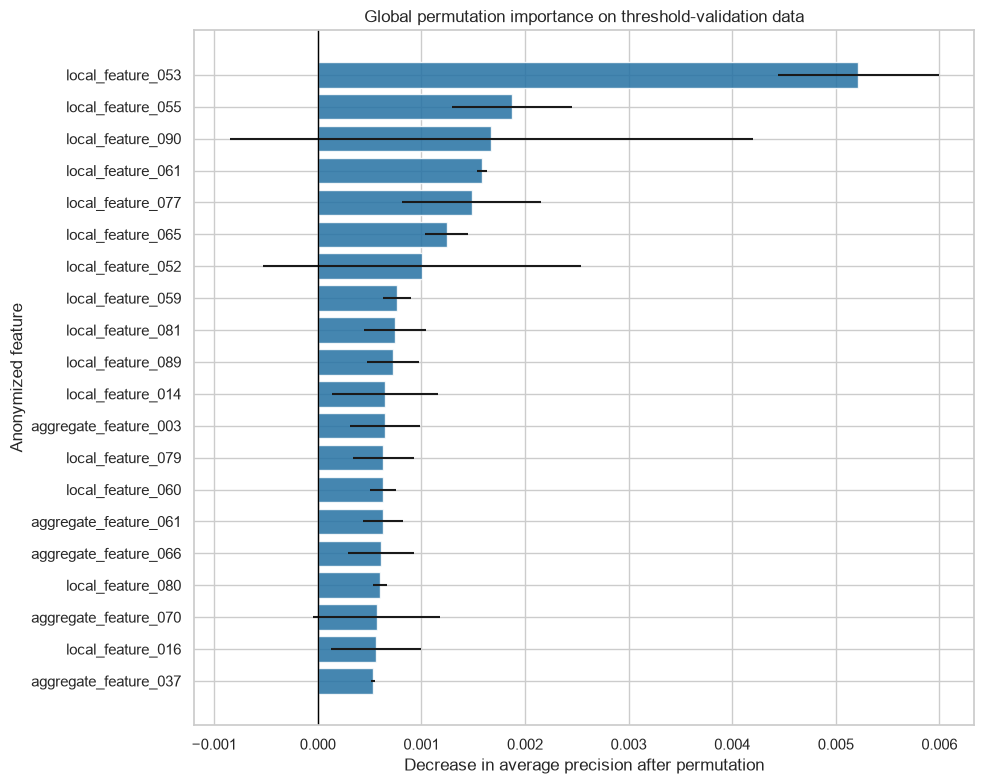

In [84]:
import networkx as nx
from matplotlib.lines import Line2D

frozen_policy_before_explanations = {
    key: frozen_alert_model[key]
    for key in ["model_family", "feature_set", "configuration", "calibration_method", "alert_threshold"]
}
EXPLANATION_FEATURES = list(FEATURE_SETS[frozen_alert_model["feature_set"]])
GLOBAL_IMPORTANCE_SAMPLE_SIZE = 1_500
GLOBAL_IMPORTANCE_REPEATS = 3

# Use a fixed sample of threshold-validation rows to keep the model-agnostic
# calculation practical and reproducible. No final-test outcome is used to
# choose, rank, or filter features.
importance_source_frame = partition_frames["threshold_validation"].loc[:, [
    *EXPLANATION_FEATURES, "target"
]].copy()
importance_sample_frame = importance_source_frame.sample(
    n=min(GLOBAL_IMPORTANCE_SAMPLE_SIZE, len(importance_source_frame)),
    random_state=RANDOM_SEED + 9_000,
)
importance_targets = importance_sample_frame["target"].to_numpy(dtype=np.uint8)
importance_baseline_scores = score_with_frozen_alert_model(
    importance_sample_frame
)["calibrated_illicit_probability"].to_numpy()
importance_baseline_ap = average_precision_score(
    importance_targets, importance_baseline_scores
)
importance_rng = np.random.default_rng(RANDOM_SEED + 9_001)
global_importance_rows = []

for feature_name in EXPLANATION_FEATURES:
    ap_decreases = []
    for repeat in range(GLOBAL_IMPORTANCE_REPEATS):
        permuted_frame = importance_sample_frame.copy()
        permuted_frame[feature_name] = importance_rng.permutation(
            permuted_frame[feature_name].to_numpy()
        )
        permuted_scores = score_with_frozen_alert_model(
            permuted_frame
        )["calibrated_illicit_probability"].to_numpy()
        permuted_ap = average_precision_score(importance_targets, permuted_scores)
        ap_decreases.append(importance_baseline_ap - permuted_ap)

    global_importance_rows.append({
        "feature": feature_name,
        "mean_ap_decrease": float(np.mean(ap_decreases)),
        "std_ap_decrease": float(np.std(ap_decreases, ddof=1)),
        "repeats": GLOBAL_IMPORTANCE_REPEATS,
    })

global_feature_importance_df = (
    pd.DataFrame(global_importance_rows)
    .sort_values("mean_ap_decrease", ascending=False, kind="mergesort")
    .reset_index(drop=True)
)
display(global_feature_importance_df.head(25).round(6))

top_global_importance = global_feature_importance_df.head(20).sort_values(
    "mean_ap_decrease"
)
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    top_global_importance["feature"],
    top_global_importance["mean_ap_decrease"],
    xerr=top_global_importance["std_ap_decrease"],
    color="#2471A3", alpha=0.85,
)
ax.axvline(0, color="black", linewidth=1)
ax.set(
    title="Global permutation importance on threshold-validation data",
    xlabel="Decrease in average precision after permutation",
    ylabel="Anonymized feature",
)
plt.tight_layout()
plt.show()

In [85]:
X_explanation_training, _ = get_xy(
    partition="training",
    feature_set=frozen_alert_model["feature_set"],
)
training_feature_medians = X_explanation_training.median(axis=0)
require(training_feature_medians.notna().all(), "training feature medians contain missing values")

def calculate_median_perturbation_impacts(
    feature_rows: pd.DataFrame,
    baseline_scores: pd.Series,
) -> pd.DataFrame:
    """Measure score change after replacing each feature by its training median."""

    require(feature_rows.index.is_unique, "explanation row index must be unique")
    aligned_baseline = baseline_scores.reindex(feature_rows.index)
    require(aligned_baseline.notna().all(), "baseline scores do not align with explanation rows")
    impacts = pd.DataFrame(index=feature_rows.index, columns=EXPLANATION_FEATURES, dtype=float)

    # Positive impact means the observed value raises the frozen model score
    # relative to the training median; negative impact means it lowers it.
    for feature_name in EXPLANATION_FEATURES:
        perturbed_rows = feature_rows.loc[:, EXPLANATION_FEATURES].copy()
        perturbed_rows[feature_name] = training_feature_medians[feature_name]
        perturbed_scores = score_with_frozen_alert_model(
            perturbed_rows
        )["calibrated_illicit_probability"]
        impacts[feature_name] = (
            aligned_baseline.to_numpy() - perturbed_scores.to_numpy()
        )

    return impacts


def format_top_feature_impacts(impact_row: pd.Series, top_n: int = 5) -> str:
    """Format the largest absolute local sensitivity values for export."""
    top_features = impact_row.abs().nlargest(top_n).index
    return " | ".join(
        f"{feature}:{impact_row[feature]:+.6f}"
        for feature in top_features
    )

In [86]:
# Identify final-test outcomes from the single Step 8 prediction table.
case_analysis_df = final_test_predictions_df.copy()
case_analysis_df["outcome"] = np.select(
    [
        case_analysis_df["target"].eq(1) & case_analysis_df["alert"],
        case_analysis_df["target"].eq(0) & case_analysis_df["alert"],
        case_analysis_df["target"].eq(1) & ~case_analysis_df["alert"],
    ],
    ["true_positive", "false_positive", "false_negative"],
    default="true_negative",
)

# Choose the three highest-scoring examples in each requested outcome. For
# false negatives this highlights near-threshold misses that are actionable
# for analyst review, without changing the frozen threshold.
representative_cases_df = (
    case_analysis_df.loc[
        case_analysis_df["outcome"].isin(
            ["true_positive", "false_positive", "false_negative"]
        )
    ]
    .sort_values("calibrated_illicit_probability", ascending=False)
    .groupby("outcome", sort=False, group_keys=False)
    .head(3)
    .copy()
)
available_outcomes = set(representative_cases_df["outcome"])
for requested_outcome in ["true_positive", "false_positive", "false_negative"]:
    if requested_outcome not in available_outcomes:
        print(f"No {requested_outcome} cases exist under the frozen policy.")

transaction_lookup = transaction_df.set_index("transaction_id", drop=False)
representative_ids = representative_cases_df["transaction_id"].tolist()
representative_feature_rows = transaction_lookup.loc[representative_ids]
representative_baseline_scores = (
    representative_cases_df
    .set_index("transaction_id")["calibrated_illicit_probability"]
)
representative_impacts_df = calculate_median_perturbation_impacts(
    representative_feature_rows, representative_baseline_scores
)
representative_cases_df["top_feature_contributions"] = (
    representative_cases_df["transaction_id"]
    .map(representative_impacts_df.apply(format_top_feature_impacts, axis=1))
)
representative_cases_df["in_degree"] = representative_cases_df["transaction_id"].map(in_degree)
representative_cases_df["out_degree"] = representative_cases_df["transaction_id"].map(out_degree)
display(representative_cases_df.loc[:, [
    "transaction_id", "time_step", "outcome", "target", "alert",
    "calibrated_illicit_probability", "in_degree", "out_degree",
    "top_feature_contributions",
]])

,transaction_id,time_step,outcome,target,alert,calibrated_illicit_probability,in_degree,out_degree,top_feature_contributions
163357,12780332,41,true_positive,1,True,0.994603,1,0,local_feature_053:+0.129586 | local_feature_05...
153392,116061812,38,true_positive,1,True,0.994603,1,0,local_feature_053:+0.129586 | local_feature_05...
161459,96939427,40,true_positive,1,True,0.994426,1,0,local_feature_053:+0.133226 | local_feature_05...
182079,106364914,44,false_positive,0,True,0.981821,1,1,local_feature_053:+0.183933 | local_feature_05...
181992,106364923,44,false_positive,0,True,0.981236,1,1,local_feature_053:+0.216402 | local_feature_05...
183957,105809538,44,false_positive,0,True,0.979366,1,1,local_feature_053:+0.226348 | local_feature_05...
151801,116746285,38,false_negative,1,False,0.095863,3,0,local_feature_003:+0.020175 | local_feature_04...
170184,72642610,42,false_negative,1,False,0.095863,1,1,local_feature_002:-0.145361 | aggregate_featur...
167939,73406957,42,false_negative,1,False,0.095863,2,2,local_feature_077:-0.031876 | local_feature_00...


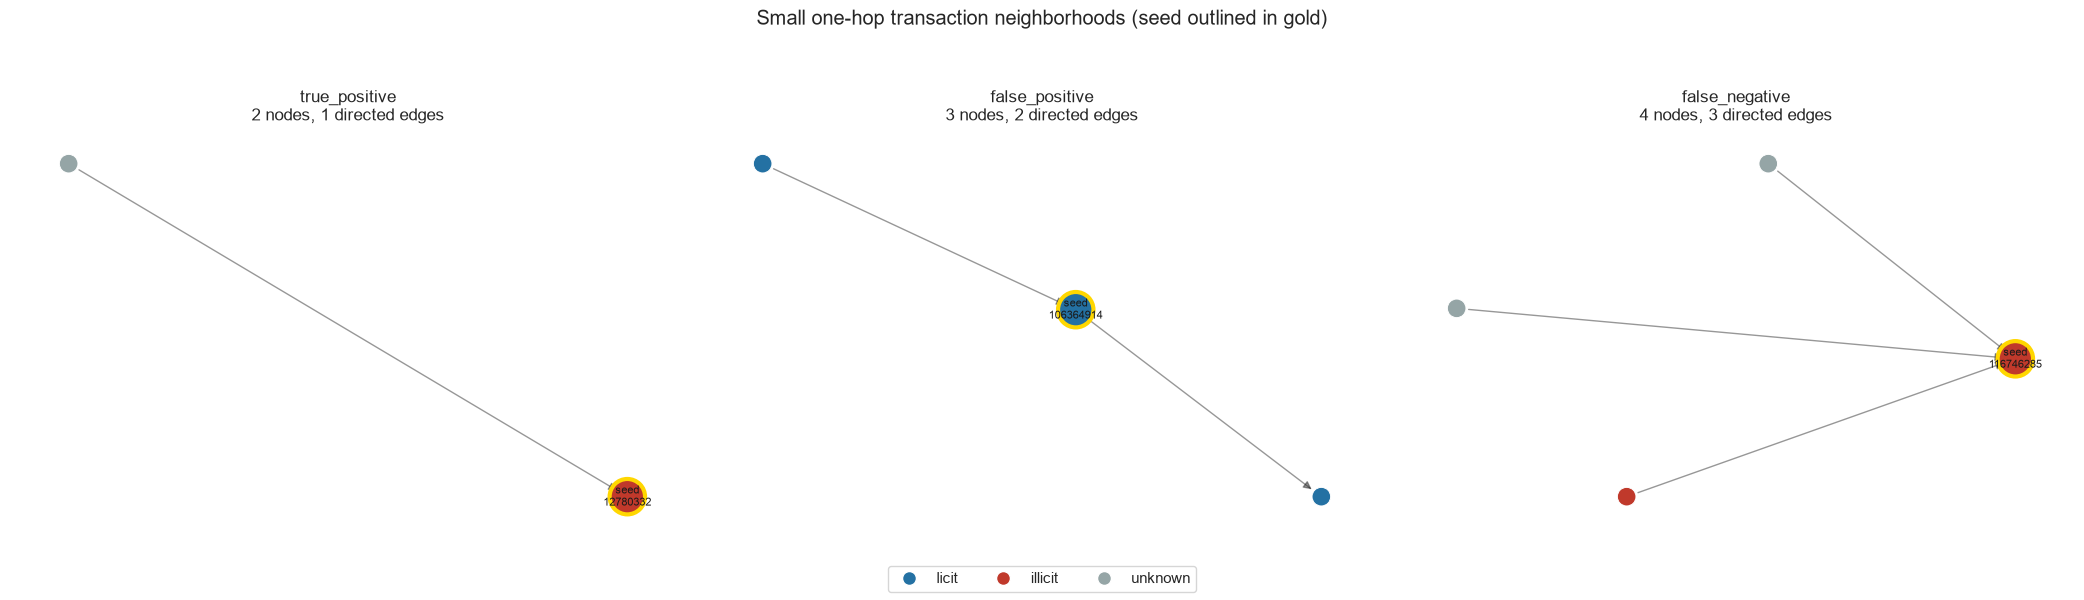

,seed_transaction_id,outcome,displayed_nodes,displayed_edges,full_one_hop_edges
0,12780332,true_positive,2,1,1
1,106364914,false_positive,3,2,2
2,116746285,false_negative,4,3,3


In [87]:
MAX_NEIGHBORHOOD_NODES = 30
TEST_SCORE_LOOKUP = (
    final_test_predictions_df
    .set_index("transaction_id")["calibrated_illicit_probability"]
)

def build_small_transaction_neighborhood(
    seed_transaction_id: int,
    max_nodes: int = MAX_NEIGHBORHOOD_NODES,
) -> tuple[nx.DiGraph, pd.DataFrame]:
    """Return a risk-prioritized, directed one-hop neighborhood."""

    direct_edges = edges_df.loc[
        edges_df["source_transaction_id"].eq(seed_transaction_id)
        | edges_df["target_transaction_id"].eq(seed_transaction_id)
    ].copy()
    endpoint_ids = pd.Index(pd.concat([
        direct_edges["source_transaction_id"],
        direct_edges["target_transaction_id"],
    ], ignore_index=True).unique())
    all_node_ids = endpoint_ids.union(pd.Index([seed_transaction_id]))
    node_table = transaction_lookup.loc[all_node_ids, ["transaction_id", "time_step", "label"]].copy()
    node_table["risk_score"] = node_table["transaction_id"].map(TEST_SCORE_LOOKUP)

    # Labeled neighbors reuse their one-time Step 8 scores. Unknown-label
    # neighbors were excluded from supervised evaluation, so score only those
    # missing nodes for graph prioritization; no unknown outcome is inferred.
    missing_score_ids = node_table.loc[
        node_table["risk_score"].isna(), "transaction_id"
    ].tolist()
    if missing_score_ids:
        missing_node_scores = score_with_frozen_alert_model(
            transaction_lookup.loc[missing_score_ids]
        )["calibrated_illicit_probability"]
        missing_score_lookup = pd.Series(
            missing_node_scores.to_numpy(),
            index=missing_score_ids,
        )
        node_table.loc[node_table["risk_score"].isna(), "risk_score"] = (
            node_table.loc[node_table["risk_score"].isna(), "transaction_id"]
            .map(missing_score_lookup)
        )

    require(node_table["risk_score"].notna().all(), "a neighborhood node could not be scored")
    retained_neighbors = (
        node_table.loc[node_table["transaction_id"].ne(seed_transaction_id)]
        .sort_values(["risk_score", "transaction_id"], ascending=[False, True])
        .head(max_nodes - 1)["transaction_id"]
        .tolist()
    )
    retained_ids = {seed_transaction_id, *retained_neighbors}
    retained_nodes = node_table.loc[node_table["transaction_id"].isin(retained_ids)].copy()
    retained_edges = direct_edges.loc[
        direct_edges["source_transaction_id"].isin(retained_ids)
        & direct_edges["target_transaction_id"].isin(retained_ids)
    ]

    graph = nx.from_pandas_edgelist(
        retained_edges,
        source="source_transaction_id",
        target="target_transaction_id",
        create_using=nx.DiGraph,
    )
    graph.add_nodes_from(retained_ids)
    return graph, retained_nodes


neighborhood_seeds_df = representative_cases_df.groupby(
    "outcome", sort=False, group_keys=False
).head(1)
representative_neighborhoods = {}
neighborhood_summary_rows = []
plot_count = max(1, len(neighborhood_seeds_df))
fig, axes = plt.subplots(1, plot_count, figsize=(7 * plot_count, 6), squeeze=False)
label_colors = {"licit": "#2471A3", "illicit": "#C0392B", "unknown": "#95A5A6"}

for axis, (_, seed_row) in zip(axes.flat, neighborhood_seeds_df.iterrows()):
    seed_id = int(seed_row["transaction_id"])
    graph, nodes = build_small_transaction_neighborhood(seed_id)
    representative_neighborhoods[seed_id] = {"graph": graph, "nodes": nodes}
    node_metadata = nodes.set_index("transaction_id")
    positions = nx.spring_layout(graph, seed=RANDOM_SEED)
    node_colors = [label_colors[str(node_metadata.loc[node, "label"])] for node in graph.nodes]
    node_sizes = [650 if node == seed_id else 180 for node in graph.nodes]
    nx.draw_networkx_nodes(
        graph, positions, node_color=node_colors, node_size=node_sizes,
        edgecolors=["gold" if node == seed_id else "white" for node in graph.nodes],
        linewidths=[3 if node == seed_id else 0.7 for node in graph.nodes], ax=axis,
    )
    nx.draw_networkx_edges(
        graph, positions, arrows=True, arrowsize=12, alpha=0.45, ax=axis,
    )
    nx.draw_networkx_labels(graph, positions, labels={seed_id: f"seed\n{seed_id}"}, font_size=8, ax=axis)
    axis.set_title(f"{seed_row['outcome']}\n{len(graph.nodes)} nodes, {len(graph.edges)} directed edges")
    axis.axis("off")
    neighborhood_summary_rows.append({
        "seed_transaction_id": seed_id, "outcome": seed_row["outcome"],
        "displayed_nodes": len(graph.nodes), "displayed_edges": len(graph.edges),
        "full_one_hop_edges": int(
            (edges_df["source_transaction_id"].eq(seed_id) | edges_df["target_transaction_id"].eq(seed_id)).sum()
        ),
    })

legend_handles = [
    Line2D([0], [0], marker="o", color="w", label=label, markerfacecolor=color, markersize=10)
    for label, color in label_colors.items()
]
fig.legend(handles=legend_handles, loc="lower center", ncol=3)
fig.suptitle("Small one-hop transaction neighborhoods (seed outlined in gold)")
plt.tight_layout(rect=(0, 0.08, 1, 0.94))
plt.show()
display(pd.DataFrame(neighborhood_summary_rows))

In [88]:
# Score unknown-label transactions after the supervised experiment is frozen.
# These are prioritization scores only because no outcome label is available.
unknown_transactions_df = transaction_df.loc[
    transaction_df["label"].astype("string").eq("unknown")
].copy()
require(
    len(unknown_transactions_df) == EXPECTED_LABEL_COUNTS["unknown"],
    "unexpected unknown-label transaction count",
)
unknown_scores = score_with_frozen_alert_model(unknown_transactions_df)
unknown_scored_df = unknown_transactions_df.loc[:, ["transaction_id", "time_step", "label"]].copy()
unknown_scored_df["calibrated_illicit_probability"] = unknown_scores["calibrated_illicit_probability"].to_numpy()
unknown_scored_df["alert"] = unknown_scores["alert"].to_numpy(dtype=bool)
unknown_scored_df["in_degree"] = unknown_scored_df["transaction_id"].map(in_degree).astype(int)
unknown_scored_df["out_degree"] = unknown_scored_df["transaction_id"].map(out_degree).astype(int)

alert_threshold = float(frozen_alert_model["alert_threshold"])
require(alert_threshold > 0.0, "risk-band construction requires a positive threshold")
RISK_BAND_ORDER = ["low", "medium", "high", "critical_alert"]
unknown_scored_df["risk_band"] = pd.cut(
    unknown_scored_df["calibrated_illicit_probability"],
    bins=[-np.inf, 0.25 * alert_threshold, 0.50 * alert_threshold, alert_threshold, np.inf],
    labels=RISK_BAND_ORDER,
    right=False,
    ordered=True,
)
unknown_scored_df["review_decision"] = np.where(
    unknown_scored_df["alert"], "escalate_for_review", "monitor_no_alert"
)

unknown_risk_summary_df = (
    unknown_scored_df.groupby("risk_band", observed=True)
    .agg(
        transactions=("transaction_id", "size"),
        mean_score=("calibrated_illicit_probability", "mean"),
        minimum_score=("calibrated_illicit_probability", "min"),
        maximum_score=("calibrated_illicit_probability", "max"),
        alerts=("alert", "sum"),
    )
    .reindex(RISK_BAND_ORDER, fill_value=0)
)
display(unknown_risk_summary_df.round(6))

,transactions,mean_score,minimum_score,maximum_score,alerts
risk_band,,,,,
low,44727,0.021097,0.018784,0.024188,0
medium,57177,0.033871,0.024962,0.048022,0
high,27546,0.067149,0.049520,0.095863,0
critical_alert,27755,0.419207,0.098699,0.996774,27755


In [89]:
# Export a compact review sample containing the highest-scoring 50 unknown
# transactions in each band. Non-alert rows serve as quality-control examples;
# the critical band remains first in operational priority order.
ANALYST_QUEUE_ROWS_PER_BAND = 50
queue_parts = []
for risk_band in reversed(RISK_BAND_ORDER):
    band_rows = (
        unknown_scored_df.loc[unknown_scored_df["risk_band"].eq(risk_band)]
        .sort_values("calibrated_illicit_probability", ascending=False)
        .head(ANALYST_QUEUE_ROWS_PER_BAND)
        .copy()
    )
    band_rows["queue_reason"] = (
        "priority_alert" if risk_band == "critical_alert"
        else "risk_band_quality_control"
    )
    queue_parts.append(band_rows)

analyst_queue_sample_df = pd.concat(queue_parts, ignore_index=True)
analyst_queue_sample_df = analyst_queue_sample_df.sort_values(
    ["alert", "calibrated_illicit_probability"],
    ascending=[False, False], kind="mergesort",
).reset_index(drop=True)
analyst_queue_sample_df.insert(0, "priority_rank", np.arange(1, len(analyst_queue_sample_df) + 1))

queue_ids = analyst_queue_sample_df["transaction_id"].tolist()
queue_feature_rows = transaction_lookup.loc[queue_ids]
queue_baseline_scores = (
    analyst_queue_sample_df
    .set_index("transaction_id")["calibrated_illicit_probability"]
)
queue_impacts_df = calculate_median_perturbation_impacts(
    queue_feature_rows, queue_baseline_scores
)
queue_impact_text = queue_impacts_df.apply(format_top_feature_impacts, axis=1)
analyst_queue_sample_df["top_feature_contributions"] = (
    analyst_queue_sample_df["transaction_id"].map(queue_impact_text)
)
analyst_queue_sample_df["risk_band"] = analyst_queue_sample_df["risk_band"].astype("string")

ANALYST_QUEUE_COLUMNS = [
    "priority_rank", "transaction_id", "time_step",
    "calibrated_illicit_probability", "risk_band", "alert",
    "review_decision", "queue_reason", "in_degree", "out_degree",
    "top_feature_contributions",
]
analyst_queue_sample_df = analyst_queue_sample_df.loc[:, ANALYST_QUEUE_COLUMNS]
STEP9_OUTPUT_DIR = PROJECT_ROOT / "outputs"
STEP9_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ANALYST_QUEUE_PATH = STEP9_OUTPUT_DIR / "analyst_queue_sample.csv"
analyst_queue_sample_df.to_csv(ANALYST_QUEUE_PATH, index=False)

display(analyst_queue_sample_df.head(20))
print(f"Exported {len(analyst_queue_sample_df):,} analyst-review rows to:")
print(ANALYST_QUEUE_PATH)

,priority_rank,transaction_id,time_step,calibrated_illicit_probability,risk_band,alert,review_decision,queue_reason,in_degree,out_degree,top_feature_contributions
0,1,378058512,16,0.996774,critical_alert,True,escalate_for_review,priority_alert,0,1,local_feature_053:+0.052683 | local_feature_05...
1,2,378250960,16,0.996774,critical_alert,True,escalate_for_review,priority_alert,1,0,local_feature_053:+0.081924 | local_feature_05...
2,3,378059038,16,0.996774,critical_alert,True,escalate_for_review,priority_alert,0,1,local_feature_053:+0.059906 | local_feature_05...
3,4,105028135,8,0.996774,critical_alert,True,escalate_for_review,priority_alert,1,0,local_feature_053:+0.047784 | local_feature_05...
4,5,378060067,16,0.996774,critical_alert,True,escalate_for_review,priority_alert,0,1,local_feature_053:+0.047784 | local_feature_05...
5,6,99914597,21,0.996774,critical_alert,True,escalate_for_review,priority_alert,1,0,local_feature_053:+0.087093 | local_feature_05...
6,7,85087377,11,0.996774,critical_alert,True,escalate_for_review,priority_alert,1,0,local_feature_053:+0.054412 | local_feature_05...
7,8,234565902,11,0.996774,critical_alert,True,escalate_for_review,priority_alert,1,1,local_feature_055:+0.047784 | local_feature_05...
8,9,99632900,21,0.996774,critical_alert,True,escalate_for_review,priority_alert,1,0,local_feature_053:+0.070159 | local_feature_05...
9,10,234565907,11,0.996774,critical_alert,True,escalate_for_review,priority_alert,1,1,local_feature_053:+0.047784 | local_feature_05...


Exported 200 analyst-review rows to:
E:\Machine Leraning\ML Project\AML Crypto Complience\outputs\analyst_queue_sample.csv


In [90]:
# Verify that explanation and queue generation did not mutate the policy.
require(
    {key: frozen_alert_model[key] for key in frozen_policy_before_explanations}
    == frozen_policy_before_explanations,
    "the frozen alert policy changed during Step 9",
)
require(FINAL_TEST_EVALUATION_COMPLETED, "Step 8 final evaluation is not complete")
require(len(unknown_scored_df) == EXPECTED_LABEL_COUNTS["unknown"], "unknown scoring is incomplete")
require(ANALYST_QUEUE_PATH.exists(), "analyst queue export was not created")
require(analyst_queue_sample_df["transaction_id"].is_unique, "analyst queue IDs are duplicated")
require(analyst_queue_sample_df["top_feature_contributions"].notna().all(), "queue explanations are missing")

print("Step 9 complete: explanations, neighborhoods, unknown scores, and analyst queue are available.")
print("Anonymized feature names limit semantic interpretation; scores prioritize review and are not evidence of wrongdoing.")

Step 9 complete: explanations, neighborhoods, unknown scores, and analyst queue are available.
Anonymized feature names limit semantic interpretation; scores prioritize review and are not evidence of wrongdoing.


### Analyst interpretation limits

- Feature names are anonymized, so an importance value shows model sensitivity rather than a business-readable reason such as transaction amount or counterparty type.
- Correlated features can share or mask permutation importance. A negative importance does not prove that a feature is protective.
- Median-perturbation impacts are local sensitivity checks. They are not causal effects, and they do not necessarily sum to the full score.
- Neighborhood plots show at most 30 nodes and prioritize the highest saved risk scores, so high-degree transaction context is intentionally truncated.
- Unknown-label transactions have no verified outcome. An alert means review first; it must never be treated as an accusation or automatic enforcement decision.

## 10. Compliance framing and final documentation

This notebook is a research prototype for prioritizing Bitcoin transactions for human review. It is **not legal advice**, a production transaction-monitoring system, a sanctions-screening engine, or an automated reporting mechanism. Its output is an internal risk signal only. A model alert does not establish money laundering, terrorist financing, sanctions exposure, criminal conduct, or a duty to submit a report.

Regulatory snapshot and links were checked on **9 September 2026**. An implementing organization must obtain advice for its own status, services, jurisdictions, customers, data-processing context, and current law.

### Human review and escalation workflow

| Stage | Owner | Required work | Permitted outcome | Prohibited shortcut |
|---|---|---|---|---|
| 1. Model triage | Monitoring system | Add the calibrated score, threshold decision, risk band, graph context, and explanation to the queue; preserve model/version/time metadata. | Prioritize a case for review. | Treat the score, `illicit` training label, or risk band as proof. |
| 2. First-level review | Trained LCB-FT analyst | Verify data quality; review the customer profile, beneficial owner, expected activity, transaction history, source/destination, counterparties, blockchain context, and available originator/beneficiary information. Record supporting and exculpatory facts. | Close with a documented rationale, request information under approved procedures, or escalate. | Change the model threshold to obtain a preferred case outcome; rely on anonymized features alone. |
| 3. Enhanced analysis | Senior analyst / LCB-FT function | Perform the institution's risk-based *examen renforcé* where applicable; assess unusualness, economic purpose, KYC consistency, typologies, linked cases, and new information. | Close, continue monitoring, apply an authorized control, or refer to the designated reporting decision-maker. | Equate unusual activity with legal suspicion automatically. |
| 4. Suspicion-report decision | Authorized *déclarant/correspondant TRACFIN* or other designated role | Apply the current Code monétaire et financier, internal procedures, and documented human judgment. Preserve confidentiality and the reasoning both for filing and not filing. | Submit a *déclaration de soupçon* through ERMES when the legal conditions are met, and provide relevant updates as required. | Let the model submit, suppress, or draft a final filing without accountable human approval. |
| 5. Sanctions / asset-freeze track | Sanctions specialist and authorized operations/legal function | Screen identity and ownership/control against applicable, current official lists; resolve aliases and false matches; determine the governing measure and required action. | Apply a legally required freeze or other restriction and notify the competent channel when applicable. | Infer a sanctions match from blockchain risk score or graph proximity. |
| 6. Quality assurance | Independent compliance QA / model risk | Sample alerts and non-alerts, review consistency, monitor drift and capacity, investigate overrides, and maintain audit trails. | Approve remediation or open a separately governed model-change proposal. | Feed test outcomes or analyst labels directly into the frozen experiment without a new validation design. |

Escalation service levels, authority limits, evidence requirements, and record-retention periods must be defined by the deploying organization's risk assessment and applicable rules; this research notebook does not invent them.

### Decision boundaries and French/EU terminology

| Artifact or decision | Meaning in this project | What it is not | Human authority required |
|---|---|---|---|
| `calibrated_illicit_probability` | A model score calibrated against historical Elliptic labels. | A probability that a person committed an offence. | Analyst interprets it with other information. |
| `alert=True` | The frozen score met the Step 7 review threshold. | A *soupçon* in the legal sense, a customer restriction, or a report. | LCB-FT analyst owns triage. |
| *Alerte LCB-FT* | Internal signal for *lutte contre le blanchiment de capitaux et le financement du terrorisme*. | A legal finding of BC/FT. | Trained reviewer. |
| *Examen renforcé* | Contextual analysis under the organization's applicable obligations and procedures. | Automatic escalation based only on a score. | Senior compliance function. |
| *Déclaration de soupçon* | Confidential report by an obliged professional when the applicable legal conditions are met. | A direct model output or a fixed-score consequence. | Authorized *déclarant/correspondant*; ERMES workflow. |
| Sanctions match / *gel des avoirs* | Separate determination based on current official designations, identity, ownership/control, and the applicable restrictive measure. | A high AML risk score, graph connection, or TRACFIN filing decision. | Sanctions/legal/operations function under the applicable measure. |
| PSCA / CASP | *Prestataire de services sur crypto-actifs* / crypto-asset service provider under MiCA terminology. | The former French PSAN label as a universal current term. | Status and competent-authority analysis must be organization-specific. |

The production case record should retain the transaction and customer identifiers, timestamp, model and data versions, frozen score and threshold, risk band, explanation limitations, analyst evidence, disposition, reviewer identity, approvals, sanctions-screening result, reporting decision, and any later information that changes the assessment. Access must be role-based and reporting confidentiality protected.

### EU and French regulatory snapshot — checked 9 September 2026

- France's current Code monétaire et financier lists relevant crypto-asset service providers among entities subject to LCB-FT obligations. MiCA terminology is PSCA/CASP; the French PSAN transition ended on 1 July 2026. See [CMF article L. 561-2](https://www.legifrance.gouv.fr/codes/article_lc/LEGIARTI000050361172/2026-05-18), the [current crypto-asset-services chapter](https://www.legifrance.gouv.fr/codes/id/LEGIARTI000050358361), and the [ACPR PSCA status page](https://acpr.banque-france.fr/fr/professionnels/lacpr-vous-accompagne/parcours-fintech/contenus-pedagogiques/de-quel-statut-releve-mon-activite/je-propose-des-services-sur-crypto-actifs).
- CMF article L. 561-15 addresses reporting by obliged persons when they know, suspect, or have good reason to suspect the specified criminal origin or terrorist-financing link; attempts are also covered, and enhanced examination may lead to reporting where appropriate. Articles L. 561-16 and L. 561-18 address execution timing and confidentiality. Consult the [current Légifrance section L. 561-15 to L. 561-22](https://www.legifrance.gouv.fr/codes/id/LEGISCTA000033517859).
- TRACFIN states that there is no monetary reporting threshold, that the report must include customer/beneficial-owner information and analysis supporting the suspicion, and that ERMES is the priority secure reporting channel. See [When and how to report a suspicion](https://www.economie.gouv.fr/tracfin/vous-etes-professionnel-declarant/quand-et-comment-declarer-un-soupcon) and [ERMES](https://www.economie.gouv.fr/tracfin/ermes-la-plateforme-de-declaration-en-ligne-de-tracfin).
- Regulation (EU) 2023/1113 extends traceability/information requirements to covered crypto-asset transfers and has applied since 30 December 2024. See the [official EUR-Lex text](https://eur-lex.europa.eu/eli/reg/2023/1113/oj). The model does not contain Travel Rule originator/beneficiary data and cannot test compliance with those requirements.
- The EBA's crypto-asset amendments to the ML/TF Risk Factors Guidelines apply from 30 December 2024 and describe blockchain analytics as one component of a broader risk-based framework. See the [EBA crypto-asset guidance](https://www.eba.europa.eu/publications-and-media/press-releases/eba-issues-guidance-crypto-asset-service-providers) and [guidelines page](https://www.eba.europa.eu/legacy/regulation-and-policy/regulatory-activities/anti-money-laundering-and-countering-financing-1).
- Regulation (EU) 2024/1624 (AMLR) is published but generally applies from 10 July 2027, so it is a future application milestone at this notebook's legal snapshot date. See the [official AMLR text and Article 90](https://eur-lex.europa.eu/eli/reg/2024/1624).
- Asset freezing is a distinct legal track. The Direction générale du Trésor states that designated-person freezes and prohibitions on making funds/resources available must be applied without delay by persons within scope; screening must use the current official register and applicable measures. See the [national asset-freeze framework](https://www.tresor.economie.gouv.fr/services-aux-entreprises/sanctions-economiques/dispositif-national-de-gel-des-avoirs) and [national register](https://gels-avoirs.dgtresor.gouv.fr/).
- If deployment involves personal data or decisions producing legal or similarly significant effects, assess GDPR requirements, including Article 22 and meaningful human involvement. See the [CNIL text of GDPR Article 22](https://www.cnil.fr/fr/reglement-europeen-protection-donnees/chapitre3). This notebook deliberately permits review prioritization only and does not authorize a solely automated adverse decision.

### Limitations, ethical risks, and required controls

- **Historical and external validity:** Elliptic represents an older, bounded Bitcoin graph. Present-day services, typologies, mixers, bridges, layer-two systems, stablecoins, cross-chain activity, and adversarial behavior may differ materially.
- **Incomplete labels:** `unknown` does not mean licit. Observed illicit/licit labels are selective and can create verification, survivorship, and sampling bias. Reported metrics are conditional on known labels.
- **Anonymized features:** Feature semantics are unavailable. Importance and perturbation values show statistical model sensitivity, not an intelligible allegation or causal mechanism.
- **Missing compliance context:** The data lack verified customer identity, beneficial ownership, source of funds/wealth, economic purpose, geography, Travel Rule information, sanctions identity matches, and off-chain activity.
- **Temporal drift:** Performance changes across steps and around step 43 show that a static threshold can deteriorate. Production monitoring needs drift triggers, capacity monitoring, calibration checks, and controlled rollback.
- **False-positive harm:** Unnecessary friction, delayed transfers, account restrictions, stigma, and disproportionate investigation can result from automation bias. Analysts must seek exculpatory evidence and record overrides.
- **False-negative harm:** Missed activity remains possible even at high measured precision. Non-alert samples require quality assurance, and this model cannot replace other scenarios, KYC, sanctions, fraud, or intelligence controls.
- **Privacy and security:** Blockchain data can become personal data when linkable to people. Define lawful basis, purpose limitation, minimization, access controls, retention/deletion, security, incident response, data-subject handling, and DPIA needs before deployment.
- **Human oversight:** Human review must be substantive, trained, resourced, and empowered to disagree. A nominal click-through does not cure an automated-decision risk.
- **Feedback and governance:** Analyst decisions are not automatically ground truth. Label feedback needs quality checks, provenance, conflict resolution, and a newly frozen temporal evaluation before any model update.
- **Research scope:** This project does not assess legal privilege, cross-border reporting, data localization, outsourcing/cloud controls, record-retention periods, consumer notice, or the deploying entity's precise regulator and authorization status.

### Reproduce the study from a clean environment

1. Clone or copy the project and open a terminal at the project root. Use the Python version recorded in the generated manifest (this verified run uses Python 3.13.5).
2. Create the environment: `python -m venv .venv`. On Windows activate with `.venv\Scripts\activate`; on macOS/Linux use `source .venv/bin/activate`.
3. Install exact recorded packages with `python -m pip install -r requirements-lock.txt`. Use `requirements.txt` only when intentionally resolving a new environment, because its entries are version ranges.
4. Follow `docs/dataset.md`. Place the three canonical CSV files under `data/raw/elliptic_bitcoin_dataset/` with their existing filenames. Do not commit data or Kaggle credentials.
5. Register the kernel if needed: `python -m ipykernel install --user --name aml-crypto-compliance --display-name "Python (AML Crypto Compliance)"`.
6. Start `jupyter lab`, open `notebooks/main.ipynb`, choose the project kernel, then use **Kernel → Restart Kernel and Run All Cells**. If Step 8 is rerun in the same kernel, it reuses the saved one-time final-test predictions and verifies that the frozen policy has not changed.
7. Confirm the dataset validation messages, chronological partition assertions, frozen Step 7 policy, Step 8 completion, Step 9 audit, and final Step 10 checklist. A full run can take several minutes because tree searches, bootstrap intervals, and model-agnostic explanations are recomputed.
8. Inspect `outputs/` for the evaluation tables, global importance, analyst queue, compliance handoff, and `reproducibility_manifest.json`. Compare input SHA-256 hashes and package versions before comparing results across machines.

Randomness is controlled by `RANDOM_SEED`; chronological splits and expected counts are asserted. `TREE_N_JOBS` affects resource usage. Reducing it can make the machine more responsive but should not be treated as a model change.

In [91]:
import hashlib
import json
import platform
import sys

import matplotlib
import networkx
import sklearn
import seaborn

LEGAL_SNAPSHOT_DATE = "2026-09-09"
STEP10_OUTPUT_DIR = PROJECT_ROOT / "outputs"
STEP10_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    """Hash a file in bounded chunks for reproducibility auditing."""
    digest = hashlib.sha256()
    with path.open("rb") as file_handle:
        for chunk in iter(lambda: file_handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()

def json_scalar(value):
    """Convert NumPy scalars and non-finite numbers to JSON-safe values."""
    if isinstance(value, np.generic):
        value = value.item()
    if isinstance(value, float) and not np.isfinite(value):
        return None
    return value

# Export the final, already-frozen result tables. No model fitting or threshold
# selection occurs here. These files form the reproducible handoff package.
step10_table_exports = {
    "final_test_summary.csv": final_test_summary_df,
    "final_test_confidence_intervals.csv": final_test_confidence_intervals_df,
    "final_test_by_time_step.csv": final_test_by_time_step_df,
    "step43_period_results.csv": step43_period_results_df,
    "global_feature_importance.csv": global_feature_importance_df,
    "calibration_quality.csv": calibration_quality_df,
    "candidate_operating_points.csv": candidate_operating_points_df,
}
for file_name, table in step10_table_exports.items():
    table.to_csv(STEP10_OUTPUT_DIR / file_name, index=False)

compliance_handoff_summary_df = pd.DataFrame([{
    "model_output": "review_priority_signal_only",
    "human_review_required": True,
    "automated_legal_conclusion_permitted": False,
    "automated_tracfin_filing_permitted": False,
    "automated_sanctions_freeze_permitted": False,
    "legal_snapshot_date": LEGAL_SNAPSHOT_DATE,
    **frozen_policy_before_test,
    "test_precision": final_test_metrics["precision"],
    "test_recall": final_test_metrics["recall"],
    "test_f0_5": final_test_metrics["f0_5"],
    "test_pr_auc": final_test_metrics["pr_auc"],
    "test_roc_auc": final_test_metrics["roc_auc"],
    "test_alert_rate": final_test_metrics["alert_rate"],
    "test_review_efficiency_lift": final_test_metrics["review_efficiency_lift"],
}])
COMPLIANCE_HANDOFF_PATH = STEP10_OUTPUT_DIR / "compliance_handoff_summary.csv"
compliance_handoff_summary_df.to_csv(COMPLIANCE_HANDOFF_PATH, index=False)

input_paths = {
    "features": FEATURES_PATH,
    "classes": CLASSES_PATH,
    "edges": EDGES_PATH,
}
artifact_paths = {
    **{name: STEP10_OUTPUT_DIR / name for name in step10_table_exports},
    "analyst_queue_sample.csv": ANALYST_QUEUE_PATH,
    "compliance_handoff_summary.csv": COMPLIANCE_HANDOFF_PATH,
}
reproducibility_manifest = {
    "project": "AML Crypto Compliance — Elliptic Bitcoin study",
    "legal_snapshot_date": LEGAL_SNAPSHOT_DATE,
    "python": sys.version,
    "platform": platform.platform(),
    "packages": {
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit-learn": sklearn.__version__,
        "matplotlib": matplotlib.__version__,
        "seaborn": seaborn.__version__,
        "networkx": networkx.__version__,
    },
    "random_seed": int(RANDOM_SEED),
    "tree_n_jobs": int(TREE_N_JOBS),
    "partitions": {
        name: sorted(int(step) for step in steps)
        for name, steps in EXPECTED_PARTITION_TIME_STEPS.items()
    },
    "input_sha256": {name: sha256_file(path) for name, path in input_paths.items()},
    "requirements_lock_sha256": sha256_file(PROJECT_ROOT / "requirements-lock.txt"),
    "frozen_policy": {
        key: json_scalar(value) for key, value in frozen_policy_before_test.items()
    },
    "final_test_metrics": {
        key: json_scalar(value) for key, value in final_test_metrics.items()
    },
    "artifact_sha256": {name: sha256_file(path) for name, path in artifact_paths.items()},
}
REPRODUCIBILITY_MANIFEST_PATH = STEP10_OUTPUT_DIR / "reproducibility_manifest.json"
with REPRODUCIBILITY_MANIFEST_PATH.open("w", encoding="utf-8") as manifest_file:
    json.dump(reproducibility_manifest, manifest_file, indent=2, sort_keys=True, ensure_ascii=False)

display(compliance_handoff_summary_df.round(5))
display(pd.DataFrame(
    reproducibility_manifest["packages"].items(),
    columns=["package", "version"],
))
print(f"Wrote compliance handoff: {COMPLIANCE_HANDOFF_PATH}")
print(f"Wrote reproducibility manifest: {REPRODUCIBILITY_MANIFEST_PATH}")

,model_output,human_review_required,automated_legal_conclusion_permitted,automated_tracfin_filing_permitted,automated_sanctions_freeze_permitted,legal_snapshot_date,model_family,feature_set,configuration,calibration_method,alert_threshold,test_precision,test_recall,test_f0_5,test_pr_auc,test_roc_auc,test_alert_rate,test_review_efficiency_lift
0,review_priority_signal_only,True,False,False,False,2026-09-09,random_forest,all_166,rf_deep_leaf_1,sigmoid,0.0987,0.56586,0.73777,0.59352,0.77941,0.90272,0.0847,8.71002


,package,version
0,numpy,2.5.2
1,pandas,3.0.5
2,scikit-learn,1.9.0
3,matplotlib,3.11.1
4,seaborn,0.13.2
5,networkx,3.6.1


Wrote compliance handoff: E:\Machine Leraning\ML Project\AML Crypto Complience\outputs\compliance_handoff_summary.csv
Wrote reproducibility manifest: E:\Machine Leraning\ML Project\AML Crypto Complience\outputs\reproducibility_manifest.json


### Possible future improvements — each requires a new experiment

1. Obtain newer, legally usable, provenance-controlled labels and preserve an untouched later-period test set. Treat delayed enforcement labels and analyst dispositions separately.
2. Add governed entity/address clustering, temporal graph features, transaction-flow motifs, and graph models; compare them against the frozen tabular baseline with ablations.
3. Incorporate customer/KYC, beneficial-owner, geography, product/channel, economic-purpose, and Travel Rule fields only after data-protection, quality, access, and legal-basis review.
4. Evaluate positive-unlabeled or semi-supervised methods because unknown transactions are not reliable negatives.
5. Add calibration-drift, population-stability, alert-volume, analyst-capacity, override, subgroup, and delayed-outcome monitoring with pre-agreed warning and retirement triggers.
6. Evaluate costs and operational constraints with compliance owners. Thresholds should reflect risk appetite and review capacity without converting a score into a legal conclusion.
7. Develop graph-aware explanations and business-readable feature definitions; validate explanation fidelity with analysts and guard against automation bias.
8. Integrate official sanctions and adverse-information sources only through separately validated matching, ownership/control, freshness, licensing, and escalation controls.
9. Add secure model/data registries, signed artifacts, access logs, change approval, rollback, incident response, and independent validation before production use.
10. Test robustness to adversarial evasion, entity fragmentation, missing edges, label delay, regime change, and cross-chain displacement.

In [92]:
# Final reproducibility and compliance-boundary gate.
required_step10_artifacts = [
    *artifact_paths.values(),
    REPRODUCIBILITY_MANIFEST_PATH,
]
final_project_checklist = {
    "canonical_dataset_validated": (
        len(transaction_df) == EXPECTED_TRANSACTION_COUNT
        and len(edges_df) == EXPECTED_EDGE_COUNT
    ),
    "chronological_partitions_validated": (
        set(partition_frames) == set(PARTITION_ORDER)
    ),
    "frozen_test_evaluated_once": bool(FINAL_TEST_EVALUATION_COMPLETED),
    "policy_unchanged_after_explanations": (
        {key: frozen_alert_model[key] for key in frozen_policy_before_explanations}
        == frozen_policy_before_explanations
    ),
    "all_unknown_transactions_scored": (
        len(unknown_scored_df) == EXPECTED_LABEL_COUNTS["unknown"]
    ),
    "analyst_queue_has_explanations": (
        analyst_queue_sample_df["top_feature_contributions"].notna().all()
    ),
    "documentation_artifacts_exist": all(path.exists() for path in required_step10_artifacts),
    "alerts_are_review_only": (
        compliance_handoff_summary_df.loc[0, "model_output"]
        == "review_priority_signal_only"
    ),
    "automated_legal_actions_disabled": (
        not compliance_handoff_summary_df.loc[0, "automated_legal_conclusion_permitted"]
        and not compliance_handoff_summary_df.loc[0, "automated_tracfin_filing_permitted"]
        and not compliance_handoff_summary_df.loc[0, "automated_sanctions_freeze_permitted"]
    ),
}
final_project_checklist_df = pd.Series(
    final_project_checklist, name="passed"
).to_frame()
display(final_project_checklist_df)
require(all(final_project_checklist.values()), "one or more final project checks failed")

print("Step 10 complete: the study is reproducible and its compliance boundaries are documented.")
print("Final reminder: model alerts prioritize accountable human review; they are not legal conclusions.")

,passed
canonical_dataset_validated,True
chronological_partitions_validated,True
frozen_test_evaluated_once,True
policy_unchanged_after_explanations,True
all_unknown_transactions_scored,True
analyst_queue_has_explanations,True
documentation_artifacts_exist,True
alerts_are_review_only,True
automated_legal_actions_disabled,True


Step 10 complete: the study is reproducible and its compliance boundaries are documented.
Final reminder: model alerts prioritize accountable human review; they are not legal conclusions.
